# Model Development

## Prehospital Prediction of Major Trauma (ISS ≥20) Using Machine Learning
## A Single-Center Study from the Luzerner Kantonspittal

**Author:** Gina Marie Gerlach

**Institution:** University of Luzern, MSc Health Sciences in Healthcare Data Science

**Date Finalized:** 15 April 2026  

**Data extraction date:** January 2026

**Analytic study period:** 1 January 2016 – 6 November 2025

### Research Question
Can routinely collected prehospital variables predict major trauma (ISS ≥20) to support Highly Specialized Medicine (HSM) trauma center dispatch decisions?

### Primary Outcome
ISS ≥20 (binary) — Swiss HSM trauma center designation threshold

**Secondary Objectives:** 
- validate the EMS model on secondary outcomes 
- compare EMS on-scene vs dispatch only model performance
- report preventable overtriage


### Notebook Structure
This notebook reproduces all analyses reported in the thesis in sequential order:

**Preprocessing (sections 1–13):**

**Modeling (sections 14–18):**

**Visualizations (section 19):**

1. Setup
2. Data loading & initial cleaning
3. Apply inclusion/exclusion criteria
4. Drop columns flagged during EDA
5. Data type conversions
6. Outlier handling & MNAR checks
7. Feature engineering
8. Variable classification
9.  Train/test split
10. Mini-EDA on training data
11. Encoding
12. Imputation (MICE primary, KNN sensitivity)
13. Scaling
14. Primary modeling (LR, RF, XGBoost)
15. STB rule-based comparator
16. Sensitivity analyses
17. Subgroup & descriptive analyses
18. Diagnostic outcome comparisons
19. Visualizations

## 1. Setup

Dependencies, reproducibility settings, and display configuration.

In [1]:
# ── Dependencies ──────────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import mannwhitneyu
from pmsampsize.pmsampsize import pmsampsize

# Modelling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.calibration import CalibrationDisplay
from scipy.stats import loguniform, randint

# Evaluation
from sklearn.metrics import (roc_auc_score, roc_curve, brier_score_loss,
                             confusion_matrix, classification_report)
from sklearn.calibration import calibration_curve

# Explainability
import shap
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Utilities
import pickle
import datetime
import subprocess
from docx import Document
from docx.shared import Pt, Inches, Cm, RGBColor, Emu
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml.ns import qn, nsdecls
from docx.oxml import parse_xml
from collections import Counter

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Display settings ──────────────────────────────────────────────────────────
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('future.no_silent_downcasting', True)

## 2. Data Loading & Initial Cleaning

Raw data loaded from the Luzerner Kantonsspital (LUKS) trauma patient records, 2016–2025. his dataset includes patients that meet both the Swiss Trauma Registry (STR) and the German Thrauma Registry (TR-DGU) inclusion criteria. Only the STR data dictionary was available from the hospital, the TR-DGU data dictionary was not included. 

For more details about the decision making done to inform the initial cleaning, please see Appendix X. Exploratory Data Analysis.


Raw data from LUKS was stored in long format (14,171 rows) due to surgical procedure data being recorded as multiple rows per patient. This section resolves this to one row per patient (n=2,361). 

A helper function tracks shape and missingness changes at each step.

In [2]:
def sum_check(dfa, dfb, label=""):
    print(f"{'Step: ' + label if label else ''}")
    print(f"  Rows:    {dfa.shape[0]:,} → {dfb.shape[0]:,}  "
          f"({'−' if dfb.shape[0] < dfa.shape[0] else '+'}"
          f"{abs(dfb.shape[0] - dfa.shape[0]):,})")
    print(f"  Columns: {dfa.shape[1]:,} → {dfb.shape[1]:,}  "
          f"({'−' if dfb.shape[1] < dfa.shape[1] else '+'}"
          f"{abs(dfb.shape[1] - dfa.shape[1]):,})")
    print(f"  Missing: {dfa.isnull().mean().mean():.2%} → "
          f"{dfb.isnull().mean().mean():.2%}")
    print("-" * 50)

In [ ]:
### Step 2 - Data Loading and Initial Cleaning ###

# ── 2.1 Load Raw Data ─────────────────────────────────────────────────────────── 
DATA_PATH = "../data/raw/LUKS_raw_data.xlsx"
raw_data = pd.read_excel(DATA_PATH)
raw_data.info()

# ── 2.2 Standardize Null Values ─────────────────────────────────────────────────────────── 
# Strip whitespace, then replace empty strings and null-like values with NaN for consistency in missing value handling.

NULL_STRINGS = [
    '', ' ',
    'NA', 'N/A', 'n/a', 'na',
    'NULL', 'null', 'Null',
    'NaN', 'nan',
    'None', 'none',
    'missing', 'Missing', 'MISSING',
    'unknown', 'Unknown', 'UNKNOWN',
    '-', '--', '---', '?',
]

df = raw_data.copy()

df = df.replace(NULL_STRINGS, np.nan)

sum_check(raw_data, df, "2.2 Standardize Null Values")

# ── 2.3 Drop Columns with 100% Missing Values ───────────────────────────────────────────────────────────
# Columns with no values across all rows are dropped as they carry no information. 
# These columns were all wide-format repeated variables numbered _7 through _10. 
# They were likely generated automatically by the trauma registry collection form used to input the patient data. 

df_prev = df.copy()

cols_100_missing = df.columns[df.isna().all()].tolist()

df = df.drop(columns=cols_100_missing)
sum_check(df_prev, df, "2.3 Drop 100% Missing")

# ── 2.4 Drop Zero-Variance Columns ─────────────────────────────────────────────────────────── 
# Only true zero variance columns were removed. True zero variance are columns with zero variance and zero missing values. 
# Other columns may contain clinical data and will be explored to determine importance.

# Klinik-Nr and related clinic identifiers are dropped as this is a single-center study. 
# These variables would need to be retained in a multi-center analysis.

df_prev = df.copy()

zero_var_cols = [
    'Klinik-Nr.',
    'KL_2426 - Export to AdjumedAnalyze',
    'KL_3762 - Manuell abgeschlossen',
    'KlinikNummer - Klinik-Nr.'
]

df = df.drop(columns=zero_var_cols)
sum_check(df_prev, df, "2.4 Drop Zero-Variance Columns")

# ── 2.5 Translate and Mark STR Columns ─────────────────────────────────────────────────────────── 
# Columns were translated from German to English using DeepL translator.
# Columns were marked for retention based on the STR data dictionary provided by the STR (memo1901Anleitung_Datenerfassung_STR_2018_de.pdf). 
# Only variables present in the STR data dictionary were retained to maintain accurate understanding of the data.

# Naming conventions follow the STR data dictionary sections: 
# demo_ = Demographics (Patient und Unfall) 
# ph_   = Prehospital (Präklinik)
# hosp_ = Hospital (Spital: Eintreffen Spital, Erster Glasgow Coma Scale, Erste Vitalwerte, Erste Laborwerte, Erste Temperatur, Weitere Behandlungsparameter)
# ed_   = Emergency Deparment (Spital: Therapie im Schockraum / Notfallstation, Bildgebung Schockraum / Notfallstation, Verlassen Schockraum / Notfallstation)
# icu_  = Intensive Care Unit (Spital: IPS) 
# dx_   = Discharge and long-term outcomes (Entlassung and Langzeitverlauf)
# et_ = Individual diagnostic codes (Einzeldiagnosen)


df_prev = df.copy()

MAPPING_PATH = "../data/processed/translation_mapping.xlsx"
translation_meta = pd.read_excel(MAPPING_PATH)

translate_dict = dict(zip(
    translation_meta['orig_name'],
    translation_meta['new_name']
))

df = df.rename(columns=translate_dict)
df = df[[col for col in df.columns
         if col in translation_meta['new_name'].values]]

# Retain only STR data dictionary variables
str_cols = translation_meta.query('data_dict == "STR"')['new_name'].tolist()
df = df[str_cols]

sum_check(df_prev, df, "2.5 Translate and Mark STR Columns")

# ── 2.6 Create Composite Key ─────────────────────────────────────────────────────────── 
# A composite identification key (unique_id) was created from patient number and accident number (demo_pid_nr + demo_accident_nr).
# This ensured that each patient-accident combination was uniquely identified and not condensed into a single row incorrectly.

# While creating the composite key several data quality issues were identified:
# One demo_accident_nr shared across two patients with different demo_pid_nr (retained as separate records, likely clerical error)
# One demo_pid_nr shared across two different patients with different dates of births (retained as separate records, likely clerical error)

# There were only eight patients with multiple accidents (all confirmed as separate admissions across different dates, all retained
# demo_pid_nr and demo_accident_nr dropped after unique_id was confirmed.

df_prev = df.copy()

df['unique_id'] = (df['demo_pid_nr'].astype(str) + '_' +
                   df['demo_accident_nr'].astype(str))

df = df.drop(columns=['demo_pid_nr', 'demo_accident_nr'])

sum_check(df_prev, df, "2.6 Create Composite Key")

# ── 2.7 Resolve duplicate rows ─────────────────────────────────────────────────────────── 
# Duplicate rows were identified based on the unique_id composite key.
# It was determined that the duplicates were due to long-format rows where each row represented a single procedure for a patient, rather than a single row per patient.
# Long-format columns were all related to individual diagnoses. There were too many rows per patient to pivot all columns wide.
# The columns were explored and either dropped or aggregated based on clinical relevance and data quality.


# Number of surgical sessions per patient
op_cols = [
    'et_operation_start_date', 'et_operation_code_CHOP',
    'et_operation_start_time', 'et_operation_end_date', 'et_operation_end_time'
]

ops_per_patient = (
    df[df['et_operation_start_date'].notna()]
    .assign(session_key=lambda x: x['et_operation_start_date'].astype(str) + '_' + x['et_operation_start_time'].astype(str))
    .groupby('unique_id')['session_key']
    .nunique()
)

df['et_surgical_sessions_nr'] = df['unique_id'].map(ops_per_patient).fillna(0).astype(int)

# Number of AIS codes per patient

ais_cols = [
    'et_AIS', 'et_complication_noAIS', 'et_icd_code_per_AIS', 'et_diagnosis_nr'
]

has_ais = df[ais_cols].notna().any(axis=1)
ais_per_patient = has_ais.groupby(df['unique_id']).sum()

df['et_ais_codes_nr'] = df['unique_id'].map(ais_per_patient).fillna(0).astype(int)

# Categorized CHOP codes
def categorize_chop(code):
    if pd.isna(code):
        return np.nan
    
    code_str = str(code)
    
    if code_str.startswith('7A.'):
        return 'spinal_surgery'
    
    try:
        prefix = int(code_str.split('.')[0])
    except ValueError:
        return 'other'
    
    if prefix == 0:                  return 'misc_interventions'
    elif 1 <= prefix <= 5:           return 'neurosurgery'
    elif 6 <= prefix <= 7:           return 'endocrine'
    elif 8 <= prefix <= 16:          return 'ophthalmology'
    elif 18 <= prefix <= 29:         return 'ENT'
    elif 30 <= prefix <= 34:         return 'thoracic_respiratory'
    elif 35 <= prefix <= 39:         return 'cardiovascular'
    elif 40 <= prefix <= 41:         return 'haematopoietic'
    elif 42 <= prefix <= 54:         return 'abdominal'
    elif 55 <= prefix <= 59:         return 'urological'
    elif 60 <= prefix <= 64:         return 'male_genital'
    elif 65 <= prefix <= 71:         return 'female_genital'
    elif 72 <= prefix <= 75:         return 'obstetric'
    elif 76 <= prefix <= 84:         return 'musculoskeletal'
    elif 85 <= prefix <= 86:         return 'skin_wound'
    elif 87 <= prefix <= 99:         return 'diagnostic_therapeutic'
    else:                            return 'other'

df['et_chop_category'] = df['et_operation_code_CHOP'].apply(categorize_chop)

op_agg = df.groupby('unique_id').agg(
    et_surgical_procedures_nr = ('et_operation_code_CHOP', 'count'),
    had_any_surgery           = ('et_operation_code_CHOP', lambda x: x.notna().any()),
    had_neurosurgery          = ('et_chop_category', lambda x: (x == 'neurosurgery').any()),
    had_spinal_surgery        = ('et_chop_category', lambda x: (x == 'spinal_surgery').any()),
    had_thoracic_respiratory  = ('et_chop_category', lambda x: (x == 'thoracic_respiratory').any()),
    had_cardiovascular        = ('et_chop_category', lambda x: (x == 'cardiovascular').any()),
    had_abdominal             = ('et_chop_category', lambda x: (x == 'abdominal').any()),
    had_musculoskeletal       = ('et_chop_category', lambda x: (x == 'musculoskeletal').any()),
    had_skin_wound            = ('et_chop_category', lambda x: (x == 'skin_wound').any()),
    had_urological            = ('et_chop_category', lambda x: (x == 'urological').any()),
    had_ENT                   = ('et_chop_category', lambda x: (x == 'ENT').any()),
    had_ophthalmology         = ('et_chop_category', lambda x: (x == 'ophthalmology').any()),
    had_diagnostic_therapeutic= ('et_chop_category', lambda x: (x == 'diagnostic_therapeutic').any()),
).reset_index()

df = df.merge(op_agg, on='unique_id', how='left')

# Aggregate AIS codes and create injury region flags
ais_lookup = pd.read_excel('../data/raw/ADJUMED - AIS_Codes_nach_Gebiet.xlsx')
ais_lookup = ais_lookup.dropna(subset=['AIS Code', 'AIS Score', 'ISS Region'])
ais_lookup['AIS Code'] = ais_lookup['AIS Code'].astype(str).str.replace('.0', '', regex=False)

df['et_AIS_code'] = df['et_AIS'].str.split(' ').str[0]

df_ais = df[['unique_id', 'et_AIS', 'et_AIS_code', 'et_complication_noAIS']].merge(
    ais_lookup[['AIS Code', 'AIS Score', 'ISS Region', 'AIS Gebiet']],
    left_on='et_AIS_code',
    right_on='AIS Code',
    how='left'
)

ais_agg = df_ais.groupby('unique_id').agg(
    et_max_AIS = ('AIS Score', 'max')
).reset_index()

head_region_label = 'Head (cranium and brain)'

ais_head = df_ais[
    (df_ais['AIS Gebiet'] == head_region_label) & 
    (df_ais['AIS Score'] >= 3)
].groupby('unique_id').size().reset_index(name='et_ais_head_gte3')

ais_head['et_ais_head_gte3'] = True

ais_agg = ais_agg.merge(
    ais_head[['unique_id', 'et_ais_head_gte3']], 
    on='unique_id', 
    how='left'
)
ais_agg['et_ais_head_gte3'] = ais_agg['et_ais_head_gte3'].fillna(False)

regions = df_ais['AIS Gebiet'].dropna().unique()
for region in regions:
    col_name = 'injury_' + region.lower()\
        .replace(' ', '_')\
        .replace('(', '').replace(')', '')\
        .replace(',', '')[:50]
    region_flag = df_ais[df_ais['AIS Gebiet'] == region]\
        .groupby('unique_id').size().reset_index(name=col_name)
    region_flag[col_name] = True
    ais_agg = ais_agg.merge(region_flag[['unique_id', col_name]], on='unique_id', how='left')
    ais_agg[col_name] = ais_agg[col_name].fillna(False).infer_objects(copy=False)


df = df.merge(ais_agg, on='unique_id', how='left')

# Drop stored long columns
df = df.drop(columns=['et_operation_start_date', 'et_operation_start_time',
                      'et_operation_end_date', 'et_operation_end_time',
                      'et_diagnosis_nr', 'et_complication_noAIS',
                      'et_free_text_individual_diagnosis', 'et_export_to_dgu',
                      'et_AIS', 'et_icd_code_per_AIS', 'et_operation_code_CHOP', 
                      'et_AIS_code', 'et_chop_category'])

# Drop duplicated rows based on unique_id (after aggregation, there should be one row per unique_id)
df.drop_duplicates(inplace=True)

sum_check(df_prev, df, "2.7 Resolve duplicated rows")

# ── 2.8 Convert datetime columns ─────────────────────────────────────────────────────────── 
df_prev = df.copy()

df = df.drop(columns=['ed_imaging_date', 'ed_imaging_time']).copy()

time_cols = [col for col in df.columns if'time' in col.lower()]
for tc in time_cols:
    sample = df[tc].dropna().iloc[0] if df[tc].notna().any() else None
    if sample is not None:
        print(f"{tc}: {sample} | type: {type(sample).__name__}")


date_cols = [col for col in df.columns if 'date' in col.lower()]
for dc in date_cols:
    sample = df[dc].dropna().iloc[0] if df[dc].notna().any() else None
    if sample is not None:
        print(f"{dc}: {sample} | type: {type(sample).__name__}")

# Time columns: No defnition needed, all time columns are in HH:MM format and can be converted directly
for tc in [c for c in time_cols if c in df.columns]:
    if df[tc].dtype == 'object': 
        df[tc] = pd.to_datetime(df[tc].astype(str).str.strip(), format='%H:%M', errors='coerce').dt.time
    sample = df[tc].dropna().iloc[0] if not df[tc].dropna().empty else None
    print(f"{tc}: {sample} | type: {type(sample).__name__} | dtype: {df[tc].dtype}")

#Date columns: Flexible parsing to handle both YYYY.MM.DD and DD.MM.YYYY formats, as well as various null representations
def parse_date_flexible(val):
    if pd.isna(val) or str(val).strip() in ('', 'nan', 'NaT', 'None'):
        return pd.NaT
    val = str(val).strip()
    # YYYY.MM.DD format
    if len(val) == 10 and val[4] == '.':
        try:
            return datetime.date(int(val[:4]), int(val[5:7]), int(val[8:10]))
        except:
            return pd.NaT
    # DD.MM.YYYY format
    if len(val) == 10 and val[2] == '.':
        try:
            return datetime.date(int(val[6:10]), int(val[3:5]), int(val[:2]))
        except:
            return pd.NaT
    return pd.NaT

for dc in [c for c in date_cols if c in df.columns]:
    df[dc] = df[dc].apply(parse_date_flexible)

sum_check(df_prev, df, "2.8 Convert datetime columns")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14171 entries, 0 to 14170
Columns: 803 entries, Klinik-Nr. to ET_989 - Zeitdifferenz Operationsanfang bis Operationsende (berechnet)
dtypes: float64(428), int64(8), object(367)
memory usage: 86.8+ MB
Step: 2.2 Standardize Null Values
  Rows:    14,171 → 14,171  (+0)
  Columns: 803 → 803  (+0)
  Missing: 56.39% → 65.34%
--------------------------------------------------
Step: 2.3 Drop 100% Missing
  Rows:    14,171 → 14,171  (+0)
  Columns: 803 → 550  (−253)
  Missing: 65.34% → 49.39%
--------------------------------------------------
Step: 2.4 Drop Zero-Variance Columns
  Rows:    14,171 → 14,171  (+0)
  Columns: 550 → 546  (−4)
  Missing: 49.39% → 49.75%
--------------------------------------------------
Step: 2.5 Translate and Mark STR Columns
  Rows:    14,171 → 14,171  (+0)
  Columns: 546 → 176  (−370)
  Missing: 49.75% → 39.17%
--------------------------------------------------
Step: 2.6 Create Composite Key
  Rows:    14,171 → 14,

## 3. Apply inclusion/exclusion criteria

Exclusion criteria:
1. Lack of primary outcome data (ISS)
2. Not meeting STR or TR-DGU registry criteria
3. Transfer admissions

After reviewing the available ISS data, the study period was changed to 1 January 2016 – 6 November 2025. The end date was determined empirically as the last admission date with a complete ISS record; all admissions after this date had no finalized ISS at time of data extraction (January 2026). Any other rows with missing ISS data from within the study period were also dropped.

All retained patients must meet the inclusion criteria for STR and/or TR-DGU registries. This ensures that all patients meet the definition of a trauma patient and non-trauma patients are excluded.

STR inclusion criteria:
- Age ≥ 16 years
- ISS ≥ 16
  - and/or AIS Region Head (skull injuries) ≥ 3

TR-DGU inclusion criteria:
- Admission via the emergency room and the need for intensive care
  - Patients who died before admission to the ICU
  - All patients with a Maximum AIS score of ≥ 3
  - All patients with a Maximum AIS score of 2 who died or were treated in the intensive care unit

Transfer admissions were excluded from the analysis. These patients underwent prior triage and stabilization at referring institutions, rendering prehospital variables either absent or non-representative of the index injury presentation. Furthermore, structural missingness of prehospital documentation in transfer patients (>80% missing across prehospital time and vital sign variables) precluded meaningful contribution to model training. 

Final analytic cohort: n=1,809 direct admissions only

In [ ]:
df_prev = df.copy()

STUDY_START = datetime.date(2016, 1, 1)
STUDY_END = datetime.date(2025, 11, 6)

# Admitted within study period
post_cutoff_mask = df['demo_hospital_entry_date'] > STUDY_END

# No missing ISS 
missing_iss_mask = (
    df['dx_iss_calculated'].isna() &
    (df['demo_hospital_entry_date'] <= STUDY_END)
)

# Meets either STR Criteria or TR-DGU criteria
    # STR criteria
str_qualifies = (df['dx_iss_calculated'] >= 16) | (df['et_ais_head_gte3'] == True)

    # TR-DGU criteria (for patients not meeting STR)
et_max_AIS = df['et_max_AIS']
died = df['dx_survival'] == '0 nein'
icu = df['icu_efforts'] == '1 ja'

trdgu_qualifies = (
    (et_max_AIS >= 3) |
    (df['dx_iss_calculated'] >= 9) |
    ((et_max_AIS == 2) & (df['dx_iss_calculated'] >= 4) & (died | icu)) |
    (died & ~icu)  # died before ICU
)

qualifies = str_qualifies | (~str_qualifies & trdgu_qualifies)

# Direct admission (exclude transfers)
transfer_mask = df['demo_admission_type'] != '3 Erstaufnahme ohne Zuverlegung'


# Apply masks

df = df[qualifies & ~(missing_iss_mask | post_cutoff_mask | transfer_mask)].reset_index(drop=True)

print(f"Starting N:                          {len(df_prev)}")
print(f"Excluded post-cutoff:                {post_cutoff_mask.sum()}")
print(f"Excluded missing ISS within study:   {missing_iss_mask.sum()}")
print(f"Excluded neither STR nor TR-DGU:     {(~qualifies).sum()}")
print(f"Excluded transfers:                  {transfer_mask.sum()}")

print(f"Total excluded:                      {(qualifies & ~(missing_iss_mask | post_cutoff_mask | transfer_mask)).sum()}")
print(f"Final N:                             {len(df)}")

sum_check(df_prev, df, "3. Apply inclusion/exclusion criteria")

Starting N:                          2361
Excluded post-cutoff:                31
Excluded missing ISS within study:   5
Excluded neither STR nor TR-DGU:     60
Excluded transfers:                  500
Total excluded:                      1809
Final N:                             1809
Step: 3. Apply inclusion/exclusion criteria
  Rows:    2,361 → 1,809  (−552)
  Columns: 191 → 191  (+0)
  Missing: 34.31% → 32.68%
--------------------------------------------------


## 4. Drop columns flagged during EDA

Columns dropped based on EDA findings, organised by reason. No analytical information is lost — all retained variables are either predictors, outcomes, subgroup variables, or Table 1 descriptors documented in the methods.

In [5]:
# ── Transfer columns ─────────────────────────────────────────────────────────
# demo_admission_type: Single unique value (all direct admissions) — zero information
# demo_transfer_hosp: 99.9% missing — meaningless in direct admission cohort
# demo_transfer_reason: 99.9% missing (1 unique value) — same reason
transfer = [
    'demo_admission_type', 'demo_transfer_hosp', 'demo_transfer_reason',
]

# ── Redundant columns ─────────────────────────────────────────────────────────
# demo_hospital_entry_date: 99.2% identical to hosp_admission_date, which is retained
# dx_discharge_date: redundant with dx_hospitalization_days (cross-validated in EDA)
redundant = [
    'hosp_admission_date',
    'dx_discharge_date',
]

# ── Clerical / administrative columns ────────────────────────────────────────
# demo_dgu_criteria_2017, demo_str_crieria_2017: inclusion criteria flags,
#   not clinical information
# dx_uvg_insurer, dx_insurance_data_exchange_consent: administrative,
#   not relevant to research question
# dx_rehospitalization_cost, dx_rehospitalization_cost_2: administrative
# dx_5yr_workload, dx_other_pension: administrative, >99% missing
# hosp_admission_time: clerical - not exact time of ED arrival so not needed
clerical = [
    'demo_dgu_criteria_2017',
    'demo_str_crieria_2017',
    'dx_uvg_insurer',
    'dx_insurance_data_exchange_consent',
    'dx_rehospitalization_cost',
    'dx_rehospitalization_cost_2',
    'dx_5yr_workload',
    'dx_other_pension',
    'hosp_admission_time',
]

# ── Concatenated / aggregate columns ─────────────────────────────────────────
# These are aggregate rows of other retained columns — information
# is preserved in the individual numbered columns
# demo_preexisting_diagnosis: aggregate of _1 to _7, retained separately
# dx_complication_type: aggregate of _1 to _2, retained separately
# ed_coagulation_drugs: aggregate of _1, retained separately
concatenated = [
    'demo_preexisting_diagnosis',
    'dx_complication_type',
    'ed_coagulation_drugs',
]

# ── High missingness — discharge descriptors ──────────────────────────────────
# All >60% missing with no identifiable clinical pattern
high_missing_discharge = [
    'dx_complication_type_3', 'dx_complication_type_4',
    'dx_complication_type_5', 'dx_complication_type_6',
    'dx_complication_type_7', 'dx_complication_type_8',
    'dx_complication_type_9',
    'dx_freetext_complication',
    'dx_rehospitalization_different_end_date', 'dx_rehospitalization_different_end_date_1',
    'dx_rehospitalization_different_end_date_2',
    'dx_rehospitalization_different_start_date', 'dx_rehospitalization_different_start_date_1',
    'dx_rehospitalization_different_start_date_2',
    'dx_rehospitalization_reason', 'dx_rehospitalization_reason_1',
    'dx_rehospitalization_reason_2',
    'dx_rehospitalization_same_days',
]

# ── High missingness ────────────────────────────────────────
high_missing = [
    'ed_coagulation_drugs_2', 'ed_coagulation_drugs_3',
    'ed_coagulation_drugs_4', 'ed_coagulation_drugs_5',
    'ed_coagulation_drugs_6', 'ed_coagulation_drugs_7',
    'ed_coagulation_drugs_8',
    'ed_imaging_type_3', 'ed_imaging_type_4',
    'ed_imaging_type_5', 'ed_imaging_type_6',
    'ed_imaging_date_3', 'ed_imaging_date_4',
    'ed_imaging_date_5', 'ed_imaging_date_6',
    'ed_imaging_time_3', 'ed_imaging_time_4',
    'ed_imaging_time_5', 'ed_imaging_time_6'

]

# ── Structural MNAR ───────────────────────────────────────────────────────────
# dx_thrombosis_prophylaxis: 100% missing from a certain year onward,
#   reflecting a possible documentation change not a clinical pattern
# ph_vasoactive_treatment: 100% missing from 2024 onward,
#   reflecting a possible documentation/requirement change
# hosp_first_ec_units_24h: high missingness from a certain year onward,
#   reflecting a possible documentation change not a clinical pattern
structural_mnar = [
    'dx_thrombosis_prophylaxis',
    'ph_vasoactive_treatment',
    'hosp_first_ec_units_24h',
]

# ── Zero variance ─────────────────────────────────────────────────────────────
# ph_hyperosm_ml, ph_hyperosm_unk: all values 0.0, no clinical information
# ed_hyperosm_unk: same pattern in ED
zero_variance = [
    'ph_hyperosm_ml',
    'ph_hyperosm_unk',
    'ed_hyperosm_unk',
]

# ── High missingness prehospital predictors ───────────────────────────────────
# ph_resp_rate: >62% missing across all transport types including helicopter
#   — inconsistently measured in prehospital setting; oxsat retained as proxy
high_missing_ph = [
    'ph_resp_rate',
]

# ── Too rare for Table 1 (<1% prevalence) ────────────────────────────────────
too_rare = [
    'had_diagnostic_therapeutic',
    'had_ophthalmology',
    'had_urological',
    'injury_other_trauma',
]


# ── Apply all drops ───────────────────────────────────────────────────────────
all_drop_cols = (
    transfer + redundant + clerical + concatenated +
    high_missing_discharge + high_missing +
    structural_mnar + zero_variance +
    high_missing_ph + too_rare
)

# Only drop columns that exist in df (some may have been dropped earlier)
drop_cols_in_df = [c for c in all_drop_cols if c in df.columns]
not_found = [c for c in all_drop_cols if c not in df.columns]

df_prev = df.copy()
df = df.drop(columns=drop_cols_in_df)

print(f"Columns flagged for drop: {len(all_drop_cols)}")
print(f"Found and dropped:        {len(drop_cols_in_df)}")
print(f"Not found (already gone): {len(not_found)}")
if not_found:
    print(f"  {not_found}")

sum_check(df_prev, df, "4.5 drop flagged columns")

Columns flagged for drop: 65
Found and dropped:        65
Not found (already gone): 0
Step: 4.5 drop flagged columns
  Rows:    1,809 → 1,809  (+0)
  Columns: 191 → 126  (−65)
  Missing: 32.68% → 12.48%
--------------------------------------------------


## 5. Data Type Conversions

Object columns converted to appropriate dtypes:
- Categorical: nominal and ordinal variables
- Boolean: binary yes/no variables
- Integer: continuous variables with nullable integers (Int64)

GCS motor and verbal 'NT Nicht beurteilbar' (not assessable) values were inspected; none were present in the direct admission cohort after transfer exclusion in section 4.

### 5.1 Nominal categorical columns

Object columns converted to pandas Categorical dtype for memory efficiency and downstream encoding.

In [6]:
categorical_cols = [
    'demo_accident_type', 'demo_cause',
    'demo_injury_type', 'demo_preexisting_diagnosis_1',
    'demo_preexisting_diagnosis_2', 'demo_preexisting_diagnosis_3',
    'demo_preexisting_diagnosis_4', 'demo_preexisting_diagnosis_5',
    'demo_preexisting_diagnosis_6', 'demo_preexisting_diagnosis_7',
    'demo_sex',
    'dx_complication_type_1', 'dx_complication_type_2',
    'dx_death_in_28days', 'dx_destination', 'dx_rehospitalization_same',
    'ed_coagulation_drugs_1', 'ed_destination_after_initialtx',
    'ed_efforts', 'ed_imaging_type_1', 'ed_imaging_type_2',
    'hosp_ptt_measured', 'ed_vasoactive_tx',
    'hosp_first_kidney_replacement_24h',
    'hosp_first_surgical_intervention_24h',
    'ph_bp_measured', 'ph_intubation', 'ph_pulse_measured',
    'ph_resuscitation', 'ph_transportation_type',
    'dx_gos'
]

df_prev = df.copy()
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

print(f"Categorical columns converted: {len([c for c in categorical_cols if c in df.columns])}")
sum_check(df_prev, df, "5.1 Categorical conversion")

Categorical columns converted: 31
Step: 5.1 Categorical conversion
  Rows:    1,809 → 1,809  (+0)
  Columns: 126 → 126  (+0)
  Missing: 12.48% → 12.48%
--------------------------------------------------


### 5.2 Boolean columns

Binary yes/no variables mapped to True/False. Uses pandas boolean dtype to preserve NaN values.

In [7]:
bool_cols = [
    'dx_survival', 'dx_transfer_STR', 'dx_with_braindamage',
    'ed_chest_drainage', 'hosp_gcs_unk', 'ed_intubation', 'hosp_temp_c_unk',
    'icu_efforts', 'icu_mechvent',
    'ph_colloids_unk', 'ph_crystalloids_unk', 'ph_gcs_unk'
]

bool_mapping = {'1 ja': True, '0 nein': False,
                'True ja': True, 'False nein': False}

df_prev = df.copy()
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].map(bool_mapping).astype('boolean')

print(f"Boolean columns converted: {len([c for c in bool_cols if c in df.columns])}")
sum_check(df_prev, df, "5.2 boolean conversion")

Boolean columns converted: 12
Step: 5.2 boolean conversion
  Rows:    1,809 → 1,809  (+0)
  Columns: 126 → 126  (+0)
  Missing: 12.48% → 12.48%
--------------------------------------------------


### 5.3 Ordinal GCS columns

GCS component columns stored as ordered categoricals. GCS motor and verbal 'NT Nicht beurteilbar' values were inspected; none were present in the direct admission cohort after transfer exclusion in section 4.

In [8]:
df_prev = df.copy()

# Define ordinal categories low to high
age_order = [
    '2 10 - 19 Jahre', '3 20 - 29 Jahre', '4 30 - 39 Jahre',
    '5 40 - 49 Jahre', '6 50 - 59 Jahre', '7 60 - 69 Jahre',
    '8 70 - 79 Jahre', '9 80 - 89 Jahre', '10 90 - 99 Jahre'
]
gcs_eye_order = [
    '1 Kein Augenöffnen', '2 Auf Schmerzen',
    '3 Auf Ansprechen', '4 Spontan'
]
gcs_verbal_order = [
    '1 Keine verbale Antwort', '2 Laute',
    '3 Worte ohne Zusammenhang', '4 Desorientiert', '5 Orientiert'
]
gcs_motor_order = [
    '1 Keine motorische Antwort', '2 Strecksynergismen auf Schmerz',
    '3 Beugesynergismen auf Schmerz', '4 Ungezielte Schmerzabwehr',
    '5 Gezielte Schmerzabwehr', '6 Befolgen von Befehlen'
]

df['demo_age_category'] = pd.Categorical(
    df['demo_age_category'], categories=age_order, ordered=True
)

for col in ['ph_gcs_eye', 'hosp_gcs_eye']:
    if col in df.columns:
        df[col] = pd.Categorical(
            df[col], categories=gcs_eye_order, ordered=True
        )
for col in ['ph_gcs_verbal', 'hosp_gcs_verbal']:
    if col in df.columns:
        df[col] = pd.Categorical(
            df[col], categories=gcs_verbal_order, ordered=True
        )
for col in ['ph_gcs_motor', 'hosp_gcs_motor']:
    if col in df.columns:
        df[col] = pd.Categorical(
            df[col], categories=gcs_motor_order, ordered=True
        )

print("\nOrdinal conversions complete:")
for col in ['demo_age_category', 'ph_gcs_eye', 'ph_gcs_verbal', 'ph_gcs_motor', 'hosp_gcs_eye', 'hosp_gcs_verbal', 'hosp_gcs_motor']:
    if col in df.columns:
        print(f"  {col}: ordered={df[col].cat.ordered}, "
              f"categories={len(df[col].cat.categories)}")


sum_check(df_prev, df, "5.3 ordinal GCS conversion")


Ordinal conversions complete:
  demo_age_category: ordered=True, categories=9
  ph_gcs_eye: ordered=True, categories=4
  ph_gcs_verbal: ordered=True, categories=5
  ph_gcs_motor: ordered=True, categories=6
  hosp_gcs_eye: ordered=True, categories=4
  hosp_gcs_verbal: ordered=True, categories=5
  hosp_gcs_motor: ordered=True, categories=6
Step: 5.3 ordinal GCS conversion
  Rows:    1,809 → 1,809  (+0)
  Columns: 126 → 126  (+0)
  Missing: 12.48% → 12.48%
--------------------------------------------------


### 5.4 Numeric columns with nullable integers

Continuous variables stored as float64 converted to Int64 to preserve NaN values while enforcing integer type.

In [9]:
int_cols = [
    'dx_hospitalization_days', 'et_max_AIS', 'et_ais_codes_nr', 'et_surgical_procedures_nr', 'et_surgical_sessions_nr',
    'hosp_gcs_total', 'hosp_systolic_bp', 'hosp_resp_rate',
    'hosp_pulse', 'hosp_oxsat',
    'ph_gcs_total', 'ph_oxsat', 'ph_pulse', 'ph_systolic_bp'
]

df_prev = df.copy()
for col in int_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

print(f"Integer columns converted: {len([c for c in int_cols if c in df.columns])}")
sum_check(df_prev, df, "5.4 integer conversion")

Integer columns converted: 14
Step: 5.4 integer conversion
  Rows:    1,809 → 1,809  (+0)
  Columns: 126 → 126  (+0)
  Missing: 12.48% → 12.48%
--------------------------------------------------


## 6. Outlier Handling & MNAR Verification
 
This section addresses two categories of data quality issues:
 
1. **Implausible values**: Clinically impossible measurements recoded to NaN (eligible for imputation)
2. **MNAR (Missing Not At Random) verification**: The STR registry includes measurement flags that indicate *why* a value is missing. When the flag confirms the measurement was physically unobtainable (e.g., blood pressure unmeasurable in cardiac arrest, GCS unassessable in pre-intubated patients), the missingness is structural — it reflects a real clinical state, not a data collection gap. These values are protected from imputation. When flags and values contradict each other, the more informative source (the actual measurement) takes precedence and the flag is corrected.
 
The following flag variables govern MNAR classification:
 
| Flag variable | MNAR level | Meaning | Affected variables |
|---|---|---|---|
| ph_bp_measured | '0 nicht messbar' | BP physically unobtainable | ph_systolic_bp |
| ph_pulse_measured | '0 nicht messbar' | Pulse physically unobtainable | ph_pulse |
| ph_gcs_unk | True | GCS not assessable (e.g., intubated) | ph_gcs_eye, ph_gcs_verbal, ph_gcs_motor, ph_gcs_total |
| ph_crystalloids_unk | True | Volume unknown to clinician | ph_crystalloids_ml |
| ph_colloids_unk | True | Volume unknown to clinician | ph_colloids_ml |
 

### 6.1 Recode implausible GCS total

GCS total < 3 is clinically impossible (minimum score is 3). One value identified in EDA recoded to NaN for imputation.

In [10]:
df_prev = df.copy()
 
n_before = (df['ph_gcs_total'] < 3).sum()
df.loc[df['ph_gcs_total'] < 3, 'ph_gcs_total'] = pd.NA
n_after = (df['ph_gcs_total'] < 3).sum()
 
print(f"ph_gcs_total < 3: {n_before} → {n_after} (recoded to NaN)")
sum_check(df_prev, df, "6.1 Recode implausible GCS")

ph_gcs_total < 3: 1 → 0 (recoded to NaN)
Step: 6.1 Recode implausible GCS
  Rows:    1,809 → 1,809  (+0)
  Columns: 126 → 126  (+0)
  Missing: 12.48% → 12.48%
--------------------------------------------------


### 6.2 Crystalloids outlier corrections

Per the STR dictionary, crystalloid volume represents prehospital IV fluid administration (NaCl 0.9%, Ringer's solution, etc.). Clinical plausibility range set at 0–3,000 mL a priori. Values above 3,000 mL are implausible in a prehospital setting and likely reflect data entry errors (e.g., an extra digit). These are recoded to NaN for imputation.

In [11]:
# Inspect values above 2000 mL for context
print(df[df['ph_crystalloids_ml'] > 2000]['ph_crystalloids_ml'].value_counts())
 
high_cryst = df[df['ph_crystalloids_ml'] > 3000][
    ['ph_crystalloids_ml', 'ph_transportation_type',
     'demo_accident_type', 'ph_intubation']
].sort_values('ph_crystalloids_ml', ascending=False)
print(high_cryst)

ph_crystalloids_ml
2500.0     9
3000.0     3
3500.0     2
4500.0     1
4800.0     1
8000.0     1
2250.0     1
2700.0     1
13000.0    1
6000.0     1
3300.0     1
4000.0     1
3200.0     1
11000.0    1
9000.0     1
Name: count, dtype: int64
      ph_crystalloids_ml       ph_transportation_type                  demo_accident_type ph_intubation
30               13000.0       3 Rettungshubschrauber  2 Verkehr - Motorradfahrer/-sozius          1 ja
60               11000.0       3 Rettungshubschrauber  2 Verkehr - Motorradfahrer/-sozius        0 nein
81                9000.0       3 Rettungshubschrauber             5 Sturz - &gt;= 3m Höhe        0 nein
17                8000.0       3 Rettungshubschrauber          21 Sonstige - Verschüttung        0 nein
41                6000.0  5 Bodengebunden mit Notarzt  2 Verkehr - Motorradfahrer/-sozius   9 unbekannt
12                4800.0       3 Rettungshubschrauber             5 Sturz - &gt;= 3m Höhe          1 ja
2                 4500.0  5 Bode

In [12]:
df_prev = df.copy()
 
df.loc[df['ph_crystalloids_ml'] > 3000.0, 'ph_crystalloids_ml'] = pd.NA
 
print(f"\nTop 10 values after correction:")
print(df['ph_crystalloids_ml'].sort_values(ascending=False).head(10).values)

sum_check(df_prev, df, "6.2 crystalloid outlier corrections")


Top 10 values after correction:
[3000. 3000. 3000. 2700. 2500. 2500. 2500. 2500. 2500. 2500.]
Step: 6.2 crystalloid outlier corrections
  Rows:    1,809 → 1,809  (+0)
  Columns: 126 → 126  (+0)
  Missing: 12.48% → 12.48%
--------------------------------------------------


### 6.3 Verify and correct BP & pulse measurement flags
 
The STR registry records a measurement flag alongside each vital sign:
- '1 gemessen' (measured) — value should be present
- '0 nicht messbar' (not measurable) — value should be missing (MNAR)
- '9 unbekannt' (unknown) — measurement status unclear
 
Cross-checking flags against actual values reveals inconsistencies that need correction. The correction logic: if a value exists, the measurement happened regardless of what the flag says; if a value is missing and the flag says "measured", the flag is unreliable so we downgrade it to "unknown" (making it eligible for imputation rather than falsely protecting it).

In [13]:
df_prev = df.copy()
 
for label, flag_col, value_col in [
    ('BP',    'ph_bp_measured',    'ph_systolic_bp'),
    ('Pulse', 'ph_pulse_measured', 'ph_pulse'),
]:
    # Diagnose all three inconsistency types
    gemessen_missing = (df[flag_col] == '1 gemessen') & df[value_col].isna()
    unk_has_value    = (df[flag_col] == '9 unbekannt') & df[value_col].notna()
    nicht_has_value  = (df[flag_col] == '0 nicht messbar') & df[value_col].notna()
 
    print(f"\n{label} flag inconsistencies:")
    print(f"  'gemessen' but value missing:        {gemessen_missing.sum()}  → recode to 'unbekannt'")
    print(f"  'unbekannt' but value present:        {unk_has_value.sum()}  → recode to 'gemessen'")
    print(f"  'nicht messbar' but value present:    {nicht_has_value.sum()}  (none expected)")
 
    # Apply corrections
    df.loc[gemessen_missing, flag_col] = '9 unbekannt'
    df.loc[unk_has_value, flag_col] = '1 gemessen'
 
# Verify: after corrections, flags and values should be fully consistent
print("\n--- Post-correction verification ---")
for label, flag_col, value_col in [
    ('BP',    'ph_bp_measured',    'ph_systolic_bp'),
    ('Pulse', 'ph_pulse_measured', 'ph_pulse'),
]:
    print(f"\n{label}:")
    print(pd.crosstab(df[flag_col], df[value_col].isna(),
                      margins=True, dropna=False))
 
sum_check(df_prev, df, "6.3 BP & pulse flag corrections")


BP flag inconsistencies:
  'gemessen' but value missing:        3  → recode to 'unbekannt'
  'unbekannt' but value present:        26  → recode to 'gemessen'
  'nicht messbar' but value present:    0  (none expected)

Pulse flag inconsistencies:
  'gemessen' but value missing:        2  → recode to 'unbekannt'
  'unbekannt' but value present:        26  → recode to 'gemessen'
  'nicht messbar' but value present:    0  (none expected)

--- Post-correction verification ---

BP:
ph_systolic_bp   False  True   All
ph_bp_measured                    
0 nicht messbar      0    11    11
1 gemessen        1450     0  1450
9 unbekannt          0   348   348
All               1450   359  1809

Pulse:
ph_pulse           False  True   All
ph_pulse_measured                   
0 nicht messbar        0     7     7
1 gemessen          1501     0  1501
9 unbekannt            0   301   301
All                 1501   308  1809
Step: 6.3 BP & pulse flag corrections
  Rows:    1,809 → 1,809  (+0)
  Columns

### 6.4 Verify and correct GCS MNAR patterns
 
ph_gcs_unk = True indicates the GCS was not assessable, typically because the patient was intubated before neurological assessment. Per the STR dictionary: *"Es zählt der GCS vor der Intubation. Wenn dieser nicht bekannt, dann 'Unbekannt' erfassen."*
 
Expected pattern: unk=True → all GCS components are NaN (MNAR, do not impute).
 
Additionally, a flag ph_gcs_motor_unmeasured is created for the edge case of patients who were intubated (ph_intubation = '1 ja') with missing GCS motor but unk=False. This captures patients where intubation may have prevented motor assessment despite the "unknown" flag not being set.

In [14]:
df_prev = df.copy()
 
# Diagnose: how well does unk=True align with actual missingness?
print("GCS unk flag vs component missingness:\n")
for comp in ['ph_gcs_eye', 'ph_gcs_verbal', 'ph_gcs_motor', 'ph_gcs_total']:
    if comp in df.columns:
        print(f"{comp}:")
        print(pd.crosstab(df['ph_gcs_unk'], df[comp].isna(),
                          margins=True, dropna=False))
        print()
 
# Correct: unk=True but GCS values present → trust the values, recode flag
mask_gcs_unk_has_value = (df['ph_gcs_unk'] == True) & df['ph_gcs_total'].notna()
print(f"unk=True but GCS total present: {mask_gcs_unk_has_value.sum()} → recode unk to False")
df.loc[mask_gcs_unk_has_value, 'ph_gcs_unk'] = False
 
# Engineer intubation-related motor unmeasured flag
df['ph_gcs_motor_unmeasured'] = (
    (df['ph_intubation'].astype(str) == '1 ja') &
    df['ph_gcs_motor'].isna() &
    (df['ph_gcs_unk'] == False)
).astype('boolean')
 
print(f"ph_gcs_motor_unmeasured flagged: {df['ph_gcs_motor_unmeasured'].sum()}")
print("(Near-zero variance — retained as imputation mask only, excluded from predictors)")
 
sum_check(df_prev, df, "6.4 GCS MNAR verification")

GCS unk flag vs component missingness:

ph_gcs_eye:
ph_gcs_eye  False  True   All
ph_gcs_unk                   
False        1622     1  1623
True            6   180   186
All          1628   181  1809

ph_gcs_verbal:
ph_gcs_verbal  False  True   All
ph_gcs_unk                      
False           1622     1  1623
True               6   180   186
All             1628   181  1809

ph_gcs_motor:
ph_gcs_motor  False  True   All
ph_gcs_unk                     
False          1622     1  1623
True              6   180   186
All            1628   181  1809

ph_gcs_total:
ph_gcs_total  False  True   All
ph_gcs_unk                     
False          1621     2  1623
True              7   179   186
All            1628   181  1809

unk=True but GCS total present: 7 → recode unk to False
ph_gcs_motor_unmeasured flagged: 1
(Near-zero variance — retained as imputation mask only, excluded from predictors)
Step: 6.4 GCS MNAR verification
  Rows:    1,809 → 1,809  (+0)
  Columns: 126 → 127  (+1)
  M

### 6.5 Verify and correct crystalloid & colloid MNAR patterns
 
ph_crystalloids_unk and ph_colloids_unk (True/False) indicate whether the administered fluid volume was known to the clinician. Per the STR dictionary: *"Falls weder genaues Volumen noch Gesamtinhalt der angehängten Infusion bekannt sind"* — the flag is set when neither the exact volume nor the total bag content is known.
 
Expected pattern: unk=True → volume is NaN (MNAR, do not impute).

In [15]:
df_prev = df.copy()
 
for fluid, ml_col, unk_col in [
    ('Crystalloids', 'ph_crystalloids_ml', 'ph_crystalloids_unk'),
    ('Colloids',     'ph_colloids_ml',     'ph_colloids_unk'),
]:
    # Diagnose
    unk_missing   = (df[unk_col] == True) & df[ml_col].isna()
    unk_has_val   = (df[unk_col] == True) & df[ml_col].notna()
    known_missing = (df[unk_col] == False) & df[ml_col].isna()
 
    print(f"\n{fluid}:")
    print(f"  unk=True  + NaN       (MNAR, correct):       {unk_missing.sum()}")
    print(f"  unk=True  + has value (inconsistent):        {unk_has_val.sum()} → recode unk to False")
    print(f"  unk=False + NaN       (MAR, impute later):   {known_missing.sum()}")
 
    # Correct: unk=True but value present → trust the value
    df.loc[(df[unk_col] == True) & df[ml_col].notna(), unk_col] = False
 
# Verify post-correction
print("\n--- Post-correction verification ---")
for fluid, ml_col, unk_col in [
    ('Crystalloids', 'ph_crystalloids_ml', 'ph_crystalloids_unk'),
    ('Colloids',     'ph_colloids_ml',     'ph_colloids_unk'),
]:
    print(f"\n{fluid}:")
    print(pd.crosstab(df[unk_col], df[ml_col].isna(),
                      margins=True, dropna=False))
 
sum_check(df_prev, df, "6.5 fluid MNAR verification")


Crystalloids:
  unk=True  + NaN       (MNAR, correct):       250
  unk=True  + has value (inconsistent):        4 → recode unk to False
  unk=False + NaN       (MAR, impute later):   14

Colloids:
  unk=True  + NaN       (MNAR, correct):       248
  unk=True  + has value (inconsistent):        7 → recode unk to False
  unk=False + NaN       (MAR, impute later):   1

--- Post-correction verification ---

Crystalloids:
ph_crystalloids_ml   False  True   All
ph_crystalloids_unk                   
False                 1545    14  1559
True                     0   250   250
All                   1545   264  1809

Colloids:
ph_colloids_ml   False  True   All
ph_colloids_unk                   
False             1560     1  1561
True                 0   248   248
All               1560   249  1809
Step: 6.5 fluid MNAR verification
  Rows:    1,809 → 1,809  (+0)
  Columns: 127 → 127  (+0)
  Missing: 12.38% → 12.38%
--------------------------------------------------


### 6.6 MNAR summary
 
Final missingness classification after all corrections. This table defines the imputation strategy for section 12: MNAR rows are masked during imputation, MAR rows are eligible.

In [16]:
mnar_summary = []
 
# BP
nicht_bp = (df['ph_bp_measured'] == '0 nicht messbar').sum()
unk_bp = (df['ph_bp_measured'] == '9 unbekannt').sum()
mnar_summary.append({'variable': 'ph_systolic_bp', 'MNAR (do not impute)': nicht_bp,
                     'MNAR reason': 'nicht messbar', 'MAR (impute)': unk_bp})
 
# Pulse
nicht_pulse = (df['ph_pulse_measured'] == '0 nicht messbar').sum()
unk_pulse = (df['ph_pulse_measured'] == '9 unbekannt').sum()
mnar_summary.append({'variable': 'ph_pulse', 'MNAR (do not impute)': nicht_pulse,
                     'MNAR reason': 'nicht messbar', 'MAR (impute)': unk_pulse})
 
# GCS
gcs_unk = (df['ph_gcs_unk'] == True).sum()
gcs_mar = ((df['ph_gcs_unk'] == False) & df['ph_gcs_total'].isna()).sum()
mnar_summary.append({'variable': 'ph_gcs_* (all components)', 'MNAR (do not impute)': gcs_unk,
                     'MNAR reason': 'GCS unbekannt', 'MAR (impute)': gcs_mar})
 
# Fluids
for fluid, ml_col, unk_col in [
    ('ph_crystalloids_ml', 'ph_crystalloids_ml', 'ph_crystalloids_unk'),
    ('ph_colloids_ml',     'ph_colloids_ml',     'ph_colloids_unk'),
]:
    mnar_n = ((df[unk_col] == True) & df[ml_col].isna()).sum()
    mar_n = ((df[unk_col] == False) & df[ml_col].isna()).sum()
    mnar_summary.append({'variable': fluid, 'MNAR (do not impute)': mnar_n,
                         'MNAR reason': 'volume unbekannt', 'MAR (impute)': mar_n})
 
print(pd.DataFrame(mnar_summary).to_markdown(index=False))

| variable                  |   MNAR (do not impute) | MNAR reason      |   MAR (impute) |
|:--------------------------|-----------------------:|:-----------------|---------------:|
| ph_systolic_bp            |                     11 | nicht messbar    |            348 |
| ph_pulse                  |                      7 | nicht messbar    |            301 |
| ph_gcs_* (all components) |                    179 | GCS unbekannt    |              2 |
| ph_crystalloids_ml        |                    250 | volume unbekannt |             14 |
| ph_colloids_ml            |                    248 | volume unbekannt |              1 |


## 7. Feature Engineering

The following variables are engineered from raw registry fields:
- Primary outcome: ISS ≥20 binary flag
- Notarzt dispatch level (ordinal 0/1/2)
- Helicopter transport binary flag
- Age at admission (continuous)
- Admission year (integer)
- Temporal interval features (minutes)
- Preexisting diagnosis flags (CCI + non-CCI)
- Prehospital fluid receipt flags (three-level categorical)
- Emergency surgery binary flag (24h)
- Table 1 descriptors (WBCT, coagulation drugs, complications)
- Collapsed accident type categories

Source columns are dropped after engineering where no longer needed.

### 7.1 Primary outcome: ISS ≥20 binary flag

ISS ≥20 is the Swiss HSM trauma centre designation threshold. Operationalised as a binary variable derived from dx_iss_calculated. dx_iss_calculated retained as continuous variable for descriptive use.

In [17]:
df_prev = df.copy()

df['iss_gte20'] = (df['dx_iss_calculated'] >= 20).astype('boolean')

print(f"ISS ≥20: {df['iss_gte20'].sum()} positive")
print(f"ISS <20: {(~df['iss_gte20']).sum()} negative")
print(f"Class balance: {df['iss_gte20'].mean():.1%} positive")

sum_check(df_prev, df, "7.1 ISS ≥20 binary outcome")

ISS ≥20: 1003 positive
ISS <20: 806 negative
Class balance: 55.4% positive
Step: 7.1 ISS ≥20 binary outcome
  Rows:    1,809 → 1,809  (+0)
  Columns: 127 → 128  (+1)
  Missing: 12.38% → 12.29%
--------------------------------------------------


### 7.2 Notarzt dispatch level

Ordered categorical variable (0/1/2) derived from ph_transportation_type:

- 0: No EMS or Notarzt present
  Private transport, and other transport types with no arrival record
- 1: EMS present on scene, no Notarzt
  Ground without Notarzt accompaniment, decided a priori from clinical reasoning that it is extremely unlikely for a Notarzt to not accompany the patient to the hospital. This category likely actually captures scenes were EMS was present but Notarzts were not.
- 2: Notarzt accompanied
  Helicopter and ground transport with Notarzt

Unknown or missing transport type collapsed into level 0.

In [18]:
df_prev = df.copy()

df['notarzt_dispatch_level'] = pd.NA

# Level 0 — no EMS and no Notarzt
df.loc[
    df['ph_transportation_type'].isin(['4 privat/selbst', '7 andere', '9 unbekannt']),
    'notarzt_dispatch_level'
] = 0

# Level 1 — EMS on scene, no Notarzt
df.loc[
    (df['ph_transportation_type'] == '6 Bodengebunden ohne Notarzt'),
    'notarzt_dispatch_level'
] = 1

# Level 2 — Notarzt accompanied
df.loc[
    df['ph_transportation_type'].isin([
        '3 Rettungshubschrauber',
        '5 Bodengebunden mit Notarzt'
    ]),
    'notarzt_dispatch_level'
] = 2

df['notarzt_dispatch_level'] = pd.Categorical(
    df['notarzt_dispatch_level'],
    categories=[0, 1, 2],
    ordered=True
)

print(df['notarzt_dispatch_level'].value_counts(dropna=False).sort_index())

sum_check(df_prev, df, "7.2 notarzt dispatch level")

notarzt_dispatch_level
0      81
1     369
2    1359
Name: count, dtype: int64
Step: 7.2 notarzt dispatch level
  Rows:    1,809 → 1,809  (+0)
  Columns: 128 → 129  (+1)
  Missing: 12.29% → 12.19%
--------------------------------------------------


### 7.3 Helicopter transport binary flag

Binary flag indicating helicopter vs ground transport. NaN where transport type is missing or unknown.
ph_transportation_type dropped after engineering — information retained in notarzt_dispatch_level and 
helicopter_transport.

In [19]:
df_prev = df.copy()

df['helicopter_transport'] = (
    df['ph_transportation_type'] == '3 Rettungshubschrauber'
).astype('boolean')

df.loc[df['ph_transportation_type'].isna(), 'helicopter_transport'] = pd.NA
df.loc[df['ph_transportation_type'] == '9 unbekannt', 'helicopter_transport'] = pd.NA
df['helicopter_transport'] = df['helicopter_transport'].astype('boolean')

print(df['helicopter_transport'].value_counts(dropna=False))

df = df.drop(columns=['ph_transportation_type'])

sum_check(df_prev, df, "7.3 helicopter transport flag")

helicopter_transport
False    1113
True      684
<NA>       12
Name: count, dtype: Int64
Step: 7.3 helicopter transport flag
  Rows:    1,809 → 1,809  (+0)
  Columns: 129 → 129  (+0)
  Missing: 12.19% → 12.20%
--------------------------------------------------


### 7.4 Age at admission

Approximate age calculated from birth year and admission year.
Not exact as full date of birth is unavailable in the STR.
Validated against demo_age_category — discrepancies within ±1 year as expected given approximation method.
demo_birth_year dropped after engineering.

In [20]:
df_prev = df.copy()

df['age_at_admission'] = (
    pd.to_datetime(df['demo_hospital_entry_date']).dt.year -
    pd.to_numeric(df['demo_birth_year'], errors='coerce')
)

print(df['age_at_admission'].describe().round(1))
print(f"\nImplausible values (<16): {(df['age_at_admission'] < 16).sum()}")
print(f"Implausible values (>110): {(df['age_at_admission'] > 110).sum()}")

df = df.drop(columns=['demo_birth_year'])

sum_check(df_prev, df, "7.4 age at admission")

count    1809.0
mean       55.2
std        21.0
min        16.0
25%        38.0
50%        57.0
75%        72.0
max        97.0
Name: age_at_admission, dtype: float64

Implausible values (<16): 0
Implausible values (>110): 0
Step: 7.4 age at admission
  Rows:    1,809 → 1,809  (+0)
  Columns: 129 → 129  (+0)
  Missing: 12.20% → 12.20%
--------------------------------------------------


### 7.5 Admission year

Calendar year of admission extracted from hosp_admission_date.
Used as a covariate in subgroup analyses and Table 1.
hosp_admission_date retained for temporal feature engineering 
in section 8.6 and dropped after.

In [21]:
df_prev = df.copy()

df['admission_year'] = pd.to_datetime(df['demo_hospital_entry_date']).dt.year

print(df['admission_year'].value_counts().sort_index())

sum_check(df_prev, df, "7.5 admission year")

admission_year
2016    171
2017    240
2018    235
2019    189
2020    153
2021    171
2022    164
2023    191
2024    158
2025    137
Name: count, dtype: int64
Step: 7.5 admission year
  Rows:    1,809 → 1,809  (+0)
  Columns: 129 → 130  (+1)
  Missing: 12.20% → 12.10%
--------------------------------------------------


### 7.6 Temporal interval features

Three temporal intervals engineered from combined datetime columns.
Returns NaT where either component datetime is missing — no time estimation performed for missing values. *Note: ph_notarzt_arrival_date/time is not used in developing/analyzing temporal features. In many cases, and from clinical reasoning, it was seen that EMS and Notzart arrival time are the same in the majority of cases. EMS dat/times retained*

Predictor features (prehospital information available at scene):
- accident_to_alarm_min: accident to EMS alarm
- alarm_to_ems_min: alarm to EMS arrival

Table 1 descriptors only:
- alarm_to_ed_leaving_min: alarm to ED departure

Implausible values recoded to NaN based on clinically 
defined ranges. ems_to_notarzt_min allows negative values 
down to -60 minutes to capture valid early Notarzt arrivals.

Cutoffs:
- accident_to_alarm_min: 0–720 min
- alarm_to_ems_min: 0–90 min  
- alarm_to_ed_leaving_min: 0–1440 min

All source date/time columns dropped after engineering.

In [22]:
datetime_pairs = [
    ('demo_accident_date',      'demo_accident_time',      'accident_dt'),
    ('ph_alarm_date',           'ph_alarm_time',           'alarm_dt'),
    ('ph_ems_arrival_date',     'ph_ems_arrival_time',     'ems_arrival_dt'),
    ('ed_leaving_date',         'ed_leaving_time',         'ed_leaving_dt'),
]

df_prev = df.copy()
for date_col, time_col, dt_col in datetime_pairs:
    if date_col in df.columns and time_col in df.columns:
        df[dt_col] = pd.to_datetime(
            df[date_col].astype(str) + ' ' + df[time_col].astype(str),
            errors='coerce'
        )
        print(f"{dt_col}: {df[dt_col].notna().sum()} valid, "
              f"{df[dt_col].isna().sum()} NaT")

sum_check(df_prev, df, "3.2 combine datetime pairs")

accident_dt: 1710 valid, 99 NaT
alarm_dt: 1554 valid, 255 NaT
ems_arrival_dt: 1555 valid, 254 NaT
ed_leaving_dt: 1808 valid, 1 NaT
Step: 3.2 combine datetime pairs
  Rows:    1,809 → 1,809  (+0)
  Columns: 130 → 134  (+4)
  Missing: 12.10% → 11.99%
--------------------------------------------------


In [23]:
df_prev = df.copy()

# Calculate intervals
df['accident_to_alarm_min'] = (
    (df['alarm_dt'] - df['accident_dt'])
    .dt.total_seconds() / 60
)
df['alarm_to_ems_min'] = (
    (df['ems_arrival_dt'] - df['alarm_dt'])
    .dt.total_seconds() / 60
)

df['alarm_to_ed_leaving_min'] = (
    (df['ed_leaving_dt'] - df['alarm_dt'])
    .dt.total_seconds() / 60
)

# Recode implausible values to NaN
removal_rules = {
    'accident_to_alarm_min':   (0,   720),
    'alarm_to_ems_min':        (0,    90),
    'alarm_to_ed_leaving_min': (0,  1440),
}

for col, (low, high) in removal_rules.items():
    n_before = df[col].notna().sum()
    df.loc[(df[col] < low) | (df[col] > high), col] = np.nan
    n_removed = n_before - df[col].notna().sum()
    print(f"{col}: {n_removed} implausible values removed")

# Drop source datetime columns
source_cols_to_drop = [
    'accident_dt', 'alarm_dt', 
    'ems_arrival_dt', 'ed_leaving_dt',
    'demo_accident_date', 'demo_accident_time',
    'dx_death_date', 'dx_death_time',
    'ph_alarm_date', 'ph_alarm_time',
    'ph_ems_arrival_date', 'ph_ems_arrival_time',
    'ph_notarzt_arrival_date', 'ph_notarzt_arrival_time',
    'ed_leaving_date', 'ed_leaving_time',
    'icu_leaving_date', 'icu_arrival_time', 'icu_arrival_date',
    'ed_imaging_date', 'ed_imaging_date_1', 'ed_imaging_date_2',
    'ed_imaging_time', 'ed_imaging_time_1', 'ed_imaging_time_2'
]

drop_source = [c for c in source_cols_to_drop if c in df.columns]
df = df.drop(columns=drop_source)

print(f"\nSource columns dropped: {len(drop_source)}")
sum_check(df_prev, df, "7.6 temporal interval features")

accident_to_alarm_min: 13 implausible values removed
alarm_to_ems_min: 6 implausible values removed
alarm_to_ed_leaving_min: 9 implausible values removed

Source columns dropped: 23
Step: 7.6 temporal interval features
  Rows:    1,809 → 1,809  (+0)
  Columns: 134 → 114  (−20)
  Missing: 11.99% → 10.88%
--------------------------------------------------


### 7.7 Preexisting diagnosis flags

Preexisting diagnoses (demo_preexisting_diagnosis_1 to _7) 
collapsed into:
1. Charlson Comorbidity Index (CCI) binary flags and weighted 
   score — standard validated comorbidity measure
2. Additional clinical flags for conditions common in trauma 
   populations but not captured by CCI
3. Summary flags (any CCI comorbidity, any comorbidity)
4. CCI categorical variable for Table 1

Sparse CCI conditions collapsed into cci_other for modeling.
Source diagnosis columns dropped after engineering.

CCI code mapping based on STR preexisting diagnosis codes 
provided in the Adjumed data dictionary.

In [24]:
df_prev = df.copy()

diag_cols = [f'demo_preexisting_diagnosis_{i}' for i in range(1, 8)]

# Build set of diagnosis codes per patient
code_sets = df[diag_cols].apply(
    lambda row: {
        int(str(val).strip().split()[0])
        for val in row
        if pd.notna(val)
        and str(val).strip() != '0 Keine'
        and str(val).strip().split()[0].isdigit()
    },
    axis=1
)

In [25]:
# ── CCI flags and weighted score ──────────────────────────────────────────────
cci_map = {
    'cci_mi':                {'codes': [107],             'weight': 1},
    'cci_chf':               {'codes': [110,113,115,122], 'weight': 1},
    'cci_pvd':               {'codes': [137,140],         'weight': 1},
    'cci_cva':               {'codes': [143],             'weight': 1},
    'cci_dementia':          {'codes': [278,281],         'weight': 1},
    'cci_copd':              {'codes': [149],             'weight': 1},
    'cci_connective_tissue': {'codes': [218],             'weight': 1},
    'cci_liver_mild':        {'codes': [151],             'weight': 1},
    'cci_ulcer':             {'codes': [158],             'weight': 1},
    'cci_dm_simple':         {'codes': [203,197],         'weight': 1},
    'cci_hemiplegia':        {'codes': [293],             'weight': 2},
    'cci_dm_complex':        {'codes': [206,200],         'weight': 2},
    'cci_renal':             {'codes': [179,182,185,188], 'weight': 2},
    'cci_cancer':            {'codes': [299,308,311],     'weight': 2},
    'cci_mets':              {'codes': [302],             'weight': 6},
    'cci_hiv':               {'codes': [257],             'weight': 6},
}

df['cci_score'] = 0

for flag, info in cci_map.items():
    df[flag] = code_sets.apply(
        lambda s: any(c in s for c in info['codes'])
    ).astype('boolean')
    df['cci_score'] += df[flag].fillna(False).astype(int) * info['weight']

In [26]:
# ── Additional clinical flags not in CCI ──────────────────────────────────────
extra_flags = {
    'px_hypertension':  [101],
    'px_cad':           [104],
    'px_afib':          [128],
    'px_alcohol_abuse': [263],
    'px_osteoporosis':  [221],
    'px_anticoagulation':[230],
    'px_depression':    [290],
    'px_malignancy_any':[299,302,308,311],
    'px_diabetes_any':  [203,206,197,200],
}

for flag, codes in extra_flags.items():
    df[flag] = code_sets.apply(
        lambda s: any(c in s for c in codes)
    ).astype('boolean')

In [27]:
# ── Summary flags ─────────────────────────────────────────────────────────────
df['px_any_cci'] = (df['cci_score'] > 0).astype('boolean')
df['px_any_comorbidity'] = code_sets.apply(
    lambda s: len(s) > 0
).astype('boolean')

# ── CCI categorical for Table 1 ───────────────────────────────────────────────
df['cci_cat'] = pd.cut(
    df['cci_score'],
    bins=[-1, 0, 1, 2, 3, 100],
    labels=['0', '1', '2', '3', '≥4']
)

# ── Collapse sparse CCI flags into cci_other ──────────────────────────────────
# Conditions with <5% prevalence collapsed for modeling stability
sparse_cci = [
    'cci_hemiplegia', 'cci_hiv', 'cci_liver_mild', 'cci_ulcer',
    'cci_dm_complex', 'cci_mets', 'cci_connective_tissue',
    'cci_chf', 'cci_dementia', 'cci_pvd', 'cci_mi', 'cci_hemiplegia'
]
df['cci_other'] = df[sparse_cci].any(axis=1).astype('boolean')

# ── Drop source diagnosis columns ─────────────────────────────────────────────
df = df.drop(columns=diag_cols)

# ── Verify ────────────────────────────────────────────────────────────────────
print("CCI score distribution:")
print(df['cci_score'].value_counts().sort_index())
print(f"\ncci_other prevalence: {df['cci_other'].mean()*100:.1f}%")
print(f"px_any_comorbidity:   {df['px_any_comorbidity'].sum()}")
print(f"px_any_cci:           {df['px_any_cci'].sum()}")

sum_check(df_prev, df, "7.7 preexisting diagnosis flags")

CCI score distribution:
cci_score
0    1658
1      72
2      40
3      21
4       4
5       4
6       5
7       2
8       3
Name: count, dtype: int64

cci_other prevalence: 3.6%
px_any_comorbidity:   321
px_any_cci:           151
Step: 7.7 preexisting diagnosis flags
  Rows:    1,809 → 1,809  (+0)
  Columns: 114 → 137  (+23)
  Missing: 10.88% → 4.33%
--------------------------------------------------


### 7.8 Prehospital fluid receipt flags

Crystalloids and colloids recoded from continuous ml values to three-level categorical (nein/ja/unbekannt).

At scene triage the exact volume is less clinically relevant than whether fluids were administered at all. 

Source ml columns retained for Table 1. _unk flag columns dropped after engineering.

In [28]:
df_prev = df.copy()

for new_col, ml_col, unk_col in [
    ('received_any_crystalloids', 'ph_crystalloids_ml', 'ph_crystalloids_unk'),
    ('received_any_colloids',     'ph_colloids_ml',     'ph_colloids_unk'),
]:
    ml_numeric = pd.to_numeric(df[ml_col], errors='coerce')
    result = pd.Series('0 nein', index=df.index, dtype=object)
    result[ml_numeric.notna() & (ml_numeric > 0)] = '1 ja'
    result[df[unk_col] == True] = '9 unbekannt'
    df[new_col] = pd.Categorical(
        result, categories=['0 nein', '1 ja', '9 unbekannt']
    )

df = df.drop(columns=['ph_crystalloids_unk', 'ph_colloids_unk'])

print(df['received_any_crystalloids'].value_counts(dropna=False))
print(df['received_any_colloids'].value_counts(dropna=False))

sum_check(df_prev, df, "7.8 prehospital fluid flags")

received_any_crystalloids
1 ja           1191
0 nein          368
9 unbekannt     250
Name: count, dtype: int64
received_any_colloids
0 nein         1552
9 unbekannt     248
1 ja              9
Name: count, dtype: int64
Step: 7.8 prehospital fluid flags
  Rows:    1,809 → 1,809  (+0)
  Columns: 137 → 137  (+0)
  Missing: 4.33% → 4.33%
--------------------------------------------------


### 7.9 Emergency surgery within 24h binary flag

hosp_first_surgical_intervention_24h recoded to binary.

'0 Kein Notfalleingriff' (no emergency intervention) = False

Any other non-null value = True

Original column retained for Table 1 detail.

In [29]:
df_prev = df.copy()

df['surgery_first_24h'] = df['hosp_first_surgical_intervention_24h'].map(
    lambda x: False if x == '0 Kein Notfalleingriff'
    else (True if pd.notna(x) else pd.NA)
).astype('boolean')

print(df['surgery_first_24h'].value_counts(dropna=False))

sum_check(df_prev, df, "7.9 surgery within 24h flag")

surgery_first_24h
False    1073
True      617
<NA>      119
Name: count, dtype: Int64
Step: 7.9 surgery within 24h flag
  Rows:    1,809 → 1,809  (+0)
  Columns: 137 → 138  (+1)
  Missing: 4.33% → 4.34%
--------------------------------------------------


### 7.10 Table 1 descriptors

Three binary flags engineered for cohort characterisation:
- received_wbct: whole body CT received in ED
  (Ganzkörper CT, code 5 in ed_imaging_type columns)
- received_any_coag_drug: any coagulation drug administered
  in ED (anything except '0 Keine')
- had_any_complication: any in-hospital complication recorded
  (anything except '0 Keine' in dx_complication_type_1)

In [30]:
df_prev = df.copy()

# Whole body CT
imaging_cols = [c for c in df.columns if 'imaging_type' in c]
df['received_wbct'] = df[imaging_cols].apply(
    lambda col: col == '5 Ganzkörper CT'
).any(axis=1).astype('boolean')
all_imaging_missing = df[imaging_cols].isna().all(axis=1)
df.loc[all_imaging_missing, 'received_wbct'] = pd.NA

# Any coagulation drug
df['received_any_coag_drug'] = df['ed_coagulation_drugs_1'].map(
    lambda x: False if x == '0 Keine'
    else (True if pd.notna(x) else pd.NA)
).astype('boolean')

# Any complication
df['had_any_complication'] = df['dx_complication_type_1'].map(
    lambda x: False if x == '0 Keine'
    else (True if pd.notna(x) else pd.NA)
).astype('boolean')

print("received_wbct:")
print(df['received_wbct'].value_counts(dropna=False))
print("\nreceived_any_coag_drug:")
print(df['received_any_coag_drug'].value_counts(dropna=False))
print("\nhad_any_complication:")
print(df['had_any_complication'].value_counts(dropna=False))

sum_check(df_prev, df, "7.10 Table 1 descriptors")

received_wbct:
received_wbct
True     1335
False     473
<NA>        1
Name: count, dtype: Int64

received_any_coag_drug:
received_any_coag_drug
False    1219
True      579
<NA>       11
Name: count, dtype: Int64

had_any_complication:
had_any_complication
False    1302
True      507
Name: count, dtype: Int64
Step: 7.10 Table 1 descriptors
  Rows:    1,809 → 1,809  (+0)
  Columns: 138 → 141  (+3)
  Missing: 4.34% → 4.25%
--------------------------------------------------


### 7.11 Collapse accident type categories & STB mechanism flag

demo_accident_type collapsed from 21 categories to 6 clinically meaningful groups based on injury energy level and mechanism. Unknown category mapped to NaN. Original column retained for Table 1 detail.

Categories:
- high_energy_vehicle: cars, trucks, motorcycles, pedestrians
- low_energy_vehicle: bicycles, e-bikes, e-scooters
- high_energy_fall: falls ≥3 metres
- low_energy_fall: falls <3 metres, ground level, unknown height
- penetrating: stab and gunshot wounds
- other: blunt trauma, explosions, avalanche, other mechanisms

A binary Swiss Trauma Board (STB) mechanism flag (stb_mechanism_met) is engineered directly from the raw demo_accident_type before collapsing, capturing exactly the accident mechanism criteria from the Swiss Trauma Board 2017 prehospital triage guidelines:
- All motorised vehicle collisions
- Pedestrian and two-wheeler collisions
- Falls ≥3 metres
- Explosion and avalanche injuries
- Penetrating injuries (gunshot, stab)

Note: STB criteria are designed to be assessable prehospital. 
However, several injury-based criteria (unstable fractures, open 
injuries, amputation, burns, neurological cross-sectional symptoms) 
are not captured in the STR prehospital dataset. Variables reflecting 
these injuries exist in the registry but are derived from discharge 
records and surgical documentation — information unavailable at the 
time of prehospital triage. The stb_mechanism_met flag therefore 
represents a partial implementation of STB mechanism and vital sign 
criteria only. Systematic prehospital documentation of injury-based 
STB criteria would strengthen future triage research using the STR.

In [31]:
df_prev = df.copy()

# ── STB mechanism flag — engineered before collapsing ────────────────────────
# Operationalises the mechanism/incident criteria of the Swiss Trauma Board
# (STB) 2017 prehospital triage criteria for HSM trauma center dispatch.
#
# STB mechanism criteria (full specification):
#   - Fall ≥ 3 metres
#   - Explosion or avalanche/burial
#   - Pedestrian or two-wheeler collision
#   - Motor vehicle collision with: frontal intrusion > 50–75 cm,
#     velocity change Δv > 30 km/h, occupant ejection, or co-occupant death
#
# IMPLEMENTATION NOTES:
#
# 1. Falls, explosion, avalanche, pedestrian/cyclist: coded exactly from STR
#    accident type categories. These map 1:1 to STB criteria.
#
# 2. MVC occupants (PKW, LKW, Bus, Motorrad, sonstiger Verkehr): ALL flagged
#    positive. The STB specifies particular sub-criteria (intrusion, Δv,
#    ejection, co-occupant death) that are not captured in the STR accident
#    type field. Since these sub-criteria cannot be verified, all motorised
#    vehicle occupant collisions are treated as mechanism-positive.
#    → This over-inclusion likely inflates mechanism sensitivity.
#    → Interpret STB mechanism sensitivity as an upper bound.
#    → The ML advantage over STB at matched sensitivity is therefore
#      a conservative (lower-bound) estimate.
#
# 3. Penetrating injuries (Schuss, Stich): included here as the STR records
#    these as incident/accident types rather than injury findings. The STB
#    penetrating criterion is technically injury-based ("penetrierende
#    Verletzungen der Rumpf-/Hals-Region"), but prehospital documentation
#    of a shooting or stabbing incident is a reasonable proxy for this
#    criterion being met. Retained for conservatism; n is small (n=53).
#
# 4. Injury-based STB criteria (unstable fractures, flail chest, open thorax,
#    unstable pelvis, amputation, spinal cord injury, open skull, major burns)
#    cannot be operationalised from STR prehospital data — these are in-hospital
#    diagnoses derived from imaging. Not included.
#
# See Supplementary Table S4 for full STB vs S3 criteria comparison.

stb_mechanism_cols = [
    # Motorised vehicle occupants — over-inclusive (see note 2 above)
    '1 Verkehr - PKW-/LKW-Insasse (nur bis 2020)',
    '14 Verkehr - PKW-Insasse',
    '15 Verkehr - LKW-Insasse',
    '16 Verkehr - Bus-Insasse',
    '2 Verkehr - Motorradfahrer/-sozius',
    '8 Verkehr - sonstiger Verkehrsunfall',
    # Pedestrian and two-wheeler collisions — exact STB criterion
    '4 Verkehr - Fußgänger angefahren',
    '3 Verkehr - Fahrradfahrer',
    '17 Verkehr - unterstütztes Fahrrad (E-Bike/Pedelec)',
    '18 Verkehr - E-Scooter',
    # Fall ≥ 3 metres — exact STB criterion
    '5 Sturz - &gt;= 3m Höhe',
    # Explosion and avalanche/burial — exact STB criteria
    '20 Sonstige - Explosion / Verpuffung',
    '21 Sonstige - Verschüttung',
    # Penetrating incident type — proxy for STB injury criterion (see note 3)
    '10 Sonstige - Schuss',
    '11 Sonstige - Stich',
]

df['stb_mechanism_met'] = df['demo_accident_type'].isin(
    stb_mechanism_cols
).astype('boolean')

# Set NaN where demo_accident_type is missing or unknown
df.loc[df['demo_accident_type'].isna(), 'stb_mechanism_met'] = pd.NA
df.loc[df['demo_accident_type'] == '99 unbekannt', 'stb_mechanism_met'] = pd.NA
df['stb_mechanism_met'] = df['stb_mechanism_met'].astype('boolean')

print("stb_mechanism_met:")
print(df['stb_mechanism_met'].value_counts(dropna=False))

# ── Collapse accident type ────────────────────────────────────────────────────
accident_type_map = {
    '1 Verkehr - PKW-/LKW-Insasse (nur bis 2020)': 'high_energy_vehicle',
    '14 Verkehr - PKW-Insasse':                    'high_energy_vehicle',
    '15 Verkehr - LKW-Insasse':                    'high_energy_vehicle',
    '16 Verkehr - Bus-Insasse':                    'high_energy_vehicle',
    '2 Verkehr - Motorradfahrer/-sozius':           'high_energy_vehicle',
    '4 Verkehr - Fußgänger angefahren':             'high_energy_vehicle',
    '8 Verkehr - sonstiger Verkehrsunfall':         'high_energy_vehicle',
    '3 Verkehr - Fahrradfahrer':                    'low_energy_vehicle',
    '17 Verkehr - unterstütztes Fahrrad (E-Bike/Pedelec)': 'low_energy_vehicle',
    '18 Verkehr - E-Scooter':                       'low_energy_vehicle',
    '5 Sturz - &gt;= 3m Höhe':                     'high_energy_fall',
    '6 Sturz - unter 3m Höhe':                     'low_energy_fall',
    '19 Sturz - ebenerdig':                         'low_energy_fall',
    '7 Sturz - unklare Höhe':                       'low_energy_fall',
    '11 Sonstige - Stich':                          'penetrating',
    '10 Sonstige - Schuss':                         'penetrating',
    '9 Sonstige - Schlag (Gegenstand, Ast...)':     'other',
    '12 Sonstige - Andere Unfallarten':             'other',
    '21 Sonstige - Verschüttung':                   'other',
    '20 Sonstige - Explosion / Verpuffung':         'other',
    '99 unbekannt':                                 None,
}

df['accident_type'] = df['demo_accident_type'].map(accident_type_map)
df['accident_type'] = pd.Categorical(
    df['accident_type'],
    categories=[
        'high_energy_vehicle', 'low_energy_vehicle',
        'high_energy_fall', 'low_energy_fall',
        'penetrating', 'other'
    ]
)

print("\naccident_type:")
print(df['accident_type'].value_counts(dropna=False))
print(f"\nMapped NaN: {df['accident_type'].isna().sum()}")

sum_check(df_prev, df, "7.11 accident type collapse & STB mechanism flag")

stb_mechanism_met:
stb_mechanism_met
True     1086
False     714
<NA>        9
Name: count, dtype: Int64

accident_type:
accident_type
low_energy_fall        533
high_energy_vehicle    412
high_energy_fall       395
low_energy_vehicle     215
other                  192
penetrating             53
NaN                      9
Name: count, dtype: int64

Mapped NaN: 9
Step: 7.11 accident type collapse & STB mechanism flag
  Rows:    1,809 → 1,809  (+0)
  Columns: 141 → 143  (+2)
  Missing: 4.25% → 4.20%
--------------------------------------------------


## 8. Variable Classification

A sample size assessment is completed to determine the maximum number of predictors for LR modeling given the sample size using the Riley et al. framework for prediction model development (Riley et al., 2019). 
- Maximum number of predictors for LR models with anticipated AUC of 0.70: 25 predictors
  - predictors will be split into minimum and full sets after encoding

After, all columns assigned to one of these mutually exclusive lists:
- admin 
- primary outcome
- secondary outcomes: descriptive only for Table 1
- predictors: primary, + interventions
- subgroups: variables used for subgroup analysis only
- comparison: stb criteria variable
- descriptors_table1: Table 1 cohort characterisation only

Columns not assigned to any list are dropped before the train/test split.

### 8.1 Riley et al. (2019) sample size assessment

Sample size adequacy assessed using the Riley framework for binary prediction models. Anticipated c-statistic of 0.70 based on published prehospital trauma triage models. Outcome prevalence 54.7% (ISS ≥20 in direct admission cohort).

In [32]:
print(f"N available: {len(df)}")
print(f"Outcome prevalence: {df['iss_gte20'].mean():.3f}")
print(f"Anticipated c-statistic: 0.70\n")
 
for p in [15, 20, 25, 30, 35, 40]:
    result = pmsampsize(
        type='b',
        cstatistic=0.70,
        parameters=p,
        prevalence=0.547,
    )
    min_n = result['sample_size']
    status = 'PASS' if 1834 >= min_n else 'FAIL'
    print(f"  Parameters: {p:3d}  →  Minimum N: {min_n:,}  →  {status}")
 
print("\nConclusion: Maximum 25 post-encoding parameters supported for LR.")
print("RF/XGBoost not bound by Riley — full predictor set run as sensitivity analysis.")

N available: 1809
Outcome prevalence: 0.554
Anticipated c-statistic: 0.70

Given input C-statistic = 0.7  & prevalence = 0.547
Cox-Snell R-sq = 0.1196 

NB: Assuming 0.05 acceptable difference in apparent & adjusted R-squared
NB: Assuming 0.05 margin of error in estimation of intercept
NB: Events per Predictor Parameter (EPP) assumes prevalence = 0.547 

Criteria      Sample size    Shrinkage    Parameter    CS_Rsq    Max_Rsq    Nag_Rsq    EPP
----------  -------------  -----------  -----------  --------  ---------  ---------  -----
Criteria 1           1052          0.9           15    0.1196      0.748       0.16  38.36
Criteria 2            369        0.762           15    0.1196      0.748       0.16  13.46
Criteria 3            381          0.9           15    0.1196      0.748       0.16  13.89
----------  -------------  -----------  -----------  --------  ---------  ---------  -----
Final SS             1052          0.9           15    0.1196      0.748       0.16  38.36
 
Mini

### 8.2 Mini-EDA on full cohort

Data quality checks to inform variable classification decisions.
No outcome associations examined — those are performed on training data only.


=== PREDICTOR MISSINGNESS ===
                  missing_n  missing_pct
ph_systolic_bp          359         19.8
ph_oxsat                309         17.1
ph_pulse                308         17.0
alarm_to_ems_min        272         15.0
ph_gcs_eye              181         10.0
ph_gcs_verbal           181         10.0
ph_gcs_motor            181         10.0
ph_gcs_total            181         10.0
accident_type             9          0.5
ph_intubation             3          0.2
ph_resuscitation          3          0.2


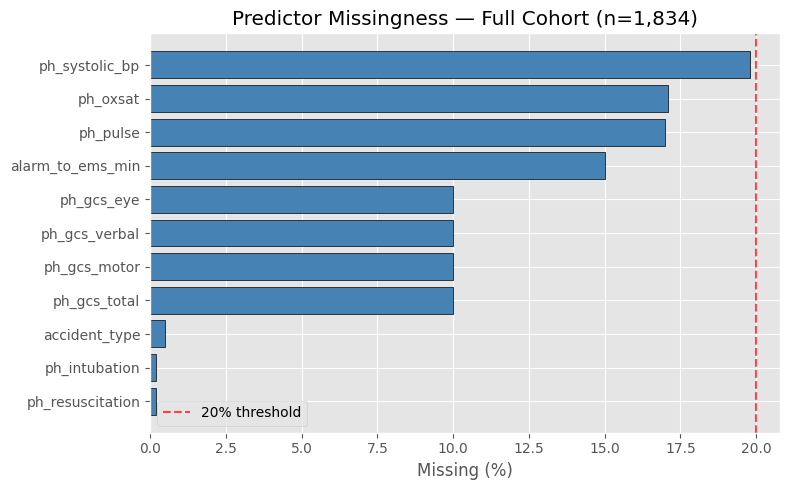


=== SPEARMAN CORRELATIONS — CONTINUOUS PREDICTORS ===

High correlations (|r| > 0.8):


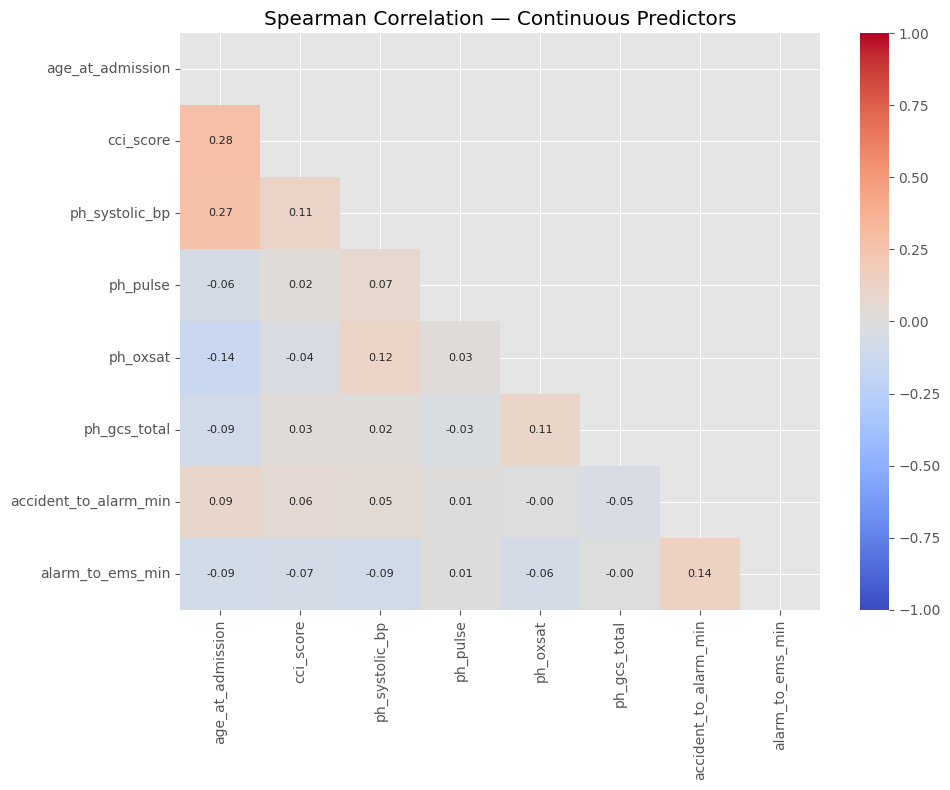


=== GCS COMPONENT COLLINEARITY ===
               ph_gcs_total  ph_gcs_eye  ph_gcs_verbal  ph_gcs_motor
ph_gcs_total          1.000       0.823          0.930         0.811
ph_gcs_eye            0.823       1.000          0.693         0.718
ph_gcs_verbal         0.930       0.693          1.000         0.751
ph_gcs_motor          0.811       0.718          0.751         1.000

Rows where total == eye + verbal + motor: 1600/1627 (98.3%)
ph_gcs_total is a mathematical derivative — drop in favor of components.

=== NEAR-ZERO VARIANCE CHECK ===
  cci_chf: 0.50% prevalence
  cci_connective_tissue: 0.44% prevalence
  cci_copd: 1.00% prevalence
  cci_dementia: 0.72% prevalence
  cci_dm_complex: 0.50% prevalence
  cci_hemiplegia: 0.00% prevalence
  cci_hiv: 0.06% prevalence
  cci_liver_mild: 0.00% prevalence
  cci_mets: 0.44% prevalence
  cci_mi: 0.88% prevalence
  cci_pvd: 0.61% prevalence
  cci_ulcer: 0.11% prevalence
  dx_transfer_STR: 0.22% prevalence
  hosp_gcs_unk: 1.00% prevalence
  p

In [33]:
print("\n=== PREDICTOR MISSINGNESS ===")
ph_predictors = [
    'age_at_admission', 'demo_sex', 'demo_cause', 'demo_injury_type',
    'accident_type', 'cci_score', 'ph_systolic_bp', 'ph_bp_measured',
    'ph_pulse', 'ph_pulse_measured', 'ph_oxsat',
    'ph_gcs_eye', 'ph_gcs_verbal', 'ph_gcs_motor', 'ph_gcs_total',
    'ph_gcs_unk', 'ph_intubation', 'ph_resuscitation',
    'received_any_crystalloids', 'received_any_colloids',
    'alarm_to_ems_min',
]

miss = df[ph_predictors].isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
miss_df = pd.DataFrame({'missing_n': miss, 'missing_pct': miss_pct})
miss_df = miss_df[miss_df['missing_n'] > 0].sort_values('missing_pct', ascending=False)
print(miss_df.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(miss_df.index, miss_df['missing_pct'], edgecolor='black', color='steelblue')
ax.axvline(x=20, color='red', linestyle='--', alpha=0.7, label='20% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Predictor Missingness — Full Cohort (n=1,834)')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# --- Collinearity check (continuous predictors) ---
print("\n=== SPEARMAN CORRELATIONS — CONTINUOUS PREDICTORS ===")
cont_cols = [
    'age_at_admission', 'cci_score', 'ph_systolic_bp', 'ph_pulse',
    'ph_oxsat', 'ph_gcs_total', 'accident_to_alarm_min',
    'alarm_to_ems_min', 
]

corr = df[cont_cols].corr(method='spearman')

print("\nHigh correlations (|r| > 0.8):")
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        r = corr.iloc[i, j]
        if abs(r) > 0.8:
            print(f"  {corr.index[i]} vs {corr.columns[j]}: r={r:.3f}")

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    ax=ax, annot_kws={'size': 8}
)
ax.set_title('Spearman Correlation — Continuous Predictors')
plt.tight_layout()
plt.show()

# --- GCS component collinearity ---
print("\n=== GCS COMPONENT COLLINEARITY ===")
gcs_numeric = df[['ph_gcs_total', 'ph_gcs_eye', 'ph_gcs_verbal', 'ph_gcs_motor']].copy()
for col in ['ph_gcs_eye', 'ph_gcs_verbal', 'ph_gcs_motor']:
    gcs_numeric[col] = gcs_numeric[col].astype(str).str.extract(r'^(\d+)').astype(float)

gcs_corr = gcs_numeric.corr(method='spearman')
print(gcs_corr.round(3))

complete = gcs_numeric.dropna()
reconstructed = complete['ph_gcs_eye'] + complete['ph_gcs_verbal'] + complete['ph_gcs_motor']
match = (reconstructed == complete['ph_gcs_total']).sum()
print(f"\nRows where total == eye + verbal + motor: {match}/{len(complete)} ({match/len(complete):.1%})")
print("ph_gcs_total is a mathematical derivative — drop in favor of components.")

# --- Near-zero variance check ---
print("\n=== NEAR-ZERO VARIANCE CHECK ===")
bool_cols_check = [c for c in df.columns if df[c].dtype == 'boolean']
for col in sorted(bool_cols_check):
    prev = df[col].mean() * 100
    if prev < 1 or prev > 99:
        print(f"  {col}: {prev:.2f}% prevalence")

print("\nCategorical rare levels:")
cat_cols_check = [c for c in ph_predictors if df[c].dtype.name == 'category']
for col in cat_cols_check:
    vc = df[col].value_counts(normalize=True, dropna=True) * 100
    for level, pct in vc.items():
        if pct < 1:
            print(f"  {col}: '{level}' = {pct:.2f}%")


### 8.3 Variable classification

All columns assigned to mutually exclusive lists based on:
- Riley parameter budget (≤25 post-encoding for LR)
- Clinical timing: T0 = Notarzt arrival on scene

Predictor sets are as follows:
- primary prediction model:  included only variables available at T0: demographics, injury mechanism, comorbidity burden measured by the weighted Charlson Comorbidity Index, GCS components, EMS-assessed vital signs, and temporal intervals
- sensitivity analysis 1: included prehospital interventions (crystalloid administration, resuscitation measures, and intubation) to the primary T0-based predictor set to assess whether later-available information improved prediction
- sensitivity analysis 2: A full predictor set including individual comorbidity flags was evaluated only in tree-based models

In [34]:
# --- PRIMARY OUTCOME ---
outcomes_primary = ['iss_gte20']

# --- SECONDARY OUTCOMES (descriptive only, not modeled) ---
outcomes_secondary = [
    'dx_survival',              # In-hospital mortality
    'icu_efforts',              # ICU admission
    'icu_mechvent',             # Mechanical ventilation
    'surgery_first_24h',        # Emergency surgery within 24h
    'dx_hospitalization_days',  # Length of stay
]

# --- PRIMARY PREDICTOR SET (primary analysis, all models) ────────────────────────────────────────────────────

predictors_primary = [
    # Demographics (5 post-encoding params: 1 + 1 + 2 + 2 - 1 dropped)
    'age_at_admission',         # Continuous, 1 param
    'demo_sex',                 # Binary, 1 param
    'demo_cause',               # 3 levels after collapsing unknown → 2 params
    'demo_injury_type',         # 3 levels after collapsing unknown → 2 params
    # Mechanism (4 post-encoding params)
    'accident_type',            # 5 levels (after collapse) → 4 params
    # Comorbidity (1 post-encoding param)
    'cci_score',                # Integer, 1 param
    # Prehospital vitals — assessed by EMS, available at Notarzt arrival
    # (7 post-encoding params)
    'ph_systolic_bp',           # Continuous, 1 param
    'ph_pulse',                 # Continuous, 1 param
    'ph_oxsat',                 # Continuous, 1 param
    'ph_gcs_eye',               # Ordinal → numeric, 1 param
    'ph_gcs_verbal',            # Ordinal → numeric, 1 param
    'ph_gcs_motor',             # Ordinal → numeric, 1 param
    'ph_gcs_unk',               # Binary MNAR indicator, 1 param
    # Temporal (2 post-encoding params)
    'accident_to_alarm_min',    # Continuous, 1 param
    'alarm_to_ems_min',         # Continuous, 1 param
]

print(f"\n=== PRIMARY PREDICTOR SET (primary analysis) ===")
print(f"Pre-encoding: {len(predictors_primary)} variables")
print(f"Post-encoding: 22 parameters")
print(f"Riley budget (25): MET — 3 parameters headroom")
print(f"Clinical timing: T0 (Notarzt arrival), assessment only")
 
 
# --- SA1: + PREHOSPITAL INTERVENTIONS (sensitivity analysis) ─────────────────
# Adds interventions regardless of provider type (EMS or Notarzt).
# Tests whether knowing what was done improves prediction beyond assessment.
 
predictors_interventions_additions = [
    'received_any_crystalloids', # 3 levels → 2 params — EMS-administered
    'ph_resuscitation',          # 3 levels → 2 params — likely EMS/bystander
    'ph_intubation',            # 3 levels → 2 params — Notarzt-only procedure
]
 
predictors_sa1 = predictors_primary + predictors_interventions_additions
 
print(f"\n=== SA1: + PREHOSPITAL INTERVENTIONS (sensitivity analysis) ===")
print(f"Pre-encoding: {len(predictors_sa1)} variables")
print(f"Post-encoding: 26 parameters")
print(f"Riley budget (25): 1 over — acceptable with conservative c-statistic")
 
 
# --- FULL PREDICTOR SET (sensitivity analysis, XGBoost only) ──────────────
# Adds all individual comorbidity flags and measurement variables.
# Not Riley-compliant — tests whether granular information improves tree models.
 
predictors_full_additions = [
    # Measurement flags
    'ph_bp_measured',           # Binary after collapse → 1 param
    'ph_pulse_measured',        # Binary after collapse → 1 param
    # Individual comorbidity flags
    'cci_cancer', 'cci_copd', 'cci_cva', 'cci_dm_simple',
    'cci_renal', 'cci_other',
    'px_afib', 'px_alcohol_abuse', 'px_any_cci',
    'px_any_comorbidity', 'px_cad', 'px_depression',
    'px_diabetes_any', 'px_hypertension', 'px_malignancy_any',
]
 
predictors_sa2 = predictors_sa1 + predictors_full_additions

print(f"\n=== SA2: FULL PREDICTOR SET (sensitivity analysis, RF/XGBoost only) ===")
print(f"Pre-encoding: {len(predictors_sa2)} variables")
print(f"Post-encoding: ~47 parameters")
print(f"Riley budget (25): EXCEEDS — RF/XGBoost only")


# --- SUBGROUP VARIABLES ---
subgroups = [
    'notarzt_dispatch_level',   # Ordinal 0/1/2
    'helicopter_transport',     # Binary
]

# --- STB COMPARATOR ---
stb_comparator = [
    'stb_mechanism_met',        # Rule-based classifier, not a predictor
]

# --- DESCRIPTORS ─────────────────────────────────────────────
# Variables used for cohort characterisation. Includes:

table1_main = [
    # Demographics
    'demo_age_category',
    'demo_accident_type',
    'admission_year',

    # Comorbidity burden
    'cci_cat',

    # Prehospital physiology
    'ph_gcs_total',
    'ph_systolic_bp',
    'ph_pulse',
    'ph_oxsat',
    'ph_gcs_motor_unmeasured',

    # Prehospital treatment
    'ph_crystalloids_ml',
    'ph_colloids_ml',
]

table1_supplement = [
    # Individual comorbidity flags
    'px_osteoporosis',
    'px_anticoagulation',
    'cci_chf',
    'cci_dementia',
    'cci_mi',
    'cci_pvd',
    'cci_connective_tissue',
    'cci_mets',
    'cci_dm_complex',
    'cci_hiv',
    'cci_liver_mild',
    'cci_ulcer',
     'cci_hemiplegia', 

    # Injury severity / post-hoc descriptors
    'dx_iss_calculated',
    'et_ais_head_gte3',
    'et_max_AIS',
    'injury_abdomen',
    'injury_cervical_spine',
    'injury_external_skin_and_thermal_injuries',
    'injury_head_cranium_and_brain',
    'injury_lower_extremity_pelvis_and_buttocks',
    'injury_lumbar_spine',
    'injury_neck',
    'injury_thoracic_spine',
    'injury_thorax',
    'injury_upper_extremity',
    'injury_face_includes_eye_and_ear',


    # Hospital vital variables
    'ed_chest_drainage',
    'ed_coagulation_drugs_1',
    'ed_colloids_ml',
    'ed_crystalloids_ml',
    'ed_destination_after_initialtx',
    'ed_efforts',
    'ed_imaging_type_1',
    'ed_imaging_type_2',
    'ed_intubation',
    'ed_vasoactive_tx',
    'hosp_gcs_eye', 'hosp_gcs_verbal', 'hosp_gcs_motor', 
    'hosp_gcs_total', 'hosp_systolic_bp', 'hosp_pulse', 
    'hosp_resp_rate', 'hosp_oxsat', 'hosp_hemoglobin', 
    'hosp_plateletct', 'hosp_lactate', 'hosp_inr', 
    'hosp_tpz', 'hosp_fibrinogen', 'hosp_temp_c', 
    'hosp_ptt_sec', 'hosp_base_excess', 'hosp_gcs_unk', 
    'hosp_temp_c_unk', 'hosp_ptt_measured', 
    

    # Hospital / surgery / ICU
    'had_ENT',
    'had_abdominal',
    'had_any_surgery',
    'had_cardiovascular',
    'had_musculoskeletal',
    'had_neurosurgery',
    'had_skin_wound',
    'had_spinal_surgery',
    'had_thoracic_respiratory',
    'hosp_first_ffp_number_24h',
    'hosp_first_kidney_replacement_24h',
    'hosp_first_surgical_intervention_24h',
    'hosp_first_tc_24h',
    'icu_duration_hrs',
    'icu_mechvent_hrs',
    'ed_imaging_type',
    'et_surgical_sessions_nr', 'et_ais_codes_nr', 'et_surgical_procedures_nr',

    # Discharge / outcomes
    'had_any_complication',
    'dx_complication_type_1',
    'dx_complication_type_2',
    'dx_with_braindamage',
    'dx_gos',
    'dx_destination',
    'dx_transfer_STR',
    'dx_rehospitalization_same',
    'received_wbct',
    'received_any_colloids',
    'received_any_coag_drug',
    'dx_death_in_28days',
]

# --- ADMIN ---
admin = ['unique_id']


# ── Verify classification — no overlaps, no gaps ─────────────────────────────
# Use predictors_full as the superset for assignment checking.
# Some comorbidity variables intentionally appear in both predictors_full
# and descriptors_table1 (needed for both modeling SA and Table 1).
 
all_assigned = (
    outcomes_primary + outcomes_secondary +
    predictors_primary + predictors_sa1 + predictors_sa2 +
    subgroups + stb_comparator +
    table1_main + table1_supplement + admin
)
 
counts = Counter(all_assigned)
duplicates = {k: v for k, v in counts.items() if v > 1}
 
print(f"\n=== CLASSIFICATION VERIFICATION ===")
print(f"Total assignments: {len(all_assigned)}")
if duplicates:
    print(f"Duplicates (intentional — full predictors overlap with descriptors):")
    for var, count in sorted(duplicates.items()):
        print(f"  {var}: {count}x")
else:
    print("No duplicates.")
 
all_unique = set(all_assigned)
unassigned = [c for c in df.columns if c not in all_unique]
print(f"\nCurrent df columns: {len(df.columns)}")
print(f"Uniquely assigned: {len(all_unique)}")
print(f"Unassigned: {len(unassigned)}")
if unassigned:
    print(f"  {unassigned}")
 
not_in_df = [c for c in all_unique if c not in df.columns]
if not_in_df:
    print(f"\nAssigned but not in df: {not_in_df}")
else:
    print("All assigned variables present in df.")



=== PRIMARY PREDICTOR SET (primary analysis) ===
Pre-encoding: 15 variables
Post-encoding: 22 parameters
Riley budget (25): MET — 3 parameters headroom
Clinical timing: T0 (Notarzt arrival), assessment only

=== SA1: + PREHOSPITAL INTERVENTIONS (sensitivity analysis) ===
Pre-encoding: 18 variables
Post-encoding: 26 parameters
Riley budget (25): 1 over — acceptable with conservative c-statistic

=== SA2: FULL PREDICTOR SET (sensitivity analysis, RF/XGBoost only) ===
Pre-encoding: 35 variables
Post-encoding: ~47 parameters
Riley budget (25): EXCEEDS — RF/XGBoost only

=== CLASSIFICATION VERIFICATION ===
Total assignments: 177
Duplicates (intentional — full predictors overlap with descriptors):
  accident_to_alarm_min: 3x
  accident_type: 3x
  age_at_admission: 3x
  alarm_to_ems_min: 3x
  cci_score: 3x
  demo_cause: 3x
  demo_injury_type: 3x
  demo_sex: 3x
  ph_gcs_eye: 3x
  ph_gcs_motor: 3x
  ph_gcs_unk: 3x
  ph_gcs_verbal: 3x
  ph_intubation: 2x
  ph_oxsat: 4x
  ph_pulse: 4x
  ph_resus

## 9. Train/test split

Stratified 80/20 split on primary outcome (ISS ≥20).

Full dataframe (predictors + outcomes + descriptors) is split to preserve all variables for Table 1 generation and subgroup analyses on test set.

In [35]:
df_prev = df.copy()

y_strat = df['iss_gte20'].astype(int)

df_train, df_test = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_strat
)

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# Save split indices for reproducibility
train_ids = df_train['unique_id'].tolist()
test_ids = df_test['unique_id'].tolist()

# Verify
print(f"=== TRAIN/TEST SPLIT ===")
print(f"Total:  {len(df):,}")
print(f"Train:  {len(df_train):,} ({len(df_train)/len(df):.1%})")
print(f"Test:   {len(df_test):,} ({len(df_test)/len(df):.1%})")
print(f"\nClass balance:")
print(f"  Train ISS ≥20: {df_train['iss_gte20'].mean():.1%}")
print(f"  Test  ISS ≥20: {df_test['iss_gte20'].mean():.1%}")
print(f"\nShapes:")
print(f"  Train: {df_train.shape}")
print(f"  Test:  {df_test.shape}")

# Assertions
assert len(df_train) + len(df_test) == len(df), "Split sizes don't sum"
assert set(train_ids).isdisjoint(set(test_ids)), "ID leakage between splits"
assert abs(df_train['iss_gte20'].mean() - df_test['iss_gte20'].mean()) < 0.02, \
    "Stratification failed — class balance differs >2%"
print("\nAssertions passed")

=== TRAIN/TEST SPLIT ===
Total:  1,809
Train:  1,447 (80.0%)
Test:   362 (20.0%)

Class balance:
  Train ISS ≥20: 55.4%
  Test  ISS ≥20: 55.5%

Shapes:
  Train: (1447, 143)
  Test:  (362, 143)

Assertions passed


## 10. Mini-EDA & feature selection on training data

Outcome-dependent analyses performed strictly on training data.

Confirms predictor behaviour and informs encoding decisions.

Important observations:
- Missingness all below 20%, appropriate level for using MICE
- GCS components are the strongest predictors of ISS >= 20, then oxsat and vitals and age
  - Important to note that the effect sizes are small, the majority of patients look very similar and the signal comes from the tails (extremes) of each variable
- Temporal variables and cci_score are not individually significantly significant to ISS outcome
- ph_intubation has a strong outcome separation which is why it might introduce leakage into the primary models (reverse-causality)
- Encoding plan confirmed
  - Binary variables: 0/1
  - Ordinal GCS components: numeric extraction
  - Nominal categoricals with rate levels: collapse rare cases into suitable category then one-hot

=== MISSINGNESS IN TRAINING PREDICTORS ===
                       missing_n  missing_pct
ph_systolic_bp               283         19.6
accident_to_alarm_min        256         17.7
ph_oxsat                     247         17.1
ph_pulse                     245         16.9
alarm_to_ems_min             216         14.9
ph_gcs_eye                   143          9.9
ph_gcs_verbal                143          9.9
ph_gcs_motor                 143          9.9
accident_type                  6          0.4


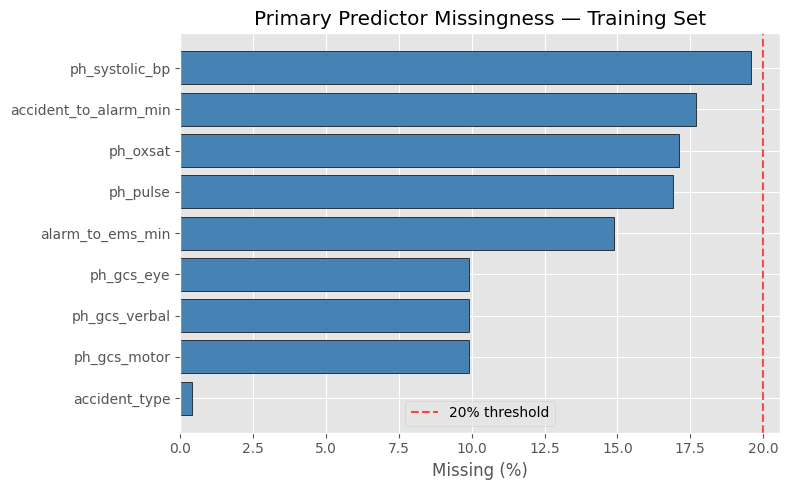

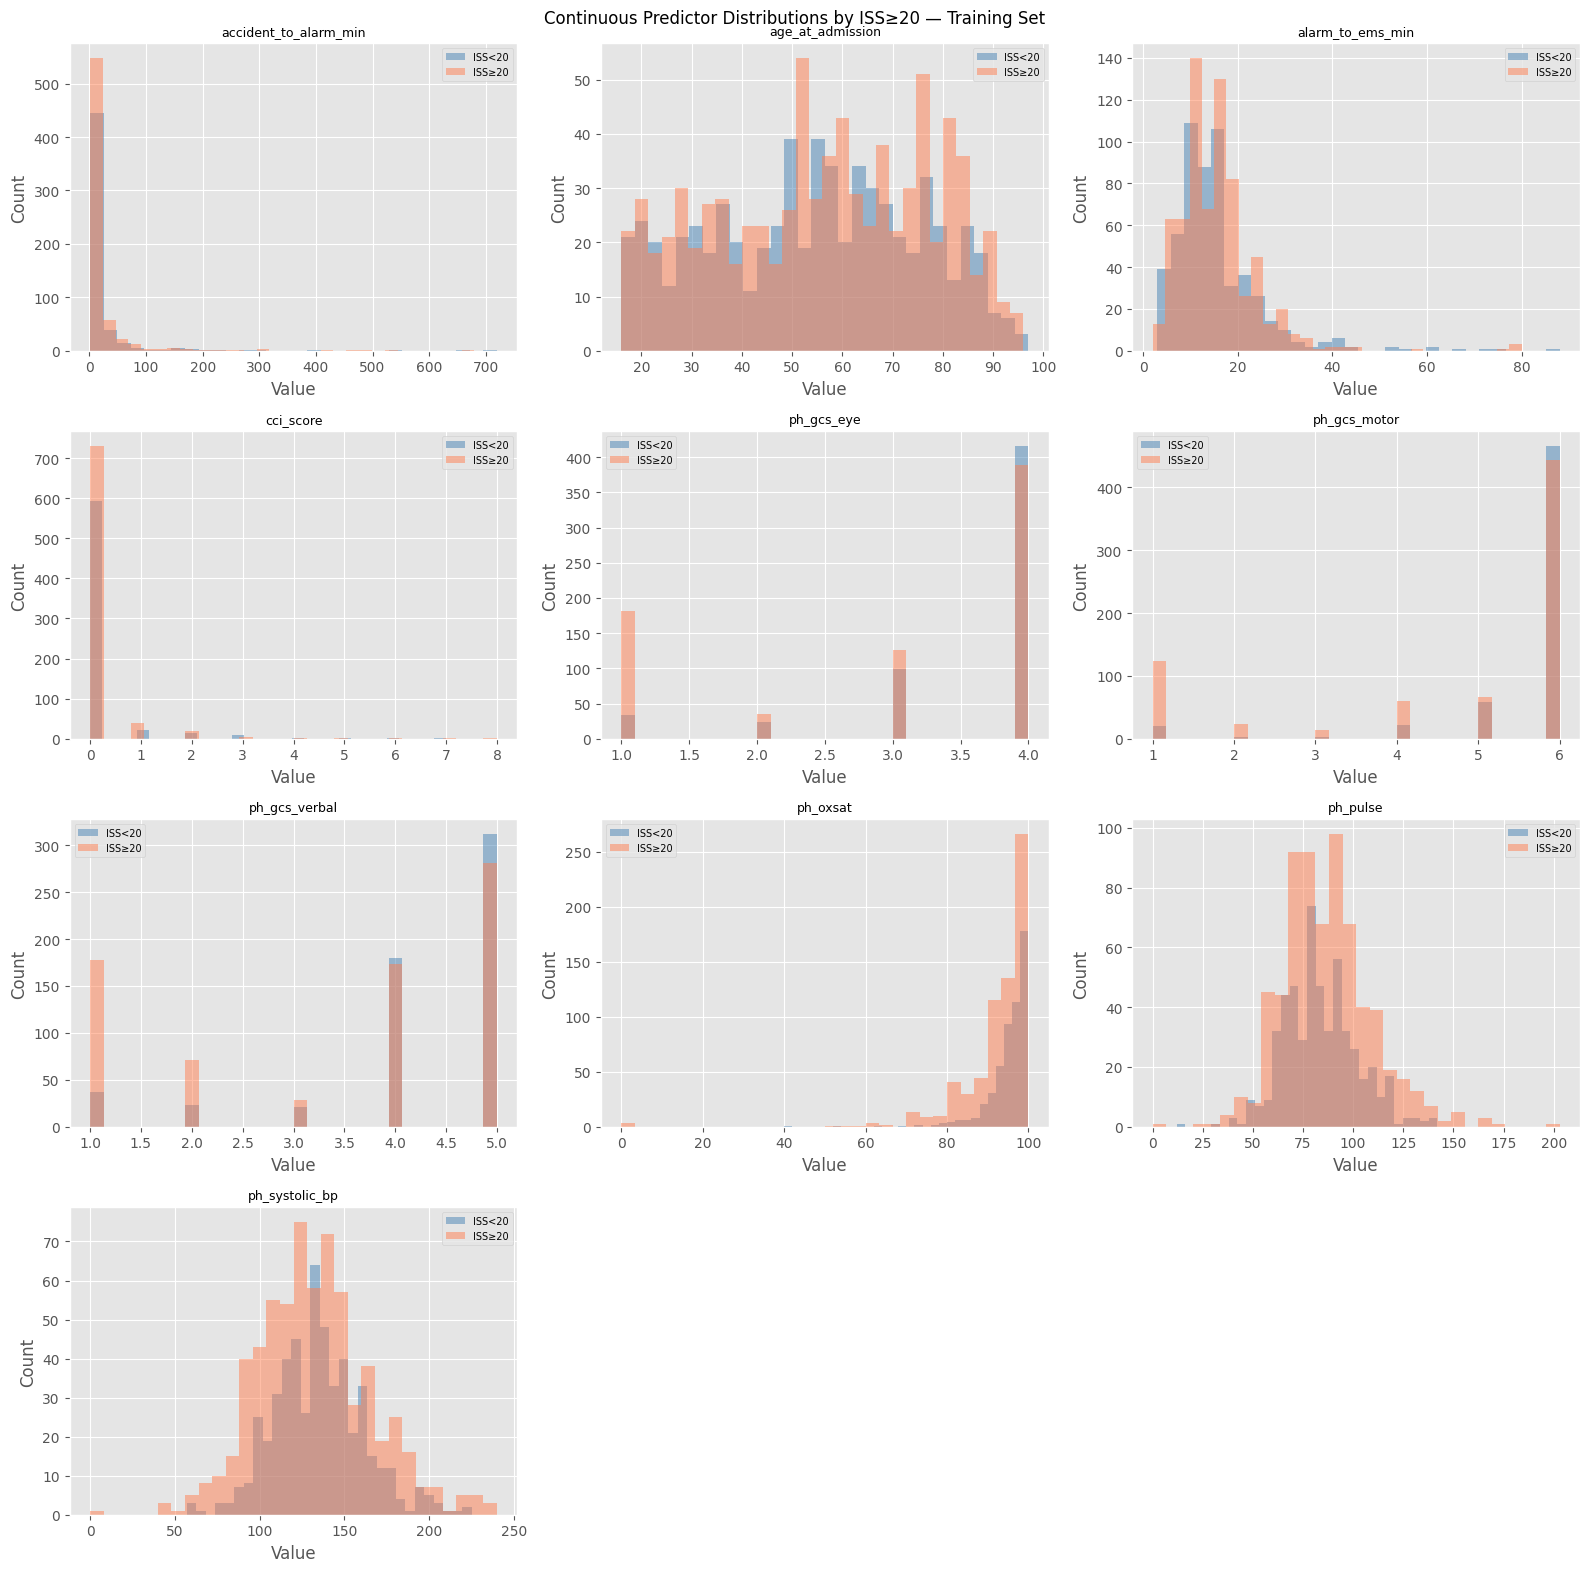


=== UNIVARIATE ASSOCIATIONS — CONTINUOUS (Mann-Whitney U) ===
            predictor  median_ISS<20  median_ISS>=20  p_value
           ph_gcs_eye            4.0             4.0   0.0000
         ph_gcs_motor            6.0             6.0   0.0000
        ph_gcs_verbal            5.0             4.0   0.0000
             ph_oxsat           96.0            95.0   0.0001
       ph_systolic_bp          133.0           130.0   0.0200
             ph_pulse           82.0            85.0   0.0276
     age_at_admission           56.0            58.0   0.1064
     alarm_to_ems_min           14.0            14.0   0.2650
            cci_score            0.0             0.0   0.5759
accident_to_alarm_min           10.0            10.0   0.7604


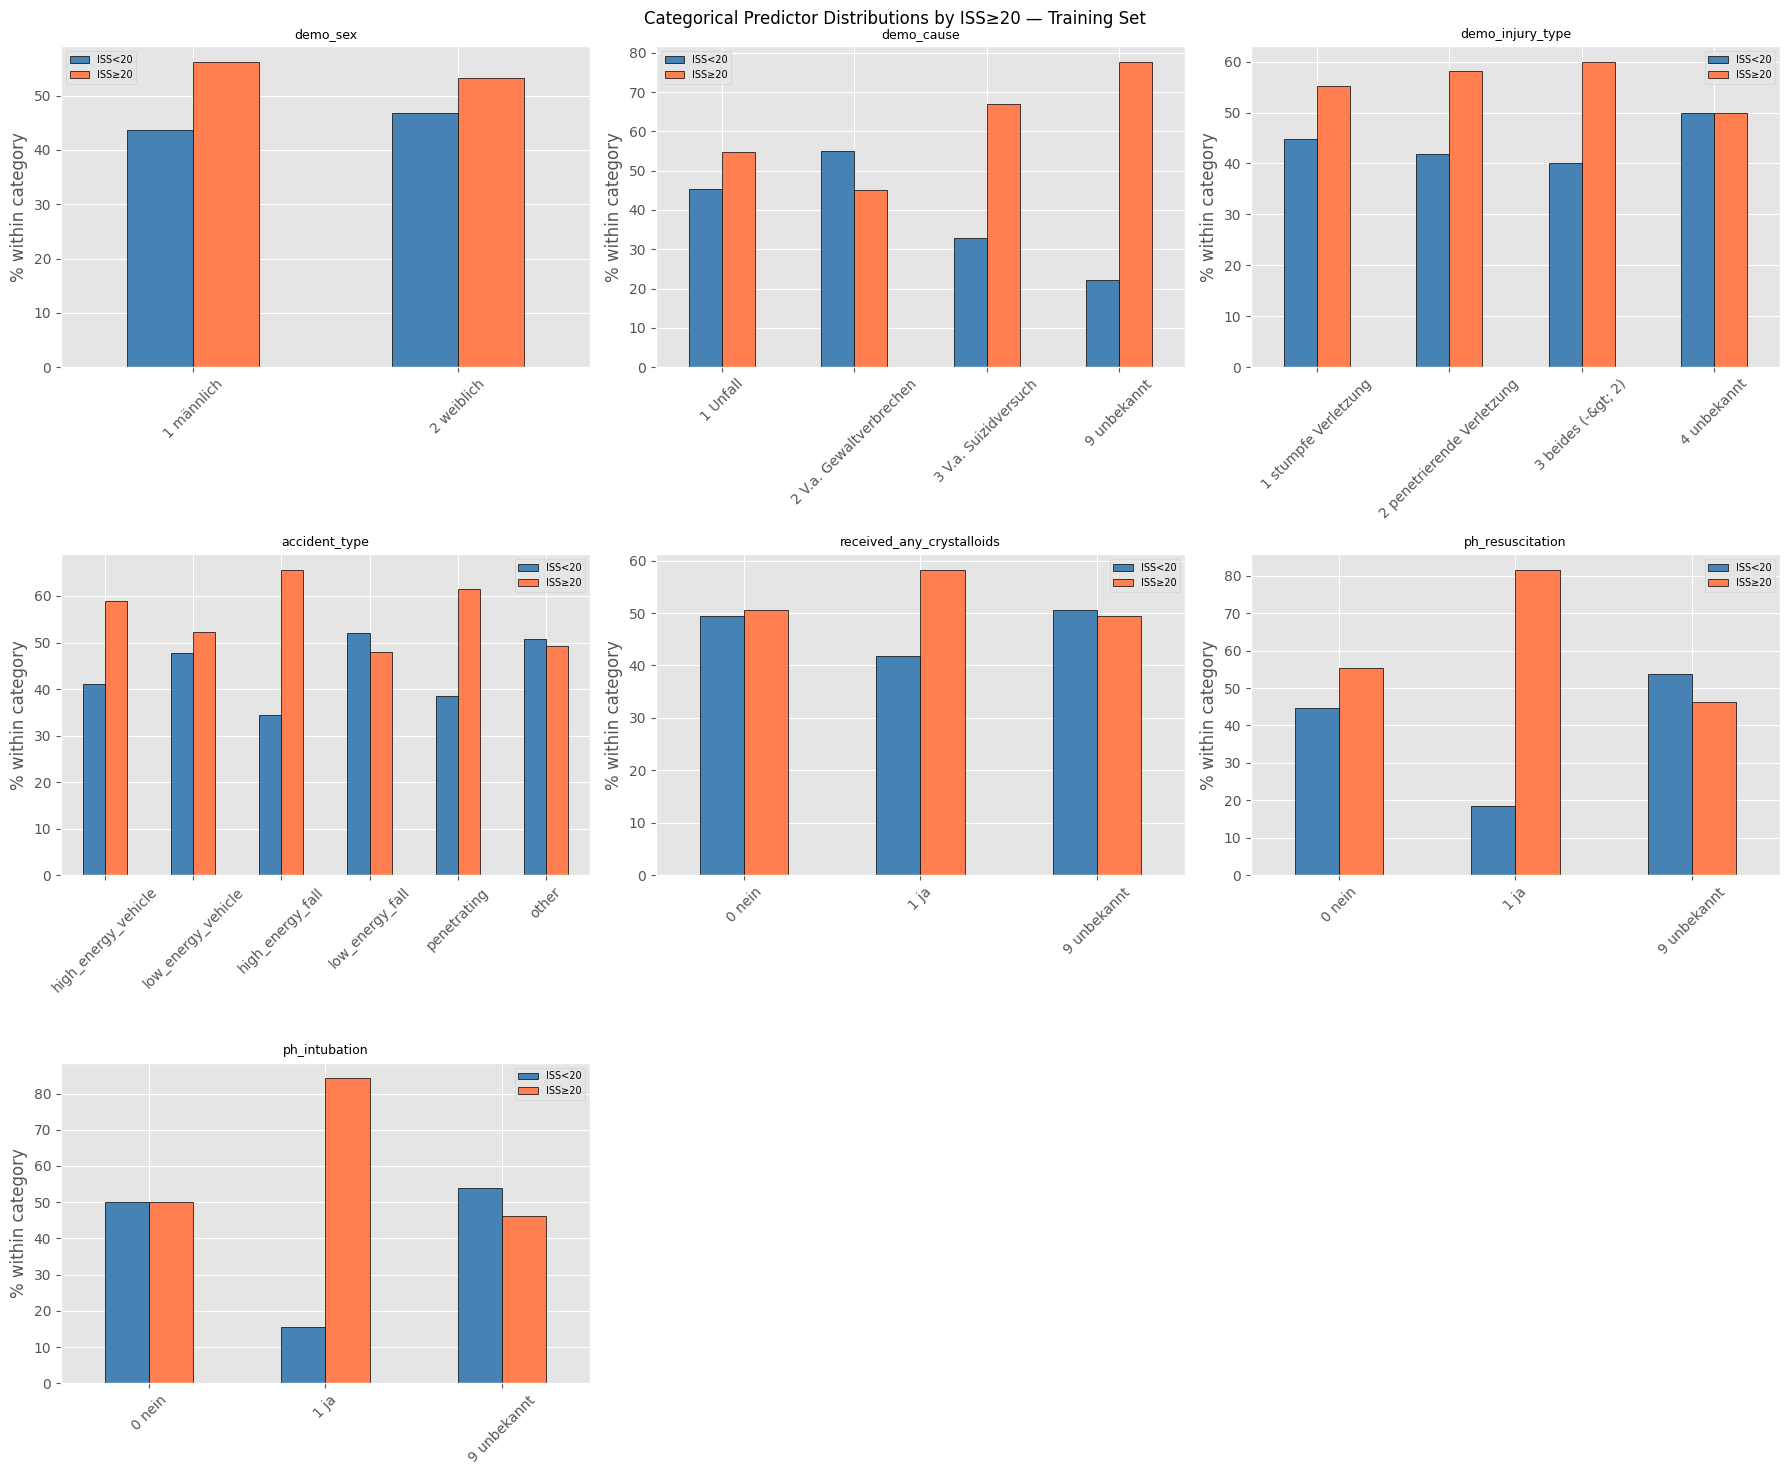


=== RARE LEVELS — ENCODING DECISIONS ===

demo_cause:
  1 Unfall: 1336 (92.3%)
  3 V.a. Suizidversuch: 82 (5.7%)
  2 V.a. Gewaltverbrechen: 20 (1.4%) ← RARE
  9 unbekannt: 9 (0.6%) ← RARE
  Plan: Collapse "9 unbekannt" into "1 Unfall"

demo_injury_type:
  1 stumpfe Verletzung: 1378 (95.2%)
  2 penetrierende Verletzung: 62 (4.3%)
  3 beides (-&gt; 2): 5 (0.3%) ← RARE
  4 unbekannt: 2 (0.1%) ← RARE
  Plan: Collapse "4 unbekannt" into "1 stumpfe Verletzung", "3 beides" into "2 penetrierende Verletzung"

accident_type:
  low_energy_fall: 429 (29.6%)
  high_energy_vehicle: 326 (22.5%)
  high_energy_fall: 323 (22.3%)
  low_energy_vehicle: 178 (12.3%)
  other: 146 (10.1%)
  penetrating: 39 (2.7%)
  nan: 6 (0.4%) ← RARE
  Plan: Collapse "penetrating" + "other" into "other_penetrating" during encoding

=== SECTION 10 COMPLETE ===
Training set: 1447 rows
Primary predictors examined: 15
Intervention predictors examined: 3
No variable selection changes — predictor set confirmed as defined in sect

In [36]:
y_train = df_train['iss_gte20'].astype(int)

# ── 10.1 Missingness in training predictors ──────────────────────────────────

print("=== MISSINGNESS IN TRAINING PREDICTORS ===")
miss = df_train[predictors_primary].isnull().sum()
miss_pct = (miss / len(df_train) * 100).round(1)
miss_df = pd.DataFrame({'missing_n': miss, 'missing_pct': miss_pct})
miss_df = miss_df[miss_df['missing_n'] > 0].sort_values('missing_pct', ascending=False)
print(miss_df.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(miss_df.index, miss_df['missing_pct'], edgecolor='black', color='steelblue')
ax.axvline(x=20, color='red', linestyle='--', alpha=0.7, label='20% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Primary Predictor Missingness — Training Set')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()


# ── 10.2 Continuous predictor distributions by outcome ───────────────────────

continuous_preds = [
    'age_at_admission', 'cci_score', 'ph_systolic_bp', 'ph_pulse',
    'ph_oxsat', 'accident_to_alarm_min', 'alarm_to_ems_min',
]

# GCS components — extract numeric prefix for plotting
gcs_preds = ['ph_gcs_eye', 'ph_gcs_verbal', 'ph_gcs_motor']
df_train_num = df_train.copy()
for col in gcs_preds:
    df_train_num[col] = (df_train_num[col].astype(str)
                         .str.extract(r'^(\d+)')[0]
                         .replace('nan', np.nan)
                         .astype(float))

all_continuous = continuous_preds + gcs_preds

n_cols = 3
n_rows = int(np.ceil(len(all_continuous) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(sorted(all_continuous)):
    ax = axes[i]
    for outcome, label, color in [(0, 'ISS<20', 'steelblue'), (1, 'ISS≥20', 'coral')]:
        data = df_train_num.loc[y_train == outcome, col].dropna()
        ax.hist(data, bins=30, alpha=0.5, label=label, color=color, edgecolor='none')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Continuous Predictor Distributions by ISS≥20 — Training Set', fontsize=12)
plt.tight_layout()
plt.show()


# ── 10.3 Univariate associations — continuous predictors ─────────────────────

print("\n=== UNIVARIATE ASSOCIATIONS — CONTINUOUS (Mann-Whitney U) ===")
assoc_results = []
for col in sorted(all_continuous):
    s = df_train_num[col]
    valid = s.notna() & y_train.notna()
    g0 = s[valid & (y_train == 0)]
    g1 = s[valid & (y_train == 1)]
    if len(g0) > 0 and len(g1) > 0:
        stat, p = mannwhitneyu(g0, g1)
        assoc_results.append({
            'predictor': col,
            'median_ISS<20': round(g0.median(), 1),
            'median_ISS>=20': round(g1.median(), 1),
            'p_value': round(p, 4)
        })

assoc_df = pd.DataFrame(assoc_results).sort_values('p_value')
print(assoc_df.to_string(index=False))


# ── 10.4 Categorical predictor distributions by outcome ─────────────────────

categorical_tier1 = [
    'demo_sex', 'demo_cause', 'demo_injury_type', 'accident_type',
]

# Also check intervention variables for reference
categorical_interventions = [
    'received_any_crystalloids', 'ph_resuscitation', 'ph_intubation',
]

all_categorical = categorical_tier1 + categorical_interventions

n_cols = 3
n_rows = int(np.ceil(len(all_categorical) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(all_categorical):
    ax = axes[i]
    ct = pd.crosstab(df_train[col], y_train, normalize='index') * 100
    ct.columns = ['ISS<20', 'ISS≥20']
    ct.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('% within category')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Predictor Distributions by ISS≥20 — Training Set', fontsize=12)
plt.tight_layout()
plt.show()


# ── 10.5 Rare level verification for encoding ───────────────────────────────
# Confirm rare levels that need collapsing during encoding (section 12)

print("\n=== RARE LEVELS — ENCODING DECISIONS ===")
encoding_checks = {
    'demo_cause': 'Collapse "9 unbekannt" into "1 Unfall"',
    'demo_injury_type': 'Collapse "4 unbekannt" into "1 stumpfe Verletzung", '
                        '"3 beides" into "2 penetrierende Verletzung"',
    'accident_type': 'Collapse "penetrating" + "other" into '
                     '"other_penetrating" during encoding',
}

for col, plan in encoding_checks.items():
    print(f"\n{col}:")
    vc = df_train[col].value_counts(dropna=False)
    for level, count in vc.items():
        pct = count / len(df_train) * 100
        flag = ' ← RARE' if pct < 2 else ''
        print(f"  {level}: {count} ({pct:.1f}%){flag}")
    print(f"  Plan: {plan}")


# ── 10.6 Summary ─────────────────────────────────────────────────────────────

print("\n=== SECTION 10 COMPLETE ===")
print(f"Training set: {len(df_train)} rows")
print(f"Primary predictors examined: {len(predictors_primary)}")
print(f"Intervention predictors examined: {len(categorical_interventions)}")
print("No variable selection changes — predictor set confirmed as defined in section 9.")
print("Encoding plan for rare levels confirmed for section 12.")

## 11. Encoding

Categorical variables encoded to numeric format for modeling. Encoding applied identically to train and test sets. 

Encoding strategy (designed for LR compatibility, also used by tree models):
- Boolean → int (0/1)
- Ordinal GCS → numeric prefix extraction
- Binary categorical (demo_sex) → int
- Nominal with rare levels → collapse then one-hot (drop_first=True)
- Three-level clinical/intervention → one-hot (drop_first=True)

Note: drop_first=True used throughout for LR interpretability.
Reference categories: largest group (nominal) or '0 nein' (clinical).

In [37]:
# ── 11.1 Prepare encoding dataframes ─────────────────────────────────────────
# Encode all predictor sets + variables needed for STB comparator.
# Descriptors and outcomes stay in df_train/df_test (not encoded).

all_predictor_cols = list(set(
    predictors_primary + predictors_sa1 + predictors_sa2
))

# Extract outcome variable
y_train = df_train['iss_gte20'].astype(int)
y_test = df_test['iss_gte20'].astype(int)

df_enc_train = df_train[all_predictor_cols].copy()
df_enc_test = df_test[all_predictor_cols].copy()

print(f"=== ENCODING START ===")
print(f"Columns to encode: {len(all_predictor_cols)}")
print(f"Train: {df_enc_train.shape}, Test: {df_enc_test.shape}")
 
 
# ── 11.2 Boolean to int ───────────────────────────────────────────────────────
 
bool_preds = [c for c in df_enc_train.columns if df_enc_train[c].dtype == 'boolean']
print(f"\nBoolean predictors: {bool_preds}")
 
for col in bool_preds:
    df_enc_train[col] = df_enc_train[col].astype(object).map({True: 1, False: 0})
    df_enc_test[col] = df_enc_test[col].astype(object).map({True: 1, False: 0})
 
print("Boolean encoding complete.")
 
 
# ── 11.3 Ordinal GCS to numeric ───────────────────────────────────────────────
# Extract leading digit from string categories (e.g. '4 Spontan' → 4.0)
 
gcs_preds = ['ph_gcs_eye', 'ph_gcs_verbal', 'ph_gcs_motor']
 
for col in gcs_preds:
    df_enc_train[col] = (df_enc_train[col].astype(str)
                         .str.extract(r'^(\d+)')[0]
                         .replace('nan', np.nan)
                         .astype(float))
    df_enc_test[col] = (df_enc_test[col].astype(str)
                        .str.extract(r'^(\d+)')[0]
                        .replace('nan', np.nan)
                        .astype(float))
 
print("\nGCS numeric encoding:")
for col in gcs_preds:
    print(f"  {col}: min={df_enc_train[col].min()}, max={df_enc_train[col].max()}, "
          f"NaN={df_enc_train[col].isna().sum()}")
 
 
# ── 11.4 Binary categorical to int ────────────────────────────────────────────
 
df_enc_train['demo_sex'] = df_enc_train['demo_sex'].astype(str).map(
    {'1 männlich': 1, '2 weiblich': 0}
)
df_enc_test['demo_sex'] = df_enc_test['demo_sex'].astype(str).map(
    {'1 männlich': 1, '2 weiblich': 0}
)
print(f"\ndemo_sex encoded: {df_enc_train['demo_sex'].value_counts(dropna=False).to_dict()}")
 
 
# ── 11.5 Collapse rare levels ────────────────────────────────────────────────
# Decisions from section 11 mini-EDA on training data.
 
# demo_cause: '9 unbekannt' (0.5%) → '1 Unfall'
cause_collapse = {'9 unbekannt': '1 Unfall'}
 
# demo_injury_type: '4 unbekannt' (0.1%) → '1 stumpfe Verletzung'
#                   '3 beides' (0.3%) → '2 penetrierende Verletzung'
injury_collapse = {
    '3 beides (-&gt; 2)': '2 penetrierende Verletzung',
    '4 unbekannt': '1 stumpfe Verletzung'
}
 
# accident_type: 'penetrating' (3.3%) + 'other' (10.3%) → 'other_penetrating'
accident_collapse = {
    'penetrating': 'other_penetrating',
    'other': 'other_penetrating'
}
 
for col, mapping in [
    ('demo_cause', cause_collapse),
    ('demo_injury_type', injury_collapse),
    ('accident_type', accident_collapse),
]:
    df_enc_train[col] = df_enc_train[col].astype(str).replace(mapping)
    df_enc_test[col] = df_enc_test[col].astype(str).replace(mapping)
 
print("\nAfter rare level collapse:")
for col in ['demo_cause', 'demo_injury_type', 'accident_type']:
    print(f"\n  {col}:")
    print(f"  {df_enc_train[col].value_counts(dropna=False).to_dict()}")
 
 
# ── 11.6 Nominal categories to one-hot (drop_first=True) ─────────────────────
# Reference categories (dropped): largest group in each variable.
 
nominal_cols = ['accident_type', 'demo_cause', 'demo_injury_type']
 
df_enc_train = pd.get_dummies(df_enc_train, columns=nominal_cols,
                               drop_first=True, dtype=float)
 
test_dummies = pd.get_dummies(df_enc_test[nominal_cols],
                               drop_first=True, dtype=float)
df_enc_test = df_enc_test.drop(columns=nominal_cols)
df_enc_test = pd.concat([df_enc_test, test_dummies], axis=1)
 
# Align test to train (handle categories absent in test)
for col in df_enc_train.columns:
    if col not in df_enc_test.columns:
        df_enc_test[col] = 0.0
 
nominal_dummies = [c for c in df_enc_train.columns
                   if any(c.startswith(p + '_') for p in nominal_cols)]
print(f"\nNominal dummy columns: {nominal_dummies}")
print(f"Train: {df_enc_train.shape}, Test: {df_enc_test.shape}")
 
 # Remove nan dummy — these are missing values, not a category
nan_dummy = 'accident_type_nan'
if nan_dummy in df_enc_train.columns:
    df_enc_train = df_enc_train.drop(columns=[nan_dummy])
    df_enc_test = df_enc_test.drop(columns=[nan_dummy])
    print(f"Dropped {nan_dummy} (missingness, not a category)")
 
# ── 11.7 Three-level clinical/intervention to one-hot (drop_first=True) ──────
# ja/nein/unbekannt variables. Reference category: '0 nein' (dropped).
 
three_level_cols = ['ph_intubation', 'ph_resuscitation',
                    'received_any_crystalloids']
 
# Only encode columns that exist (they should all be present)
three_level_present = [c for c in three_level_cols if c in df_enc_train.columns]
 
print(f"\nThree-level clinical columns: {three_level_present}")
for col in three_level_present:
    print(f"  {col}: {df_enc_train[col].value_counts(dropna=False).to_dict()}")
 
train_dummies_clin = pd.get_dummies(df_enc_train[three_level_present],
                                     drop_first=True, dtype=float)
test_dummies_clin = pd.get_dummies(df_enc_test[three_level_present],
                                    drop_first=True, dtype=float)
 
# Align test to train
for col in train_dummies_clin.columns:
    if col not in test_dummies_clin.columns:
        test_dummies_clin[col] = 0.0
test_dummies_clin = test_dummies_clin[train_dummies_clin.columns]
 
df_enc_train = df_enc_train.drop(columns=three_level_present)
df_enc_test = df_enc_test.drop(columns=three_level_present)
df_enc_train = pd.concat([df_enc_train, train_dummies_clin], axis=1)
df_enc_test = pd.concat([df_enc_test, test_dummies_clin], axis=1)
 
print(f"\nClinical dummy columns: {train_dummies_clin.columns.tolist()}")
 
 
# ── 11.8 Measurement flags (full predictor set only) to one-hot ───────────────
# ph_bp_measured, ph_pulse_measured — only in predictors_full_additions
 
meas_cols = ['ph_bp_measured', 'ph_pulse_measured']
meas_present = [c for c in meas_cols if c in df_enc_train.columns]
 
if meas_present:
    print(f"\nMeasurement flag columns: {meas_present}")
    for col in meas_present:
        print(f"  {col}: {df_enc_train[col].value_counts(dropna=False).to_dict()}")
 
    train_dummies_meas = pd.get_dummies(df_enc_train[meas_present],
                                         drop_first=True, dtype=float)
    test_dummies_meas = pd.get_dummies(df_enc_test[meas_present],
                                        drop_first=True, dtype=float)
 
    for col in train_dummies_meas.columns:
        if col not in test_dummies_meas.columns:
            test_dummies_meas[col] = 0.0
    test_dummies_meas = test_dummies_meas[train_dummies_meas.columns]
 
    df_enc_train = df_enc_train.drop(columns=meas_present)
    df_enc_test = df_enc_test.drop(columns=meas_present)
    df_enc_train = pd.concat([df_enc_train, train_dummies_meas], axis=1)
    df_enc_test = pd.concat([df_enc_test, test_dummies_meas], axis=1)
 
    print(f"  Measurement dummy columns: {train_dummies_meas.columns.tolist()}")
 
 
# ── Map encoded columns back to predictor sets ────────────────────────────────
# Creates column lists for each predictor set in the encoded space.
# Used during modeling to select the right columns for each analysis.

def get_encoded_cols(base_vars, all_encoded_cols, all_base_vars=None):
    """Map pre-encoding variable names to post-encoding column names.
    all_base_vars used to resolve ambiguous prefix matches."""
    if all_base_vars is None:
        all_base_vars = base_vars
    cols = []
    for col in all_encoded_cols:
        best_match = None
        for v in all_base_vars:
            if col == v or col.startswith(v + '_'):
                if best_match is None or len(v) > len(best_match):
                    best_match = v
        if best_match is not None and best_match in base_vars:
            cols.append(col)
    return cols

all_enc_cols = df_enc_train.columns.tolist()
all_base = predictors_sa2  # superset of all base variable names

enc_primary = get_encoded_cols(predictors_primary, all_enc_cols, all_base)
enc_sa1     = get_encoded_cols(predictors_sa1,     all_enc_cols, all_base)
enc_sa2     = get_encoded_cols(predictors_sa2,     all_enc_cols, all_base)

print(f"\n=== ENCODED PREDICTOR SET COLUMN COUNTS ===")
print(f"Primary (assessment):          {len(enc_primary)} columns")
print(f"SA1 (+ interventions):         {len(enc_sa1)} columns")
print(f"SA2 (+ full comorbidity):      {len(enc_sa2)} columns")

# Verify primary parameter count matches Riley budget
print(f"\nPrimary Riley check: {len(enc_primary)} params vs budget of 25 → "
      f"{'MET' if len(enc_primary) <= 25 else 'EXCEEDED'}")

=== ENCODING START ===
Columns to encode: 35
Train: (1447, 35), Test: (362, 35)

Boolean predictors: ['px_diabetes_any', 'px_any_comorbidity', 'px_hypertension', 'cci_renal', 'px_alcohol_abuse', 'cci_other', 'cci_dm_simple', 'px_any_cci', 'px_afib', 'px_depression', 'ph_gcs_unk', 'px_malignancy_any', 'cci_cancer', 'cci_cva', 'px_cad', 'cci_copd']
Boolean encoding complete.

GCS numeric encoding:
  ph_gcs_eye: min=1.0, max=4.0, NaN=143
  ph_gcs_verbal: min=1.0, max=5.0, NaN=143
  ph_gcs_motor: min=1.0, max=6.0, NaN=143

demo_sex encoded: {1: 1045, 0: 402}

After rare level collapse:

  demo_cause:
  {'1 Unfall': 1345, '3 V.a. Suizidversuch': 82, '2 V.a. Gewaltverbrechen': 20}

  demo_injury_type:
  {'1 stumpfe Verletzung': 1380, '2 penetrierende Verletzung': 67}

  accident_type:
  {'low_energy_fall': 429, 'high_energy_vehicle': 326, 'high_energy_fall': 323, 'other_penetrating': 185, 'low_energy_vehicle': 178, np.str_('nan'): 6}

Nominal dummy columns: ['accident_type_high_energy_vehicl

## 12. Imputation

MICE (primary) and KNN (sensitivity check).

MNAR values protected from imputation and restored to NaN after.

Imputers fit on training data only, applied to test data.

In [38]:
# ── 12.1 Prepare imputation dataframes and MNAR masks ────────────────────────

df_imp_train = df_enc_train.copy()
df_imp_test = df_enc_test.copy()

# MNAR masks — derived from unencoded df_train/df_test
# These rows must NOT be imputed (structurally missing, not randomly missing)

# BP nicht messbar
bp_mnar_train = (df_train['ph_bp_measured'] == '0 nicht messbar').values
bp_mnar_test = (df_test['ph_bp_measured'] == '0 nicht messbar').values

# Pulse nicht messbar
pulse_mnar_train = (df_train['ph_pulse_measured'] == '0 nicht messbar').values
pulse_mnar_test = (df_test['ph_pulse_measured'] == '0 nicht messbar').values

# GCS unknown (intubated/unassessable)
gcs_unk_train = (df_imp_train['ph_gcs_unk'] == 1).values
gcs_unk_test = (df_imp_test['ph_gcs_unk'] == 1).values

# GCS motor unmeasured (from section 7.4 — 1 patient)
motor_unmeas_train = df_train['ph_gcs_motor_unmeasured'].astype(float).values
motor_unmeas_test = df_test['ph_gcs_motor_unmeasured'].astype(float).values

mnar_masks_train = {
    'ph_systolic_bp': bp_mnar_train,
    'ph_pulse':       pulse_mnar_train,
    'ph_gcs_eye':     gcs_unk_train,
    'ph_gcs_verbal':  gcs_unk_train,
    'ph_gcs_motor':   gcs_unk_train | (motor_unmeas_train == 1),
}

mnar_masks_test = {
    'ph_systolic_bp': bp_mnar_test,
    'ph_pulse':       pulse_mnar_test,
    'ph_gcs_eye':     gcs_unk_test,
    'ph_gcs_verbal':  gcs_unk_test,
    'ph_gcs_motor':   gcs_unk_test | (motor_unmeas_test == 1),
}

print("=== MNAR MASK COUNTS (train) ===")
for col, mask in mnar_masks_train.items():
    print(f"  {col}: {mask.sum()} rows protected from imputation")


# ── 12.2 MICE imputation (primary) ───────────────────────────────────────────

mice_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10, random_state=RANDOM_STATE),
    max_iter=20,
    random_state=RANDOM_STATE,
    min_value=0
)

print("\nFitting MICE imputer on training data...")
train_mice = mice_imputer.fit_transform(df_imp_train)
print("Applying MICE to test data...")
test_mice = mice_imputer.transform(df_imp_test)

df_mice_train = pd.DataFrame(train_mice, columns=df_imp_train.columns)
df_mice_test = pd.DataFrame(test_mice, columns=df_imp_test.columns)

# Restore MNAR values to NaN
for col, mask in mnar_masks_train.items():
    df_mice_train.loc[mask, col] = np.nan
for col, mask in mnar_masks_test.items():
    df_mice_test.loc[mask, col] = np.nan

print("\nMICE imputation complete.")
print(f"Remaining NaN in train: {df_mice_train.isnull().sum().sum()}")
print(f"Remaining NaN in test:  {df_mice_test.isnull().sum().sum()}")

remaining = df_mice_train.isnull().sum()
remaining = remaining[remaining > 0]
if len(remaining) > 0:
    print("\nColumns with remaining NaN (MNAR — expected):")
    print(remaining)


# ── 12.3 KNN imputation (sensitivity check) ──────────────────────────────────

knn_imputer = KNNImputer(n_neighbors=5)

print("\nFitting KNN imputer on training data...")
train_knn = knn_imputer.fit_transform(df_imp_train)
print("Applying KNN to test data...")
test_knn = knn_imputer.transform(df_imp_test)

df_knn_train = pd.DataFrame(train_knn, columns=df_imp_train.columns)
df_knn_test = pd.DataFrame(test_knn, columns=df_imp_test.columns)

# Restore MNAR values to NaN
for col, mask in mnar_masks_train.items():
    df_knn_train.loc[mask, col] = np.nan
for col, mask in mnar_masks_test.items():
    df_knn_test.loc[mask, col] = np.nan

print("\nKNN imputation complete.")
print(f"Remaining NaN in train: {df_knn_train.isnull().sum().sum()}")
print(f"Remaining NaN in test:  {df_knn_test.isnull().sum().sum()}")

remaining_knn = df_knn_train.isnull().sum()
remaining_knn = remaining_knn[remaining_knn > 0]
if len(remaining_knn) > 0:
    print("\nColumns with remaining NaN (MNAR — expected):")
    print(remaining_knn)


# ── 12.4 Verify imputed distributions ────────────────────────────────────────

print("\n=== IMPUTATION DISTRIBUTION CHECK ===")
check_cols = ['ph_systolic_bp', 'ph_pulse', 'ph_oxsat',
              'ph_gcs_eye', 'ph_gcs_verbal', 'ph_gcs_motor',
              'accident_to_alarm_min', 'alarm_to_ems_min']

for col in check_cols:
    orig_mean = df_enc_train[col].mean()
    mice_mean = df_mice_train[col].mean()
    knn_mean = df_knn_train[col].mean()
    orig_std = df_enc_train[col].std()
    mice_std = df_mice_train[col].std()
    knn_std = df_knn_train[col].std()
    print(f"{col}:")
    print(f"  Original: mean={orig_mean:.2f}, std={orig_std:.2f}")
    print(f"  MICE:     mean={mice_mean:.2f}, std={mice_std:.2f}")
    print(f"  KNN:      mean={knn_mean:.2f}, std={knn_std:.2f}")

print(f"\n=== SECTION 12 COMPLETE ===")
print(f"MICE train: {df_mice_train.shape}, NaN: {df_mice_train.isnull().sum().sum()}")
print(f"MICE test:  {df_mice_test.shape}, NaN: {df_mice_test.isnull().sum().sum()}")
print(f"KNN train:  {df_knn_train.shape}, NaN: {df_knn_train.isnull().sum().sum()}")
print(f"KNN test:   {df_knn_test.shape}, NaN: {df_knn_test.isnull().sum().sum()}")

=== MNAR MASK COUNTS (train) ===
  ph_systolic_bp: 8 rows protected from imputation
  ph_pulse: 4 rows protected from imputation
  ph_gcs_eye: 141 rows protected from imputation
  ph_gcs_verbal: 141 rows protected from imputation
  ph_gcs_motor: 142 rows protected from imputation

Fitting MICE imputer on training data...
Applying MICE to test data...

MICE imputation complete.
Remaining NaN in train: 436
Remaining NaN in test:  120

Columns with remaining NaN (MNAR — expected):
ph_systolic_bp      8
ph_gcs_eye        141
ph_gcs_motor      142
ph_gcs_verbal     141
ph_pulse            4
dtype: int64

Fitting KNN imputer on training data...
Applying KNN to test data...

KNN imputation complete.
Remaining NaN in train: 436
Remaining NaN in test:  120

Columns with remaining NaN (MNAR — expected):
ph_systolic_bp      8
ph_gcs_eye        141
ph_gcs_motor      142
ph_gcs_verbal     141
ph_pulse            4
dtype: int64

=== IMPUTATION DISTRIBUTION CHECK ===
ph_systolic_bp:
  Original: mean=

## 13. Scaling

RobustScaler applied to continuous and ordinal columns.

Fit on MICE training data only, applied to all four datasets.

cci_score excluded (IQR=0, scaling produces division by zero).

Binary/dummy columns not scaled (already 0/1).

In [39]:

scale_cols = [
    'age_at_admission',
    'ph_systolic_bp', 'ph_pulse', 'ph_oxsat',
    'ph_gcs_eye', 'ph_gcs_verbal', 'ph_gcs_motor',
    'accident_to_alarm_min', 'alarm_to_ems_min',
]

scaler = RobustScaler()
scaler.fit(df_mice_train[scale_cols].dropna())

def apply_scaling(df, scaler, cols):
    df_scaled = df.copy()
    for col in cols:
        non_null = df_scaled[col].notna()
        if non_null.sum() > 0:
            df_scaled.loc[non_null, col] = scaler.transform(
                df_scaled.loc[non_null, cols]
            )[:, cols.index(col)]
    return df_scaled

df_mice_train_scaled = apply_scaling(df_mice_train, scaler, scale_cols)
df_mice_test_scaled  = apply_scaling(df_mice_test,  scaler, scale_cols)
df_knn_train_scaled  = apply_scaling(df_knn_train,  scaler, scale_cols)
df_knn_test_scaled   = apply_scaling(df_knn_test,   scaler, scale_cols)

# ── Verify ────────────────────────────────────────────────────────────────────
print("=== SCALING VERIFICATION ===")
print("\nScaled columns — train medians and IQR:")
for col in scale_cols:
    median = df_mice_train_scaled[col].median()
    q1 = df_mice_train_scaled[col].quantile(0.25)
    q3 = df_mice_train_scaled[col].quantile(0.75)
    iqr = q3 - q1
    print(f"  {col}: median={median:.3f}, IQR={iqr:.3f}")

print("\nUnscaled cci_score (confirm unchanged):")
print(f"  mean={df_mice_train_scaled['cci_score'].mean():.3f}, "
      f"max={df_mice_train_scaled['cci_score'].max():.0f}")

print("\nBinary columns spot check (should be 0/1):")
for col in ['demo_sex', 'ph_gcs_unk', 'cci_cancer']:
    unique = sorted(df_mice_train_scaled[col].dropna().unique())
    print(f"  {col}: {unique}")

print("\nMNAR NaN preserved after scaling:")
for col in ['ph_systolic_bp', 'ph_pulse', 'ph_gcs_eye',
            'ph_gcs_verbal', 'ph_gcs_motor']:
    n_nan = df_mice_train_scaled[col].isna().sum()
    print(f"  {col}: {n_nan} NaN")

print(f"\n=== SECTION 14 COMPLETE ===")
print(f"MICE train scaled: {df_mice_train_scaled.shape}")
print(f"MICE test scaled:  {df_mice_test_scaled.shape}")
print(f"KNN train scaled:  {df_knn_train_scaled.shape}")
print(f"KNN test scaled:   {df_knn_test_scaled.shape}")

=== SCALING VERIFICATION ===

Scaled columns — train medians and IQR:
  age_at_admission: median=0.000, IQR=0.993
  ph_systolic_bp: median=0.000, IQR=0.972
  ph_pulse: median=0.083, IQR=0.958
  ph_oxsat: median=0.000, IQR=1.143
  ph_gcs_eye: median=0.000, IQR=1.000
  ph_gcs_verbal: median=0.000, IQR=1.000
  ph_gcs_motor: median=0.000, IQR=1.000
  accident_to_alarm_min: median=0.000, IQR=1.075
  alarm_to_ems_min: median=0.067, IQR=1.111

Unscaled cci_score (confirm unchanged):
  mean=0.178, max=8

Binary columns spot check (should be 0/1):
  demo_sex: [np.float64(0.0), np.float64(1.0)]
  ph_gcs_unk: [np.float64(0.0), np.float64(1.0)]
  cci_cancer: [np.float64(0.0), np.float64(1.0)]

MNAR NaN preserved after scaling:
  ph_systolic_bp: 8 NaN
  ph_pulse: 4 NaN
  ph_gcs_eye: 141 NaN
  ph_gcs_verbal: 141 NaN
  ph_gcs_motor: 142 NaN

=== SECTION 14 COMPLETE ===
MICE train scaled: (1447, 44)
MICE test scaled:  (362, 44)
KNN train scaled:  (1447, 44)
KNN test scaled:   (362, 44)


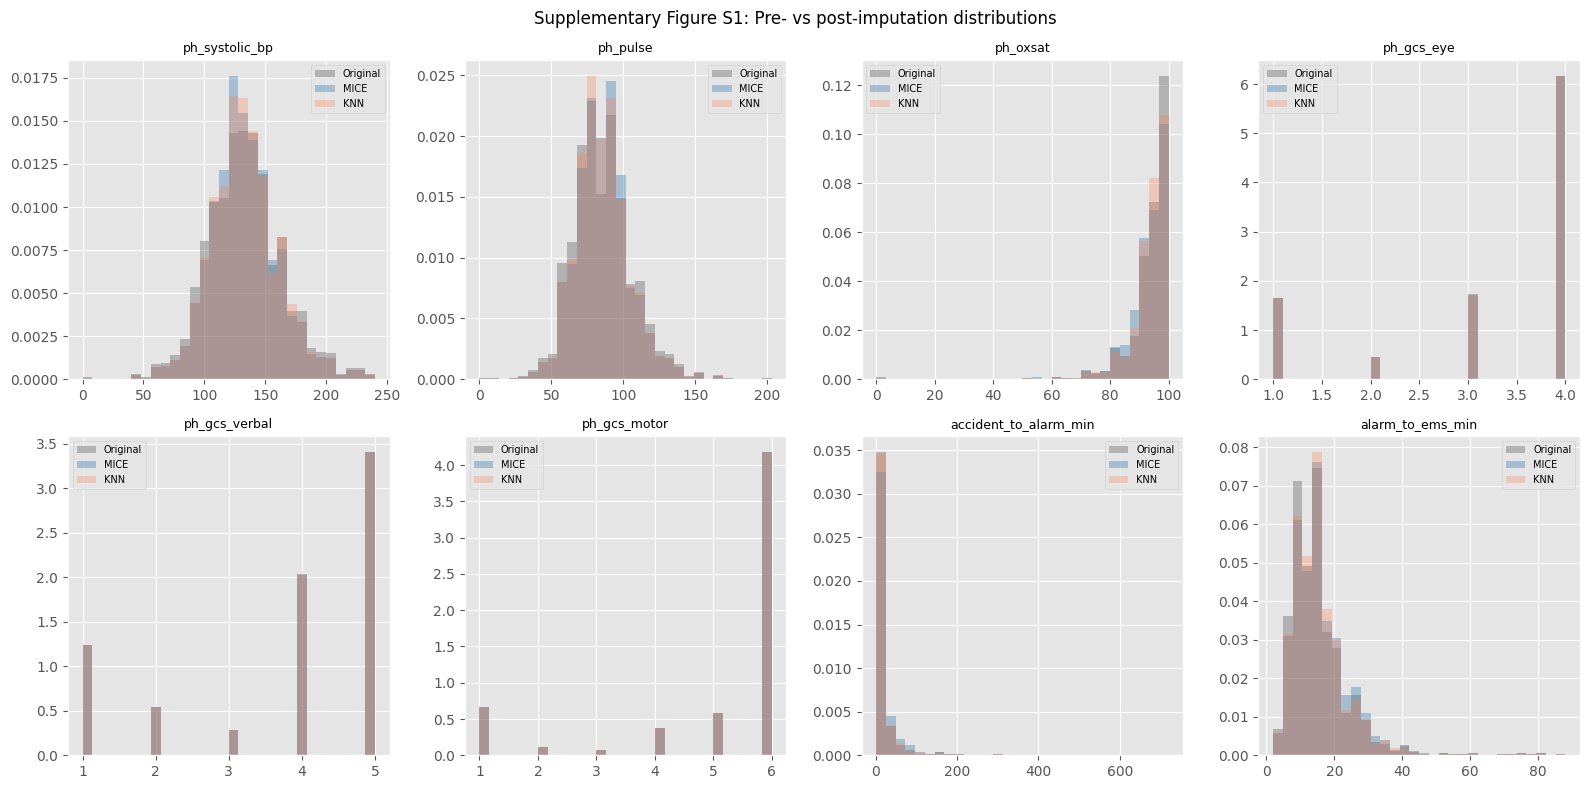

In [40]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

check_cols = ['ph_systolic_bp', 'ph_pulse', 'ph_oxsat',
              'ph_gcs_eye', 'ph_gcs_verbal', 'ph_gcs_motor',
              'accident_to_alarm_min', 'alarm_to_ems_min']

for i, col in enumerate(check_cols):
    ax = axes[i]
    orig = df_enc_train[col].dropna()
    mice = df_mice_train[col].dropna()
    knn = df_knn_train[col].dropna()
    
    ax.hist(orig, bins=30, alpha=0.5, color='gray', label='Original', density=True)
    ax.hist(mice, bins=30, alpha=0.4, color='steelblue', label='MICE', density=True)
    ax.hist(knn, bins=30, alpha=0.3, color='coral', label='KNN', density=True)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Supplementary Figure S1: Pre- vs post-imputation distributions', fontsize=12)
plt.tight_layout()
plt.savefig('../data/supp_fig_s1_imputation.png', dpi=300, bbox_inches='tight')
plt.show()

## 14. Primary Modeling — Primary Predictors

Three models developed on primary (assessment-only) predictors:
- Logistic Regression (baseline)
- Random Forest
- XGBoost

LR and RF: complete cases only (MNAR rows excluded)(n≈1,304 train, n≈325 test)

XGBoost: full dataset (handles NaN natively)(n=1,467 train, n=367 test)


All models evaluated on held-out test set.
Threshold selection via cross-validation on training folds.
SHAP feature importance for tree-based models.

Difference in test set composition is a limitation but excluded patients represent a clinically distinct subgroup, not a random sample.


### 14.1 Complete case preparation
MNAR rows have NaN in vitals/GCS components. These patients had unmeasurable vitals or unassessable GCS. LR and RF cannot handle NaN.

XGBoost handles NaN natively and uses the full dataset.

In [41]:
mnar_cols = ['ph_systolic_bp', 'ph_pulse', 'ph_gcs_eye', 'ph_gcs_verbal', 'ph_gcs_motor']

cc_train_mask = df_mice_train_scaled[mnar_cols].notna().all(axis=1)
cc_test_mask = df_mice_test_scaled[mnar_cols].notna().all(axis=1)

X_cc_train = df_mice_train_scaled[cc_train_mask].reset_index(drop=True)
y_cc_train = y_train[cc_train_mask].reset_index(drop=True)
X_cc_test = df_mice_test_scaled[cc_test_mask].reset_index(drop=True)
y_cc_test = y_test[cc_test_mask].reset_index(drop=True)

# XGBoost uses full dataset
X_xgb_train = df_mice_train_scaled.copy().astype(float)
X_xgb_test = df_mice_test_scaled.copy().astype(float)
y_xgb_train = y_train.copy()
y_xgb_test = y_test.copy()

print("=== DATA PREPARATION ===")
print(f"\nComplete cases (LR + RF):")
print(f"  Train: {X_cc_train.shape[0]:,} / {len(df_mice_train_scaled):,} "
      f"({cc_train_mask.sum()/len(df_mice_train_scaled):.1%} retained)")
print(f"  Test:  {X_cc_test.shape[0]:,} / {len(df_mice_test_scaled):,} "
      f"({cc_test_mask.sum()/len(df_mice_test_scaled):.1%} retained)")
print(f"  Train ISS ≥20: {y_cc_train.mean():.1%}")
print(f"  Test  ISS ≥20: {y_cc_test.mean():.1%}")

print(f"\nFull dataset (XGBoost):")
print(f"  Train: {X_xgb_train.shape[0]:,}")
print(f"  Test:  {X_xgb_test.shape[0]:,}")

# Riley check for complete case LR
print(f"\n=== RILEY CHECK FOR LR COMPLETE CASES ===")
print(f"  Primary parameters: {len(predictors_primary)}")
print(f"  LR training N: {len(X_cc_train)}")
riley_min = 1052  # from section 9.1: 21 params → min N ≈ 1,052
print(f"  Riley minimum N (21 params): {riley_min}")
print(f"  Status: {'✓ MET' if len(X_cc_train) >= riley_min else '✗ FAILED'}")

print(f"\n=== PRIMARY PREDICTOR COLUMNS ({len(predictors_primary)}) ===")
print(predictors_primary)

=== DATA PREPARATION ===

Complete cases (LR + RF):
  Train: 1,296 / 1,447 (89.6% retained)
  Test:  320 / 362 (88.4% retained)
  Train ISS ≥20: 55.9%
  Test  ISS ≥20: 58.8%

Full dataset (XGBoost):
  Train: 1,447
  Test:  362

=== RILEY CHECK FOR LR COMPLETE CASES ===
  Primary parameters: 15
  LR training N: 1296
  Riley minimum N (21 params): 1052
  Status: ✓ MET

=== PRIMARY PREDICTOR COLUMNS (15) ===
['age_at_admission', 'demo_sex', 'demo_cause', 'demo_injury_type', 'accident_type', 'cci_score', 'ph_systolic_bp', 'ph_pulse', 'ph_oxsat', 'ph_gcs_eye', 'ph_gcs_verbal', 'ph_gcs_motor', 'ph_gcs_unk', 'accident_to_alarm_min', 'alarm_to_ems_min']


### 14.2 Helper functions

Shared evaluation functions used across all models: threshold evaluation with ACS-COT metrics, cross-validation-based threshold selection, and a full model evaluation pipeline (CV, test metrics, ROC, calibration, threshold analysis).

In [42]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def evaluate_at_threshold(y_true, y_prob, threshold, label=''):
    """Evaluate binary classification at a given probability threshold."""
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan
    undertriage = fn / (tp + fn)
    overtriage = fp / (tn + fp)

    print(f"\n--- {label} (threshold={threshold:.4f}) ---")
    print(f"  Sensitivity:      {sensitivity:.3f}  (target ≥0.95)")
    print(f"  Specificity:      {specificity:.3f}")
    print(f"  Undertriage rate: {undertriage:.3f}  (target <0.05)")
    print(f"  Overtriage rate:  {overtriage:.3f}  (target 0.25-0.35)")
    print(f"  PPV:              {ppv:.3f}")
    print(f"  NPV:              {npv:.3f}")
    print(f"  TP={tp} FP={fp} FN={fn} TN={tn}")
    return {
        'threshold': threshold, 'sensitivity': sensitivity,
        'specificity': specificity, 'ppv': ppv, 'npv': npv,
        'undertriage': undertriage, 'overtriage': overtriage
    }


def select_acs_threshold_cv(model, X_train, y_train, cv, tier_cols):
    """
    Select ACS-COT threshold via cross-validation.
    For each fold: find threshold where sensitivity ≥ 0.95 on the validation fold,
    among those select the one with overtriage closest to 0.30.
    Return the median threshold across folds.

    [METHODS FLAG] Threshold selected via 5-fold CV on training data,
    not from refit model predictions. Reduces optimistic threshold selection.
    """
    fold_thresholds = []

    for train_idx, val_idx in cv.split(X_train[tier_cols], y_train):
        X_tr_fold = X_train[tier_cols].iloc[train_idx]
        y_tr_fold = y_train.iloc[train_idx]
        X_val_fold = X_train[tier_cols].iloc[val_idx]
        y_val_fold = y_train.iloc[val_idx]

        model_clone = model.__class__(**model.get_params())
        model_clone.fit(X_tr_fold, y_tr_fold)
        y_val_prob = model_clone.predict_proba(X_val_fold)[:, 1]

        fpr, tpr, thresholds = roc_curve(y_val_fold, y_val_prob)
        candidate_mask = tpr >= 0.95
        if candidate_mask.sum() > 0:
            candidate_fpr = fpr[candidate_mask]
            candidate_thresh = thresholds[candidate_mask]
            best_idx = np.argmin(np.abs(candidate_fpr - 0.30))
            fold_thresholds.append(candidate_thresh[best_idx])

    if fold_thresholds:
        median_threshold = np.median(fold_thresholds)
        print(f"  CV thresholds per fold: {[round(t, 4) for t in fold_thresholds]}")
        print(f"  Median threshold: {median_threshold:.4f}")
        return median_threshold
    else:
        print("  WARNING: No fold achieved sensitivity ≥ 0.95")
        return 0.5


def full_model_evaluation(model, X_train, y_train, X_test, y_test,
                          tier_cols, model_name, cv):
    """Run full evaluation pipeline for a single model."""
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")

    # CV AUC
    cv_scores = cross_val_score(
        model, X_train[tier_cols], y_train,
        cv=cv, scoring='roc_auc'
    )
    print(f"\nCV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Per fold: {cv_scores.round(4)}")

    # Refit on full training set
    model.fit(X_train[tier_cols], y_train)
    y_prob = model.predict_proba(X_test[tier_cols])[:, 1]

    # Test AUC and Brier
    test_auc = roc_auc_score(y_test, y_prob)
    brier = brier_score_loss(y_test, y_prob)
    print(f"\nTest AUC:    {test_auc:.4f}")
    print(f"Brier score: {brier:.4f}")

    # ACS-COT threshold via CV
    print(f"\nACS-COT threshold selection (CV):")
    acs_threshold = select_acs_threshold_cv(
        model, X_train, y_train, cv, tier_cols
    )

    # Evaluate at both thresholds
    results_05 = evaluate_at_threshold(
        y_test, y_prob, 0.5, f'{model_name} — threshold 0.5'
    )
    results_acs = evaluate_at_threshold(
        y_test, y_prob, acs_threshold, f'{model_name} — ACS-COT threshold'
    )

    # ROC + Calibration plots
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(fpr, tpr, label=f'{model_name} (AUC={test_auc:.3f})', lw=2)
    axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[0].set_xlabel('False Positive Rate (Overtriage)')
    axes[0].set_ylabel('True Positive Rate (Sensitivity)')
    axes[0].set_title(f'{model_name} — ROC Curve')
    axes[0].legend()

    CalibrationDisplay.from_predictions(
        y_test, y_prob, n_bins=10, ax=axes[1], name=model_name
    )
    axes[1].set_title(f'{model_name} — Calibration Curve')

    plt.tight_layout()
    plt.show()

    return {
        'model': model,
        'y_prob': y_prob,
        'cv_auc_mean': cv_scores.mean(),
        'cv_auc_std': cv_scores.std(),
        'test_auc': test_auc,
        'brier': brier,
        'acs_threshold': acs_threshold,
        'results_05': results_05,
        'results_acs': results_acs,
        'fpr': fpr,
        'tpr': tpr,
    }

### 14.3 Logistic Regression 

Complete cases only. L1/L2 penalty search via RandomizedSearchCV.
LR uses saga solver (supports all penalties).
Regularisation strength (C) tuned via random search, 100 iterations.


=== LOGISTIC REGRESSION — HYPERPARAMETER TUNING ===
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best params: {'C': np.float64(1.877688470273467), 'max_iter': 2000, 'penalty': 'l1', 'solver': 'saga'}
Best CV AUC: 0.6687

  Logistic Regression

CV AUC: 0.6687 ± 0.0294
  Per fold: [0.6748 0.6659 0.6146 0.6889 0.6996]

Test AUC:    0.7208
Brier score: 0.2078

ACS-COT threshold selection (CV):
  CV thresholds per fold: [np.float64(0.3788), np.float64(0.3458), np.float64(0.2803), np.float64(0.3927), np.float64(0.3714)]
  Median threshold: 0.3714

--- Logistic Regression — threshold 0.5 (threshold=0.5000) ---
  Sensitivity:      0.665  (target ≥0.95)
  Specificity:      0.591
  Undertriage rate: 0.335  (target <0.05)
  Overtriage rate:  0.409  (target 0.25-0.35)
  PPV:              0.698
  NPV:              0.553
  TP=125 FP=54 FN=63 TN=78

--- Logistic Regression — ACS-COT threshold (threshold=0.3714) ---
  Sensitivity:      0.936  (target ≥0.95)
  Specificity:      0.18

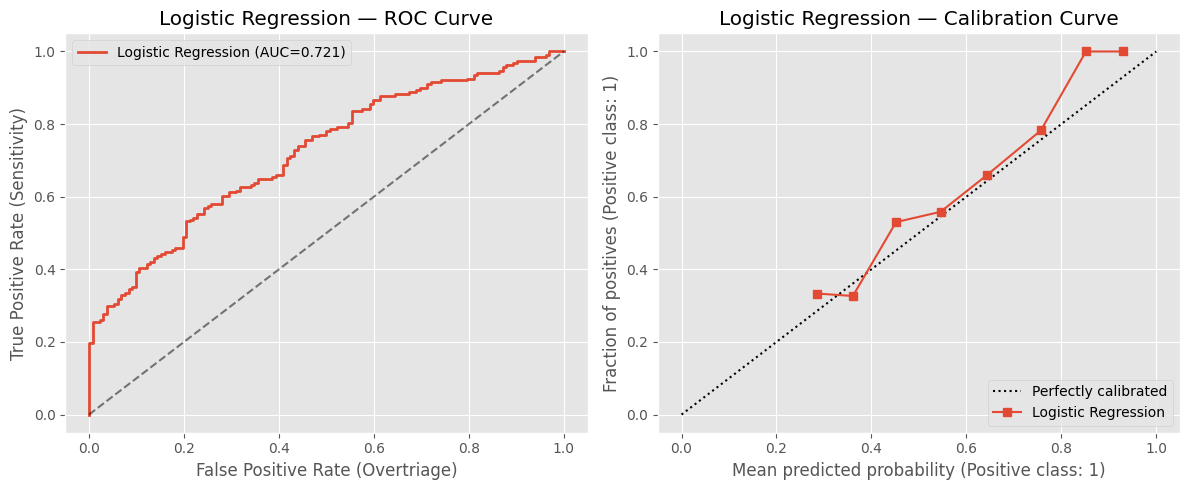

In [43]:
lr_param_dist = {
    'C': loguniform(1e-4, 1e2),
    'penalty': ['l1', 'l2'],
    'solver': ['saga'],
    'max_iter': [2000],
}

print("\n=== LOGISTIC REGRESSION — HYPERPARAMETER TUNING ===")
lr_search = RandomizedSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    param_distributions=lr_param_dist,
    n_iter=100,
    scoring='roc_auc',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
lr_search.fit(X_cc_train[enc_primary], y_cc_train)

print(f"\nBest params: {lr_search.best_params_}")
print(f"Best CV AUC: {lr_search.best_score_:.4f}")

lr_best = lr_search.best_estimator_

# Full evaluation
lr_results = full_model_evaluation(
    lr_best, X_cc_train, y_cc_train,
    X_cc_test, y_cc_test,
    enc_primary, 'Logistic Regression', cv
)

#### 14.3b LR coefficients

Standardised coefficients from the best LR model. Positive coefficients increase predicted probability of ISS ≥20; negative coefficients decrease it. Magnitude reflects relative importance after scaling.


LR Coefficients (Tier 1):
                                    feature  coefficient  abs_coefficient
              accident_type_low_energy_fall    -0.903281         0.903281
            accident_type_other_penetrating    -0.642868         0.642868
           accident_type_low_energy_vehicle    -0.619745         0.619745
                              ph_gcs_verbal    -0.441118         0.441118
                           age_at_admission     0.243493         0.243493
                               ph_gcs_motor    -0.199457         0.199457
          accident_type_high_energy_vehicle    -0.173570         0.173570
                                   ph_pulse     0.157614         0.157614
                                   ph_oxsat    -0.144050         0.144050
demo_injury_type_2 penetrierende Verletzung     0.136899         0.136899
                                   demo_sex     0.123087         0.123087
                             ph_systolic_bp    -0.066169         0.066169
           

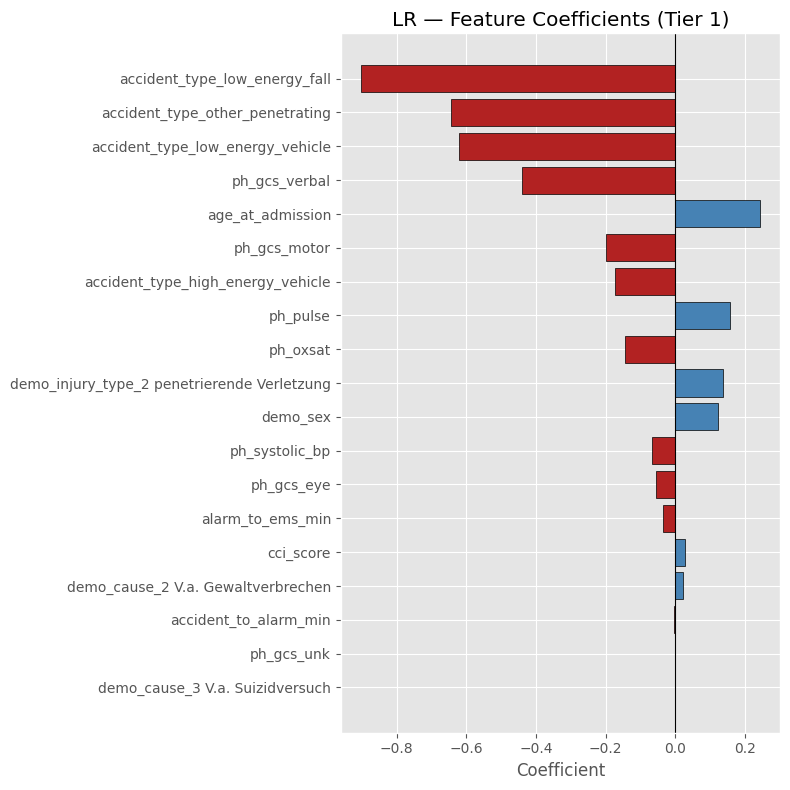

In [44]:
coef_df = pd.DataFrame({
    'feature': enc_primary,
    'coefficient': lr_best.coef_[0],
    'abs_coefficient': np.abs(lr_best.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

print("\nLR Coefficients (Tier 1):")
print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['steelblue' if c > 0 else 'firebrick' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='black')
ax.axvline(x=0, color='black', lw=0.8)
ax.set_xlabel('Coefficient')
ax.set_title('LR — Feature Coefficients (Tier 1)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 14.4 Random Forest 
Complete cases only (same as LR — scikit-learn RF does not handle NaN).
RF tuned via RandomizedSearchCV, 100 iterations.


=== RANDOM FOREST — HYPERPARAMETER TUNING ===
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best params: {'bootstrap': True, 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 11, 'n_estimators': 968}
Best CV AUC: 0.6755

  Random Forest

CV AUC: 0.6755 ± 0.0448
  Per fold: [0.7074 0.6243 0.6309 0.6734 0.7417]

Test AUC:    0.7165
Brier score: 0.2106

ACS-COT threshold selection (CV):
  CV thresholds per fold: [np.float64(0.3865), np.float64(0.3402), np.float64(0.3212), np.float64(0.357), np.float64(0.3962)]
  Median threshold: 0.3570

--- Random Forest — threshold 0.5 (threshold=0.5000) ---
  Sensitivity:      0.729  (target ≥0.95)
  Specificity:      0.606
  Undertriage rate: 0.271  (target <0.05)
  Overtriage rate:  0.394  (target 0.25-0.35)
  PPV:              0.725
  NPV:              0.611
  TP=137 FP=52 FN=51 TN=80

--- Random Forest — ACS-COT threshold (threshold=0.3570) ---
  Sensitivity:      0.963  (target ≥0.95)
  Specifi

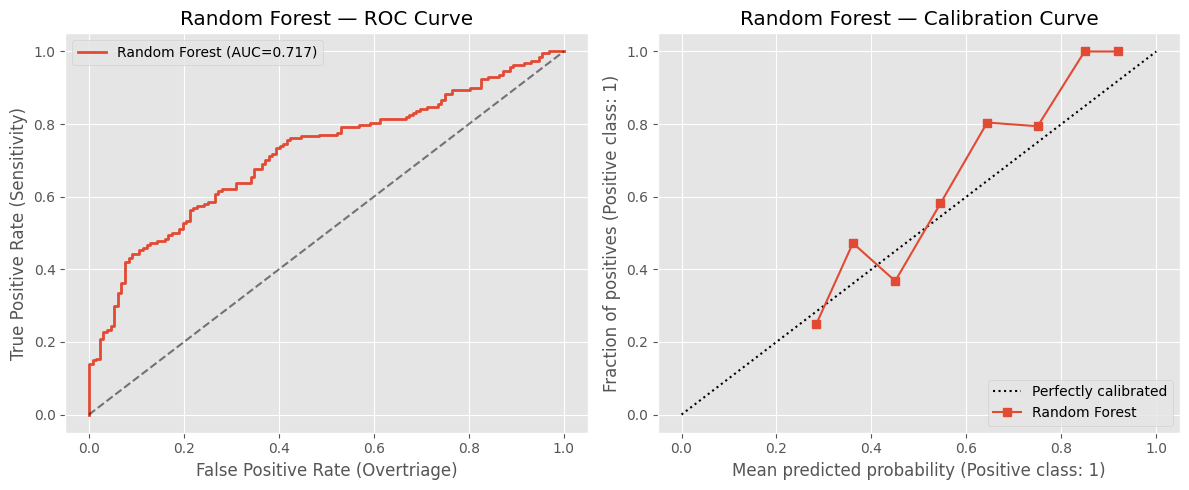

In [45]:
rf_param_dist = {
    'n_estimators': randint(100, 1000),
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
    'bootstrap': [True, False],
}

print("\n=== RANDOM FOREST — HYPERPARAMETER TUNING ===")
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=100,
    scoring='roc_auc',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
rf_search.fit(X_cc_train[enc_primary], y_cc_train)

print(f"\nBest params: {rf_search.best_params_}")
print(f"Best CV AUC: {rf_search.best_score_:.4f}")

rf_best = rf_search.best_estimator_

# Full evaluation
rf_results = full_model_evaluation(
    rf_best, X_cc_train, y_cc_train,
    X_cc_test, y_cc_test,
    enc_primary, 'Random Forest', cv
)

### 14.5 XGBoost 

Full dataset — XGBoost handles NaN natively.
XGBoost tuned via Optuna (TPE sampler), 100 trials.
Evaluated on full test set (n=367), unlike LR/RF (n≈325).


=== XGBOOST — OPTUNA TUNING (100 trials) ===


Best trial: 92. Best value: 0.659213: 100%|██████████| 100/100 [00:14<00:00,  7.06it/s]



Best CV AUC: 0.6592
Best params: {'n_estimators': 501, 'max_depth': 5, 'learning_rate': 0.13486634205449252, 'subsample': 0.9427117928080736, 'colsample_bytree': 0.9489630047817444, 'min_child_weight': 10, 'gamma': 2.504820296285549, 'reg_alpha': 5.640099991801537, 'reg_lambda': 0.00018191938665975145}

  XGBoost

CV AUC: 0.6592 ± 0.0327
  Per fold: [0.6239 0.7037 0.6931 0.6334 0.6419]

Test AUC:    0.6835
Brier score: 0.2190

ACS-COT threshold selection (CV):
  CV thresholds per fold: [np.float64(0.4154), np.float64(0.429), np.float64(0.4241), np.float64(0.3519), np.float64(0.3927)]
  Median threshold: 0.4154

--- XGBoost — threshold 0.5 (threshold=0.5000) ---
  Sensitivity:      0.652  (target ≥0.95)
  Specificity:      0.590
  Undertriage rate: 0.348  (target <0.05)
  Overtriage rate:  0.410  (target 0.25-0.35)
  PPV:              0.665
  NPV:              0.576
  TP=131 FP=66 FN=70 TN=95

--- XGBoost — ACS-COT threshold (threshold=0.4154) ---
  Sensitivity:      0.940  (target ≥0.

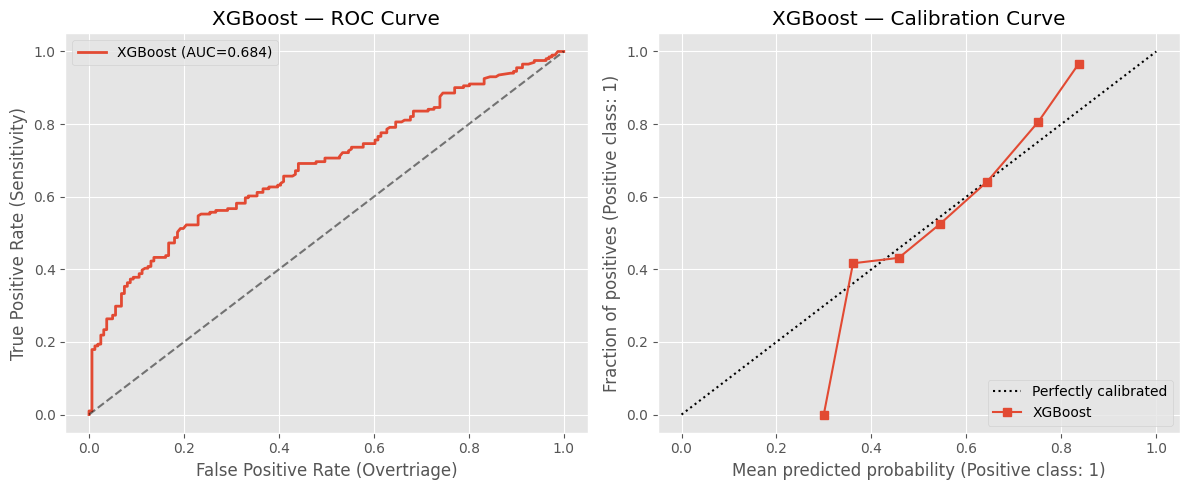

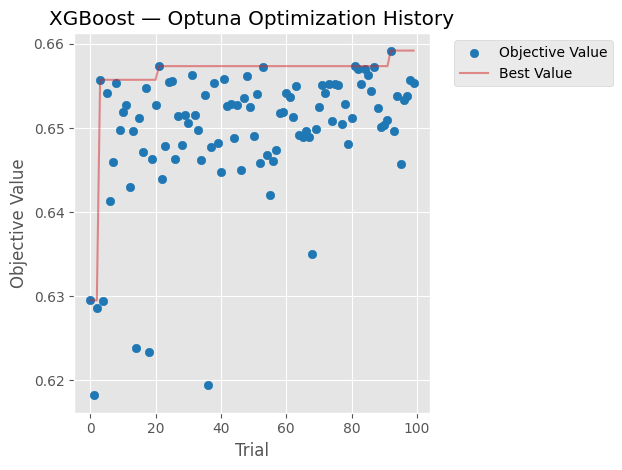

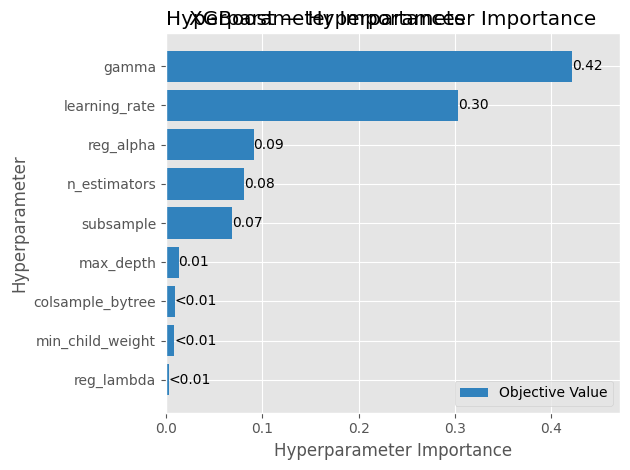

In [ ]:
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': RANDOM_STATE,
        'eval_metric': 'auc',
    }
    model = XGBClassifier(**params)
    scores = cross_val_score(
        model, X_xgb_train[enc_primary], y_xgb_train,
        cv=cv, scoring='roc_auc', n_jobs=-1
    )
    return scores.mean()

print("\n=== XGBOOST — OPTUNA TUNING (100 trials) ===")
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(xgb_objective, n_trials=100, show_progress_bar=True)

print(f"\nBest CV AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

xgb_best = XGBClassifier(
    **study.best_params,
    random_state=RANDOM_STATE,
    eval_metric='auc',
)

# Full evaluation — note: uses full dataset, not complete cases
xgb_results = full_model_evaluation(
    xgb_best, X_xgb_train, y_xgb_train,
    X_xgb_test, y_xgb_test,
    enc_primary, 'XGBoost', cv
)

# Optuna visualizations
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title('XGBoost — Optuna Optimization History')
plt.tight_layout()
plt.show()

optuna.visualization.matplotlib.plot_param_importances(study)
plt.title('XGBoost — Parameter Importance')
plt.tight_layout()
plt.show()

### 14.6 Model comparison

Head-to-head comparison of all three Primary (assessment only)models on the same test set. Note: LR and RF are evaluated on complete cases (n=325), XGBoost on the full test set (n=367).

#### 14.6a ROC overlay

Overlaid ROC curves with ACS-COT overtriage target zone (25–35% FPR). Calibration curves show predicted vs observed probability alignment.

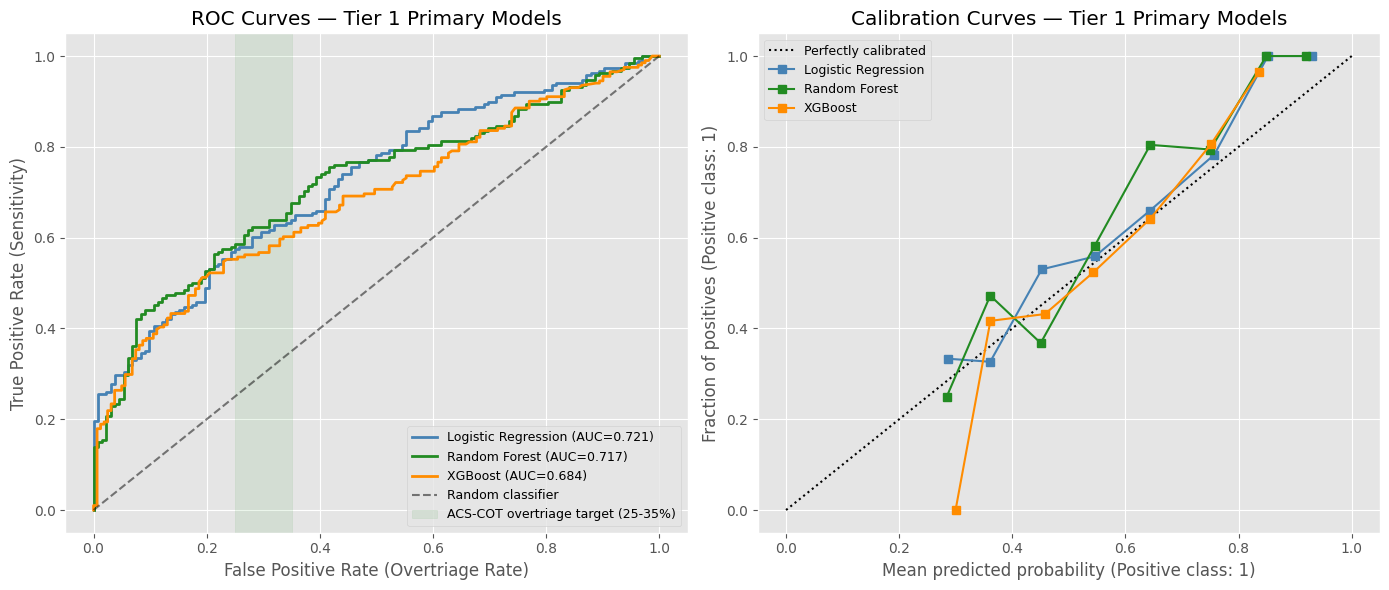

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_results = {
    'Logistic Regression': (lr_results, 'steelblue'),
    'Random Forest': (rf_results, 'forestgreen'),
    'XGBoost': (xgb_results, 'darkorange'),
}

for name, (res, color) in model_results.items():
    axes[0].plot(
        res['fpr'], res['tpr'],
        label=f"{name} (AUC={res['test_auc']:.3f})",
        color=color, lw=2
    )

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random classifier')
axes[0].axvspan(0.25, 0.35, alpha=0.08, color='green',
                label='ACS-COT overtriage target (25-35%)')
axes[0].set_xlabel('False Positive Rate (Overtriage Rate)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('ROC Curves — Tier 1 Primary Models')
axes[0].legend(fontsize=9)

# Calibration overlay
for name, (res, color) in model_results.items():
    y_true = y_cc_test if name != 'XGBoost' else y_xgb_test
    CalibrationDisplay.from_predictions(
        y_true, res['y_prob'], n_bins=10,
        ax=axes[1], name=name, color=color
    )
axes[1].set_title('Calibration Curves — Tier 1 Primary Models')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

#### 14.6b Performance summary table

Training and test set sizes, cross-validation AUC with standard deviation, test AUC, and Brier score for calibration.

In [48]:
print("\n=== MODEL COMPARISON SUMMARY (Primary predictor set) ===")
summary_data = []
for name, (res, _) in model_results.items():
    n_test = len(y_cc_test) if name != 'XGBoost' else len(y_xgb_test)
    n_train = len(X_cc_train) if name != 'XGBoost' else len(X_xgb_train)
    summary_data.append({
        'Model': name,
        'N train': n_train,
        'N test': n_test,
        'CV AUC': f"{res['cv_auc_mean']:.4f} ± {res['cv_auc_std']:.4f}",
        'Test AUC': round(res['test_auc'], 4),
        'Brier': round(res['brier'], 4),
    })

summary_df = pd.DataFrame(summary_data).set_index('Model')
print(summary_df.to_string())


=== MODEL COMPARISON SUMMARY (Primary predictor set) ===
                     N train  N test           CV AUC  Test AUC   Brier
Model                                                                  
Logistic Regression     1296     320  0.6687 ± 0.0294    0.7208  0.2078
Random Forest           1296     320  0.6755 ± 0.0448    0.7165  0.2106
XGBoost                 1447     362  0.6592 ± 0.0327    0.6835  0.2190


#### 14.6c Threshold comparison tables

Performance at the default 0.5 threshold and the CV-selected ACS-COT threshold. ACS-COT targets: ≥95% sensitivity with 25–35% overtriage.

In [49]:
print("\n=== THRESHOLD COMPARISON — 0.5 ===")
rows_05 = []
for name, (res, _) in model_results.items():
    r = res['results_05']
    rows_05.append({
        'Model': name,
        'Sensitivity': round(r['sensitivity'], 3),
        'Specificity': round(r['specificity'], 3),
        'Undertriage': round(r['undertriage'], 3),
        'Overtriage': round(r['overtriage'], 3),
        'PPV': round(r['ppv'], 3),
        'NPV': round(r['npv'], 3),
    })
print(pd.DataFrame(rows_05).set_index('Model').to_string())

print("\n=== THRESHOLD COMPARISON — ACS-COT (CV-selected) ===")
rows_acs = []
for name, (res, _) in model_results.items():
    r = res['results_acs']
    rows_acs.append({
        'Model': name,
        'Threshold': round(res['acs_threshold'], 4),
        'Sensitivity': round(r['sensitivity'], 3),
        'Specificity': round(r['specificity'], 3),
        'Undertriage': round(r['undertriage'], 3),
        'Overtriage': round(r['overtriage'], 3),
        'PPV': round(r['ppv'], 3),
        'NPV': round(r['npv'], 3),
    })
print(pd.DataFrame(rows_acs).set_index('Model').to_string())


=== THRESHOLD COMPARISON — 0.5 ===
                     Sensitivity  Specificity  Undertriage  Overtriage    PPV    NPV
Model                                                                               
Logistic Regression        0.665        0.591        0.335       0.409  0.698  0.553
Random Forest              0.729        0.606        0.271       0.394  0.725  0.611
XGBoost                    0.652        0.590        0.348       0.410  0.665  0.576

=== THRESHOLD COMPARISON — ACS-COT (CV-selected) ===
                     Threshold  Sensitivity  Specificity  Undertriage  Overtriage    PPV    NPV
Model                                                                                          
Logistic Regression     0.3714        0.936        0.182        0.064       0.818  0.620  0.667
Random Forest           0.3570        0.963        0.106        0.037       0.894  0.605  0.667
XGBoost                 0.4154        0.940        0.106        0.060       0.894  0.568  0.586


### 14.7 SHAP feature importance 

SHAP for RF and XGBoost on their respective test sets.
LR uses coefficients (section 15.3b) — SHAP not needed.

#### 14.7a RF SHAP

SHAP (SHapley Additive exPlanations) values computed via TreeExplainer on the RF test set. Beeswarm plot shows per-feature impact direction and magnitude; bar chart shows mean absolute SHAP for ranking.

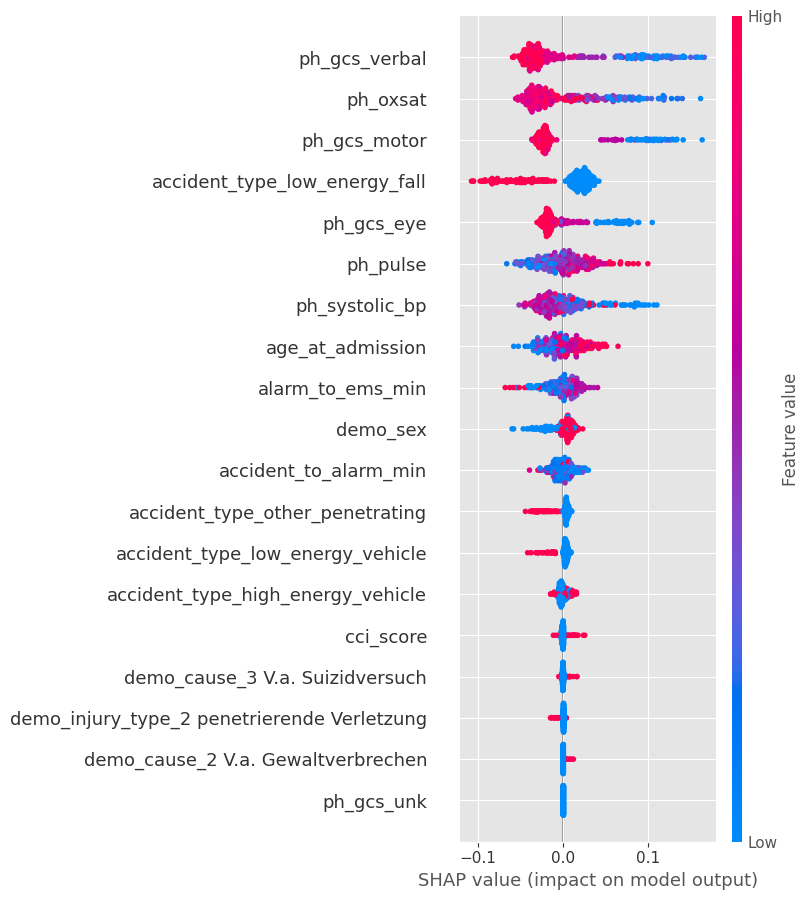

<Figure size 640x480 with 0 Axes>


RF — Top features by mean |SHAP|:
                                    feature  mean_abs_shap
                              ph_gcs_verbal       0.047191
                                   ph_oxsat       0.036451
                               ph_gcs_motor       0.036137
              accident_type_low_energy_fall       0.030809
                                 ph_gcs_eye       0.023565
                                   ph_pulse       0.021456
                             ph_systolic_bp       0.021155
                           age_at_admission       0.016304
                           alarm_to_ems_min       0.011924
                                   demo_sex       0.009522
                      accident_to_alarm_min       0.008435
            accident_type_other_penetrating       0.007305
           accident_type_low_energy_vehicle       0.004740
          accident_type_high_energy_vehicle       0.003846
                                  cci_score       0.001538
            demo_caus

In [50]:
explainer_rf = shap.TreeExplainer(rf_results['model'])
shap_values_rf = explainer_rf.shap_values(X_cc_test[enc_primary])

# Handle 3D array (binary classification)
if isinstance(shap_values_rf, np.ndarray) and shap_values_rf.ndim == 3:
    shap_vals_rf = shap_values_rf[:, :, 1]
elif isinstance(shap_values_rf, list):
    shap_vals_rf = shap_values_rf[1]
else:
    shap_vals_rf = shap_values_rf

shap.summary_plot(shap_vals_rf, X_cc_test[enc_primary], max_display=21, show=True)
plt.tight_layout()
plt.show()

mean_shap_rf = pd.DataFrame({
    'feature': enc_primary,
    'mean_abs_shap': np.abs(shap_vals_rf).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("\nRF — Top features by mean |SHAP|:")
print(mean_shap_rf.to_string(index=False))

#### 14.7b XGBoost SHAP

Same SHAP analysis for XGBoost. Computed on the full test set (n=367) as XGBoost handles NaN natively.

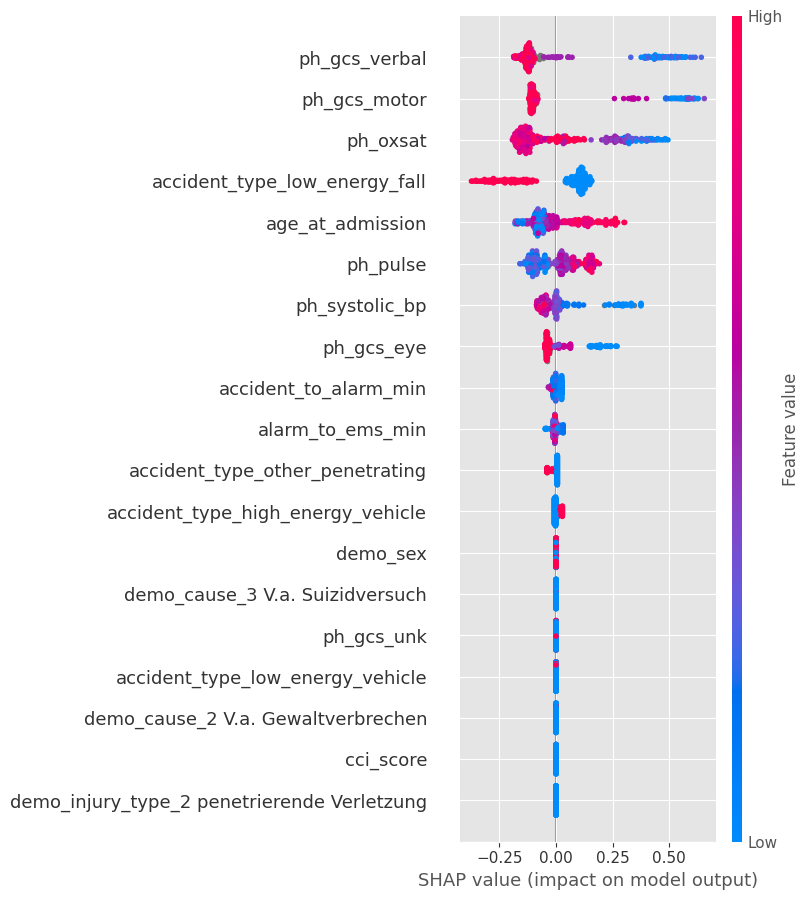

<Figure size 640x480 with 0 Axes>


XGBoost — Top features by mean |SHAP|:
                                    feature  mean_abs_shap
                              ph_gcs_verbal       0.190316
                               ph_gcs_motor       0.169968
                                   ph_oxsat       0.167154
              accident_type_low_energy_fall       0.138104
                           age_at_admission       0.086702
                                   ph_pulse       0.080585
                             ph_systolic_bp       0.060452
                                 ph_gcs_eye       0.056591
                      accident_to_alarm_min       0.011239
                           alarm_to_ems_min       0.009435
            accident_type_other_penetrating       0.009352
          accident_type_high_energy_vehicle       0.005622
                                  cci_score       0.000000
                                 ph_gcs_unk       0.000000
                                   demo_sex       0.000000
           accid

In [51]:
explainer_xgb = shap.TreeExplainer(xgb_results['model'])
shap_values_xgb = explainer_xgb.shap_values(X_xgb_test[enc_primary])

if isinstance(shap_values_xgb, np.ndarray) and shap_values_xgb.ndim == 3:
    shap_vals_xgb = shap_values_xgb[:, :, 1]
else:
    shap_vals_xgb = shap_values_xgb

shap.summary_plot(shap_vals_xgb, X_xgb_test[enc_primary], max_display=21, show=True)
plt.tight_layout()
plt.show()

mean_shap_xgb = pd.DataFrame({
    'feature': enc_primary,
    'mean_abs_shap': np.abs(shap_vals_xgb).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("\nXGBoost — Top features by mean |SHAP|:")
print(mean_shap_xgb.to_string(index=False))

#### 14.7c SHAP comparison plot

Side-by-side mean |SHAP| bar charts for RF and XGBoost. Consistent feature rankings across models support the robustness of identified predictor importance.

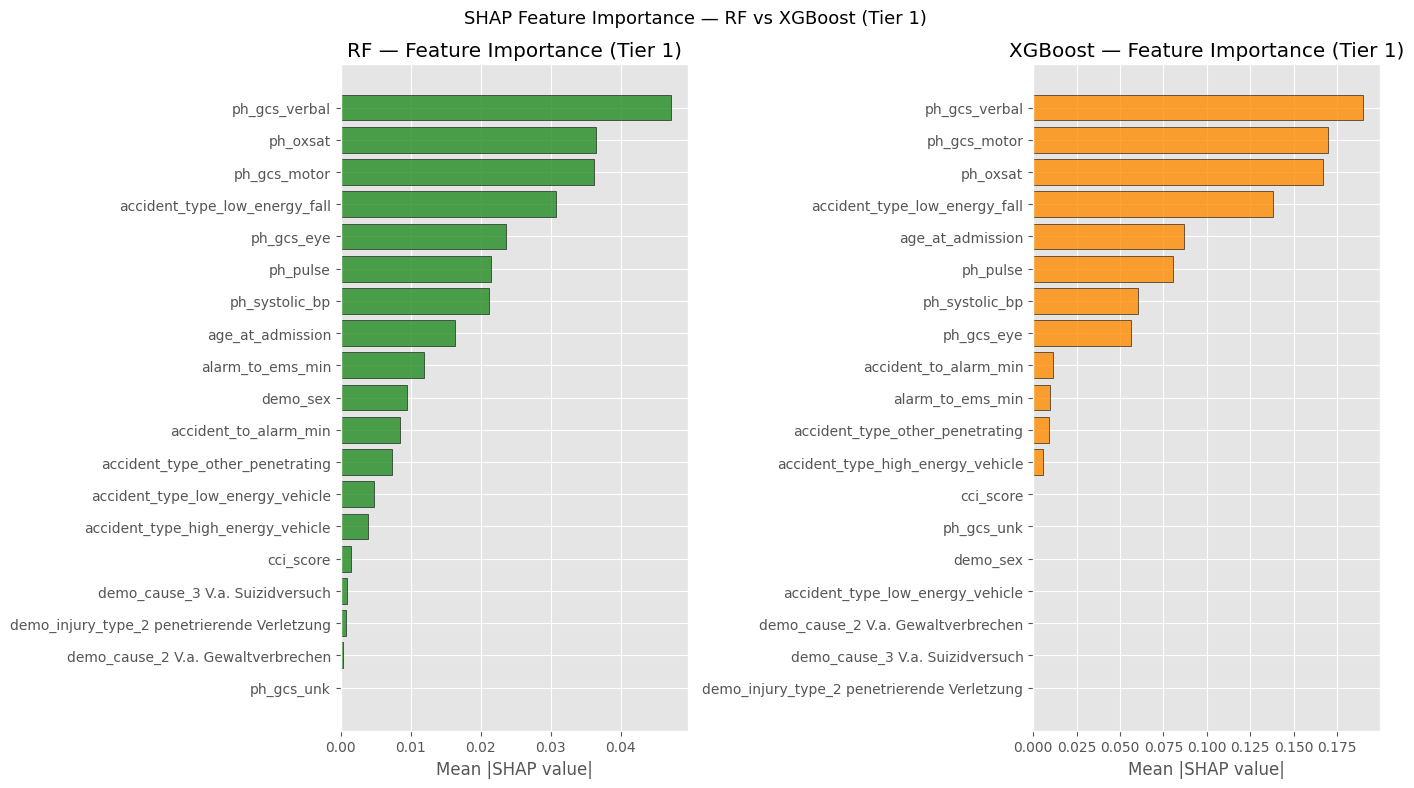

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

axes[0].barh(mean_shap_rf['feature'], mean_shap_rf['mean_abs_shap'],
             color='forestgreen', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('RF — Feature Importance (Tier 1)')
axes[0].invert_yaxis()

axes[1].barh(mean_shap_xgb['feature'], mean_shap_xgb['mean_abs_shap'],
             color='darkorange', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Mean |SHAP value|')
axes[1].set_title('XGBoost — Feature Importance (Tier 1)')
axes[1].invert_yaxis()

plt.suptitle('SHAP Feature Importance — RF vs XGBoost (Tier 1)', fontsize=13)
plt.tight_layout()
plt.show()

### 14.8 Section summary

Consolidated summary of primary model performance, ACS-COT assessment, and key SHAP findings.

In [53]:
print(f"\nPrimary predictor set: {len(enc_primary)} post-encoding parameters")
print(f"\nLR + RF: complete cases (train n={len(X_cc_train)}, test n={len(X_cc_test)})")
print(f"XGBoost: full dataset (train n={len(X_xgb_train)}, test n={len(X_xgb_test)})")
print(f"\nModel performance:")
for name, (res, _) in model_results.items():
    print(f"  {name}: CV AUC {res['cv_auc_mean']:.4f} ± {res['cv_auc_std']:.4f}, "
          f"Test AUC {res['test_auc']:.4f}, Brier {res['brier']:.4f}")


Primary predictor set: 19 post-encoding parameters

LR + RF: complete cases (train n=1296, test n=320)
XGBoost: full dataset (train n=1447, test n=362)

Model performance:
  Logistic Regression: CV AUC 0.6687 ± 0.0294, Test AUC 0.7208, Brier 0.2078
  Random Forest: CV AUC 0.6755 ± 0.0448, Test AUC 0.7165, Brier 0.2106
  XGBoost: CV AUC 0.6592 ± 0.0327, Test AUC 0.6835, Brier 0.2190


## 15. STB Rule-Based Comparator

Swiss Trauma Board 2017 prehospital triage criteria applied as a clinical benchmark. Partial implementation using available prehospital variables:
   - Mechanism criteria: stb_mechanism_met flag (from section 7.11)
  - Vital sign criteria: SBP < 90 mmHg, GCS total < 9

**GCS IMPLEMENTATION NOTE:**
The STB vital sign criterion is GCS < 9 (total score). GCS total is used here directly from ph_gcs_total. Although GCS total was excluded from the  ML predictor sets due to collinearity with its components (VIF = 122.8), collinearity is irrelevant for a rule-based threshold classifier that does not fit any coefficients. Using GCS total < 9 directly operationalises the stated STB criterion without proxy assumptions.

**MECHANISM NOTE:**
The stb_mechanism_met flag (section 7.11) includes all motorised vehicle occupant collisions as mechanism-positive. The actual STB criteria specify particular MVC sub-criteria (frontal intrusion > 50–75 cm, velocity change Δv > 30 km/h, pedestrian/cyclist collision, occupant ejection, co-occupant death) that are not captured in STR accident type fields. Pedestrian and cyclist collisions ARE coded exactly in STR and are correctly included.
All other MVC occupant categories are over-inclusive — this likely overstates mechanism sensitivity and should be acknowledged as a limitation.

**CRITERIA NOT IMPLEMENTED:**
   - Injury-based criteria (unstable fractures, open injuries, amputation, neurological deficit, penetrating trunk/neck): not recorded as prehospital fields in LUKS data; only available as post-imaging in-hospital diagnoses.
   - Prehospital intubation: a post-T0 Notarzt intervention, not an assessment finding available to guide the original dispatch decision.
   - S3 guideline criteria (HR > 120, SpO₂ < 90%, shock index > 0.9, eFAST): absent from STB prehospital dispatch criteria; not implemented.
  
The STB classifier is a fixed rule with no training or threshold tuning. It produces a binary decision: "meets STB criteria" → send to trauma centre.


=== STB CRITERIA COMPONENTS (test set) ===

stb_mechanism_met:
stb_mechanism_met
True     212
False    147
<NA>       3
Name: count, dtype: Int64

SBP < 90 mmHg:
  14 patients

GCS total < 9:
  56 patients
  (missing / unassessable: 39 patients)

=== STB CLASSIFICATION (test set, n=362) ===
STB positive (send to trauma centre): 236
STB negative (local hospital):        126

Criteria breakdown (patients may meet multiple):
  Mechanism:    212
  SBP < 90:     14
  GCS total < 9: 56

=== STB PERFORMANCE (full test set, n=362) ===
  Sensitivity:      0.701
  Specificity:      0.410
  PPV:              0.597
  NPV:              0.524
  Undertriage rate: 0.299
  Overtriage rate:  0.590
  TP=141 FP=95 FN=60 TN=66

=== STB PERFORMANCE (complete cases, n=320) ===
  Sensitivity:      0.707
  Specificity:      0.409
  Undertriage rate: 0.293
  Overtriage rate:  0.591
  TP=133 FP=78 FN=55 TN=54

=== COMPARISON 1: STB vs ML AT DEFAULT THRESHOLD ===
                                     N test  Sensi

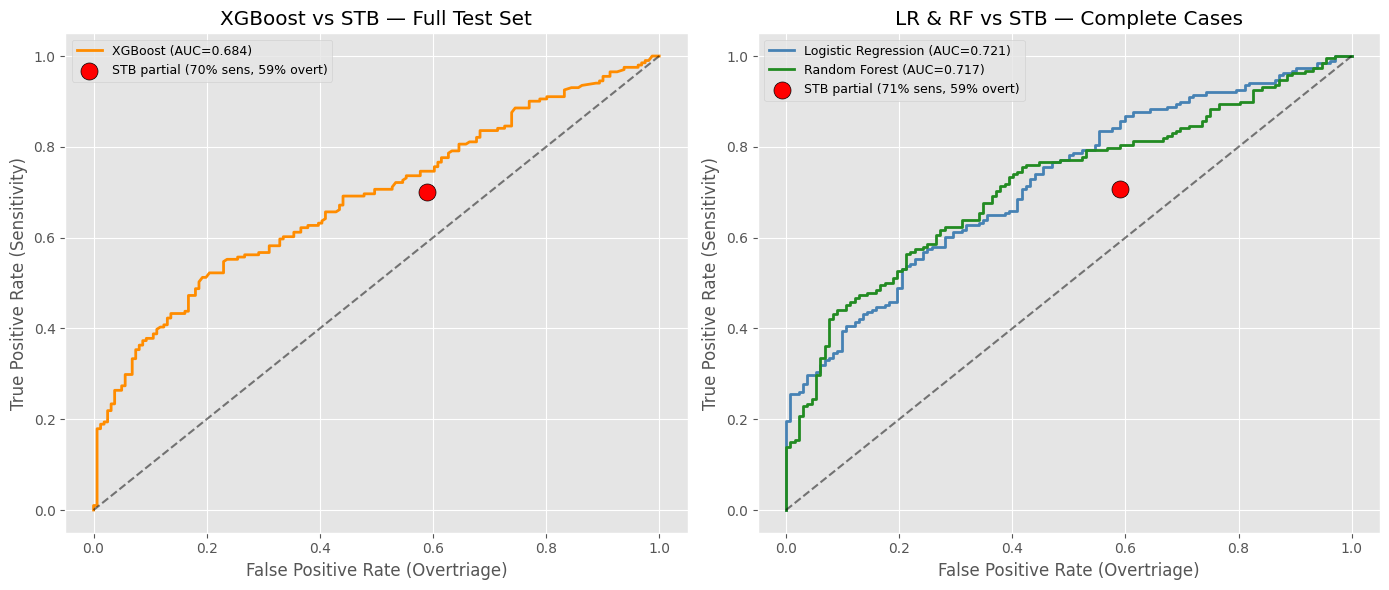


=== COMPARISON 3: ML AT MATCHED STB SENSITIVITY ===
STB sensitivity (full test): 0.701

XGBoost at matched sensitivity:
  Threshold: 0.4833
  Sensitivity: 0.697 (target: 0.701)
  Overtriage:  0.478 (STB: 0.590)
  Overtriage reduction: 0.112 (18.9%)

--- XGBoost — matched STB sensitivity (threshold=0.4833) ---
  Sensitivity:      0.697  (target ≥0.95)
  Specificity:      0.522
  Undertriage rate: 0.303  (target <0.05)
  Overtriage rate:  0.478  (target 0.25-0.35)
  PPV:              0.645
  NPV:              0.579
  TP=140 FP=77 FN=61 TN=84

Logistic Regression at matched STB sensitivity (0.707):
  Threshold: 0.4948
  Overtriage: 0.417 (STB: 0.591)

--- Logistic Regression — matched STB sensitivity (threshold=0.4948) ---
  Sensitivity:      0.707  (target ≥0.95)
  Specificity:      0.583
  Undertriage rate: 0.293  (target <0.05)
  Overtriage rate:  0.417  (target 0.25-0.35)
  PPV:              0.707
  NPV:              0.583
  TP=133 FP=55 FN=55 TN=77

Random Forest at matched STB sens

In [ ]:
# ── 15.1 Apply STB criteria to test set ──────────────────────────────────────

# Retrieve STB flag and unscaled vitals from df_test (unencoded)
df_stb_test = df_test[['unique_id', 'stb_mechanism_met']].copy()

# GCS total: use directly from unencoded df_test
# (VIF exclusion applies to ML models only, not to rule-based threshold)
df_stb_test['gcs_total'] = pd.to_numeric(df_test['ph_gcs_total'], errors='coerce')

# SBP from unencoded df_test (not scaled)
df_stb_test['sbp'] = pd.to_numeric(df_test['ph_systolic_bp'], errors='coerce')

# ISS outcome
df_stb_test['y_true'] = y_test.values

print("=== STB CRITERIA COMPONENTS (test set) ===")
print(f"\nstb_mechanism_met:")
print(df_stb_test['stb_mechanism_met'].value_counts(dropna=False))
print(f"\nSBP < 90 mmHg:")
print(f"  {(df_stb_test['sbp'] < 90).sum()} patients")
print(f"\nGCS total < 9:")
print(f"  {(df_stb_test['gcs_total'] < 9).sum()} patients")
print(f"  (missing / unassessable: {df_stb_test['gcs_total'].isna().sum()} patients)")


# ── 15.2 Build STB classifier ────────────────────────────────────────────────
# STB positive = ANY criterion met
# STB negative = NO criterion met (or all criteria missing → conservative)
# Missing GCS or SBP treated as criterion NOT met (conservative; avoids
# inflating sensitivity from unmeasured patients).

df_stb_test['stb_mechanism'] = df_stb_test['stb_mechanism_met'].fillna(False).astype(bool)
df_stb_test['stb_sbp'] = df_stb_test['sbp'] < 90
df_stb_test['stb_gcs'] = df_stb_test['gcs_total'] < 9

# Combined rule: positive if ANY criterion met
# Missing vital signs filled as False (criterion not met)
df_stb_test['stb_positive'] = (
    df_stb_test['stb_mechanism'] |
    df_stb_test['stb_sbp'].fillna(False) |
    df_stb_test['stb_gcs'].fillna(False)
)

print(f"\n=== STB CLASSIFICATION (test set, n={len(df_stb_test)}) ===")
print(f"STB positive (send to trauma centre): {df_stb_test['stb_positive'].sum()}")
print(f"STB negative (local hospital):        {(~df_stb_test['stb_positive']).sum()}")
print(f"\nCriteria breakdown (patients may meet multiple):")
print(f"  Mechanism:    {df_stb_test['stb_mechanism'].sum()}")
print(f"  SBP < 90:     {df_stb_test['stb_sbp'].fillna(False).sum()}")
print(f"  GCS total < 9: {df_stb_test['stb_gcs'].fillna(False).sum()}")


# ── 15.3 STB performance on full test set ─────────────────────────────────────

y_stb_pred = df_stb_test['stb_positive'].astype(int).values
y_stb_true = df_stb_test['y_true'].values

tn, fp, fn, tp = confusion_matrix(y_stb_true, y_stb_pred).ravel()
stb_sensitivity = tp / (tp + fn)
stb_specificity = tn / (tn + fp)
stb_ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
stb_npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan
stb_undertriage = fn / (tp + fn)
stb_overtriage = fp / (tn + fp)

print(f"\n=== STB PERFORMANCE (full test set, n={len(y_stb_true)}) ===")
print(f"  Sensitivity:      {stb_sensitivity:.3f}")
print(f"  Specificity:      {stb_specificity:.3f}")
print(f"  PPV:              {stb_ppv:.3f}")
print(f"  NPV:              {stb_npv:.3f}")
print(f"  Undertriage rate: {stb_undertriage:.3f}")
print(f"  Overtriage rate:  {stb_overtriage:.3f}")
print(f"  TP={tp} FP={fp} FN={fn} TN={tn}")

stb_results = {
    'sensitivity': stb_sensitivity,
    'specificity': stb_specificity,
    'ppv': stb_ppv,
    'npv': stb_npv,
    'undertriage': stb_undertriage,
    'overtriage': stb_overtriage,
    'fpr': stb_overtriage,  # FPR = overtriage for ROC plotting
    'tpr': stb_sensitivity,  # TPR = sensitivity for ROC plotting
}


# ── 15.4 STB on complete case test set (for LR/RF comparison) ─────────────────

# Apply same complete case mask used for LR and RF
df_stb_cc = df_stb_test[cc_test_mask.values].reset_index(drop=True)

y_stb_cc_pred = df_stb_cc['stb_positive'].astype(int).values
y_stb_cc_true = df_stb_cc['y_true'].values

tn_cc, fp_cc, fn_cc, tp_cc = confusion_matrix(y_stb_cc_true, y_stb_cc_pred).ravel()
stb_cc_sensitivity = tp_cc / (tp_cc + fn_cc)
stb_cc_specificity = tn_cc / (tn_cc + fp_cc)
stb_cc_undertriage = fn_cc / (tp_cc + fn_cc)
stb_cc_overtriage = fp_cc / (tn_cc + fp_cc)

print(f"\n=== STB PERFORMANCE (complete cases, n={len(y_stb_cc_true)}) ===")
print(f"  Sensitivity:      {stb_cc_sensitivity:.3f}")
print(f"  Specificity:      {stb_cc_specificity:.3f}")
print(f"  Undertriage rate: {stb_cc_undertriage:.3f}")
print(f"  Overtriage rate:  {stb_cc_overtriage:.3f}")
print(f"  TP={tp_cc} FP={fp_cc} FN={fn_cc} TN={tn_cc}")

stb_cc_results = {
    'sensitivity': stb_cc_sensitivity,
    'specificity': stb_cc_specificity,
    'undertriage': stb_cc_undertriage,
    'overtriage': stb_cc_overtriage,
    'fpr': stb_cc_overtriage,
    'tpr': stb_cc_sensitivity,
}


# ── 15.5 Comparison 1: STB vs ML models at default threshold (0.5) ──────────

print("\n=== COMPARISON 1: STB vs ML AT DEFAULT THRESHOLD ===")
comp1_rows = []

# STB on full test set
comp1_rows.append({
    'Model': 'STB (partial, full test)',
    'N test': len(y_stb_true),
    'Sensitivity': round(stb_sensitivity, 3),
    'Specificity': round(stb_specificity, 3),
    'Undertriage': round(stb_undertriage, 3),
    'Overtriage': round(stb_overtriage, 3),
    'PPV': round(stb_ppv, 3),
    'NPV': round(stb_npv, 3),
})

# STB on complete cases (for LR/RF comparison)
comp1_rows.append({
    'Model': 'STB (partial, complete cases)',
    'N test': len(y_stb_cc_true),
    'Sensitivity': round(stb_cc_sensitivity, 3),
    'Specificity': round(stb_cc_specificity, 3),
    'Undertriage': round(stb_cc_undertriage, 3),
    'Overtriage': round(stb_cc_overtriage, 3),
    'PPV': round(tp_cc / (tp_cc + fp_cc), 3),
    'NPV': round(tn_cc / (tn_cc + fn_cc), 3),
})

# ML models at 0.5
for name, (res, _) in model_results.items():
    r = res['results_05']
    n = len(y_cc_test) if name != 'XGBoost' else len(y_xgb_test)
    comp1_rows.append({
        'Model': f'{name} (threshold 0.5)',
        'N test': n,
        'Sensitivity': round(r['sensitivity'], 3),
        'Specificity': round(r['specificity'], 3),
        'Undertriage': round(r['undertriage'], 3),
        'Overtriage': round(r['overtriage'], 3),
        'PPV': round(r['ppv'], 3),
        'NPV': round(r['npv'], 3),
    })

comp1_df = pd.DataFrame(comp1_rows).set_index('Model')
print(comp1_df.to_string())


# ── 15.6 Comparison 2: STB vs ML models on ROC curves ────────────────────────
# Plot STB operating point as a dot on the ML ROC curves.
# If the ROC curve passes above the STB point, the ML model can achieve
# the same sensitivity with less overtriage.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: full test set (XGBoost vs STB)
xgb_fpr, xgb_tpr = xgb_results['fpr'], xgb_results['tpr']
axes[0].plot(xgb_fpr, xgb_tpr,
             label=f"XGBoost (AUC={xgb_results['test_auc']:.3f})",
             color='darkorange', lw=2)
axes[0].scatter(stb_results['fpr'], stb_results['tpr'],
                color='red', s=150, zorder=5, edgecolors='black',
                label=f"STB partial ({stb_sensitivity:.0%} sens, "
                      f"{stb_overtriage:.0%} overt)")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate (Overtriage)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('XGBoost vs STB — Full Test Set')
axes[0].legend(fontsize=9)

# Right: complete cases (LR and RF vs STB)
for name, (res, color) in model_results.items():
    if name == 'XGBoost':
        continue  # shown on left panel
    axes[1].plot(res['fpr'], res['tpr'],
                 label=f"{name} (AUC={res['test_auc']:.3f})",
                 color=color, lw=2)
axes[1].scatter(stb_cc_results['fpr'], stb_cc_results['tpr'],
                color='red', s=150, zorder=5, edgecolors='black',
                label=f"STB partial ({stb_cc_sensitivity:.0%} sens, "
                      f"{stb_cc_overtriage:.0%} overt)")
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate (Overtriage)')
axes[1].set_ylabel('True Positive Rate (Sensitivity)')
axes[1].set_title('LR & RF vs STB — Complete Cases')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


# ── 15.7 Comparison 3: ML at matched STB sensitivity ─────────────────────────
# Find the ML threshold that gives the same sensitivity as STB,
# then compare overtriage rates. This is the fairest comparison:
# "given the same undertriage rate, how much does ML reduce overtriage?"

print(f"\n=== COMPARISON 3: ML AT MATCHED STB SENSITIVITY ===")
print(f"STB sensitivity (full test): {stb_sensitivity:.3f}")

# XGBoost: find threshold matching STB sensitivity
xgb_fpr_full, xgb_tpr_full, xgb_thresh_full = roc_curve(y_xgb_test, xgb_results['y_prob'])

idx_match = np.argmin(np.abs(xgb_tpr_full - stb_sensitivity))
matched_threshold = xgb_thresh_full[idx_match]
matched_fpr = xgb_fpr_full[idx_match]
matched_tpr = xgb_tpr_full[idx_match]

print(f"\nXGBoost at matched sensitivity:")
print(f"  Threshold: {matched_threshold:.4f}")
print(f"  Sensitivity: {matched_tpr:.3f} (target: {stb_sensitivity:.3f})")
print(f"  Overtriage:  {matched_fpr:.3f} (STB: {stb_overtriage:.3f})")
print(f"  Overtriage reduction: {stb_overtriage - matched_fpr:.3f} "
      f"({(stb_overtriage - matched_fpr)/stb_overtriage*100:.1f}%)")

xgb_matched = evaluate_at_threshold(
    y_xgb_test, xgb_results['y_prob'],
    matched_threshold, 'XGBoost — matched STB sensitivity'
)

# LR and RF on complete cases
for name, (res, _) in model_results.items():
    if name == 'XGBoost':
        continue
    y_true = y_cc_test
    y_prob = res['y_prob']
    fpr_m, tpr_m, thresh_m = roc_curve(y_true, y_prob)
    idx = np.argmin(np.abs(tpr_m - stb_cc_sensitivity))
    mt = thresh_m[idx]
    print(f"\n{name} at matched STB sensitivity ({stb_cc_sensitivity:.3f}):")
    print(f"  Threshold: {mt:.4f}")
    print(f"  Overtriage: {fpr_m[idx]:.3f} (STB: {stb_cc_overtriage:.3f})")
    evaluate_at_threshold(y_true, y_prob, mt,
                          f'{name} — matched STB sensitivity')


# ── 15.8 STB mechanism as single-predictor AUC ───────────────────────────────

stb_mechanism_auc = roc_auc_score(
    y_test,
    df_test['stb_mechanism_met'].fillna(False).astype(int)
)
print(f"\n=== STB MECHANISM ALONE (single-predictor AUC) ===")
print(f"STB mechanism alone AUC: {stb_mechanism_auc:.4f}")
print(f"XGBoost Tier 1 AUC:     {xgb_results['test_auc']:.4f}")
print(f"ΔAUC (ML vs STB rule):  {xgb_results['test_auc'] - stb_mechanism_auc:+.4f}")

In [ ]:
# STB mechanism as single predictor — AUC on full test set
stb_pred = df_test['stb_mechanism_met'].fillna(False).astype(int)
stb_auc = roc_auc_score(y_test, stb_pred)
print(f"STB mechanism alone AUC: {stb_auc:.4f}")
print(f"XGBoost Primary Predictors AUC:     {xgb_results['test_auc']:.4f}")

STB mechanism alone AUC: 0.5240
XGBoost Tier 1 AUC:     0.6835


## 17. Sensitivity Analyses

Four prespecified sensitivity analyses testing robustness of primary predictor set:
- (1) predictor set progression: primary set (assessment-only), primary + EMS interventions; 
- (2) KNN imputation versus MICE; 
- (3) XGBoost class weighting (scale_pos_weight=0.83); and 
- (4) full predictor set (XGBoost only).

All SAs use the same CV framework and RANDOM_STATE as primary analysis.
AUC-ROC is the primary comparison metric for all SAs.

  SA1 — PREDICTOR SET PROGRESSION

--- LR Predictor Set Progression ---
  Primary (assessment only) (19 cols): CV AUC=0.6687±0.0294 | Test AUC=0.7208
  Primary + interventions (25 cols): CV AUC=0.6736±0.0336 | Test AUC=0.7226

--- RF Predictor Set Progression ---
  Primary (assessment only) (19 cols): CV AUC=0.6755±0.0448 | Test AUC=0.7165
  Primary + interventions (25 cols): CV AUC=0.6759±0.0474 | Test AUC=0.7149

--- XGBoost Predictor Set Progression ---
  Primary (assessment only) (19 cols): CV AUC=0.6592±0.0327 | Test AUC=0.6835
  Primary + interventions (25 cols): CV AUC=0.6510±0.0303 | Test AUC=0.6959

=== SA1 SUMMARY ===
                               LR CV AUC  LR Test AUC      RF CV AUC  RF Test AUC     XGB CV AUC  XGB Test AUC
Predictor set                                                                                                 
Primary (assessment only)  0.6687±0.0294       0.7208  0.6755±0.0448       0.7165  0.6592±0.0327        0.6835
Primary + interventions    0.67

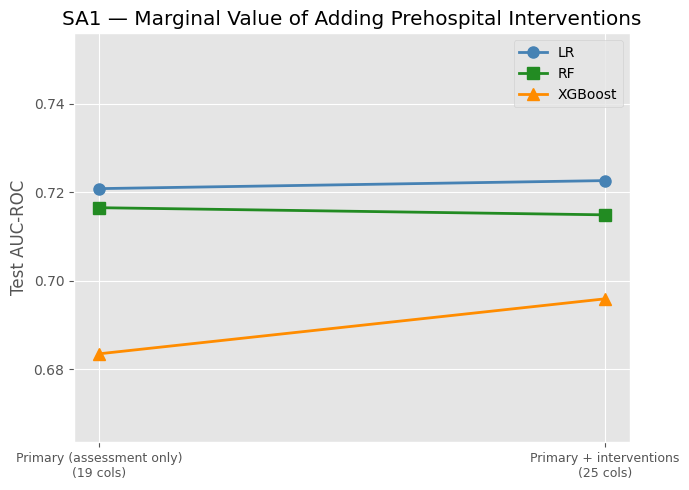


  SA2 — KNN vs MICE IMPUTATION (XGBoost)

MICE — CV AUC: 0.6592±0.0327 | Test AUC: 0.6835 | Brier: 0.2190
KNN  — CV AUC: 0.6550±0.0202 | Test AUC: 0.7058 | Brier: 0.2144
ΔAUC: 0.0223

                          CV AUC  Test AUC   Brier
Imputation                                        
MICE (primary)     0.6592±0.0327    0.6835  0.2190
KNN (sensitivity)  0.6550±0.0202    0.7058  0.2144

  SA3 — XGBOOST CLASS WEIGHTING
scale_pos_weight: 0.8042

Unweighted — CV AUC: 0.6592±0.0327 | Test AUC: 0.6835 | Brier: 0.2190
Weighted   — CV AUC: 0.6633±0.0308 | Test AUC: 0.6849 | Brier: 0.2201
ΔAUC: 0.0014

--- XGBoost Weighted — threshold 0.5 (threshold=0.5000) ---
  Sensitivity:      0.512  (target ≥0.95)
  Specificity:      0.776
  Undertriage rate: 0.488  (target <0.05)
  Overtriage rate:  0.224  (target 0.25-0.35)
  PPV:              0.741
  NPV:              0.561
  TP=103 FP=36 FN=98 TN=125

                               CV AUC  Test AUC   Brier  Sens @0.5  Spec @0.5
Model                  

In [59]:
# ── 17.1 SA1 — Predictor Set Progression ─────────────────────────────────────
# Primary set (assessment-only, enc_primary) vs
# primary + prehospital interventions (enc_sa1).
#
# Interventions include crystalloid administration, resuscitation, and
# intubation, regardless of provider type (EMS or Notarzt). These are
# available later than T0 and are tested here to assess whether knowing
# what was done improves prediction beyond what was assessed.
#
# LR: both sets evaluated (enc_sa1 = 25 params, at Riley budget ceiling)
# RF: both sets evaluated
# XGBoost: both sets evaluated
 
print("=" * 60)
print("  SA1 — PREDICTOR SET PROGRESSION")
print("=" * 60)
 
predictor_configs = {
    'Primary (assessment only)': enc_primary,
    'Primary + interventions':   enc_sa1,
}
 
# Helper: CV AUC
def quick_cv_auc(model, X_train, y_train, pred_cols, cv):
    scores = cross_val_score(
        model, X_train[pred_cols], y_train,
        cv=cv, scoring='roc_auc'
    )
    return scores.mean(), scores.std()
 
# Helper: test AUC (refits on full training set)
def quick_test_auc(model, X_train, y_train, X_test, y_test, pred_cols):
    model.fit(X_train[pred_cols], y_train)
    y_prob = model.predict_proba(X_test[pred_cols])[:, 1]
    return roc_auc_score(y_test, y_prob)
 
 
# ── LR ────────────────────────────────────────────────────────────────────────
print("\n--- LR Predictor Set Progression ---")
lr_sa1_results = {}
 
for config_name, pred_cols in predictor_configs.items():
    lr_model = LogisticRegression(
        **lr_search.best_params_,
        random_state=RANDOM_STATE
    )
    cv_mean, cv_std = quick_cv_auc(lr_model, X_cc_train, y_cc_train, pred_cols, cv)
    test_auc = quick_test_auc(lr_model, X_cc_train, y_cc_train,
                               X_cc_test, y_cc_test, pred_cols)
    lr_sa1_results[config_name] = {
        'n_cols': len(pred_cols),
        'cv_auc': cv_mean,
        'cv_std': cv_std,
        'test_auc': test_auc,
    }
    print(f"  {config_name} ({len(pred_cols)} cols): "
          f"CV AUC={cv_mean:.4f}±{cv_std:.4f} | Test AUC={test_auc:.4f}")
 
 
# ── RF ────────────────────────────────────────────────────────────────────────
print("\n--- RF Predictor Set Progression ---")
rf_sa1_results = {}
 
for config_name, pred_cols in predictor_configs.items():
    rf_model = RandomForestClassifier(
        **rf_search.best_params_,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    cv_mean, cv_std = quick_cv_auc(rf_model, X_cc_train, y_cc_train, pred_cols, cv)
    test_auc = quick_test_auc(rf_model, X_cc_train, y_cc_train,
                               X_cc_test, y_cc_test, pred_cols)
    rf_sa1_results[config_name] = {
        'n_cols': len(pred_cols),
        'cv_auc': cv_mean,
        'cv_std': cv_std,
        'test_auc': test_auc,
    }
    print(f"  {config_name} ({len(pred_cols)} cols): "
          f"CV AUC={cv_mean:.4f}±{cv_std:.4f} | Test AUC={test_auc:.4f}")
 
 
# ── XGBoost ───────────────────────────────────────────────────────────────────
print("\n--- XGBoost Predictor Set Progression ---")
xgb_sa1_results = {}
 
for config_name, pred_cols in predictor_configs.items():
    xgb_model = XGBClassifier(
        **study.best_params,
        random_state=RANDOM_STATE,
        eval_metric='auc',
    )
    cv_mean, cv_std = quick_cv_auc(xgb_model, X_xgb_train, y_xgb_train, pred_cols, cv)
    test_auc = quick_test_auc(xgb_model, X_xgb_train, y_xgb_train,
                               X_xgb_test, y_xgb_test, pred_cols)
    xgb_sa1_results[config_name] = {
        'n_cols': len(pred_cols),
        'cv_auc': cv_mean,
        'cv_std': cv_std,
        'test_auc': test_auc,
    }
    print(f"  {config_name} ({len(pred_cols)} cols): "
          f"CV AUC={cv_mean:.4f}±{cv_std:.4f} | Test AUC={test_auc:.4f}")
 
 
# ── SA1 summary table ─────────────────────────────────────────────────────────
print("\n=== SA1 SUMMARY ===")
 
sa1_rows = []
for config_name in predictor_configs.keys():
    row = {'Predictor set': config_name}
    r_lr  = lr_sa1_results[config_name]
    r_rf  = rf_sa1_results[config_name]
    r_xgb = xgb_sa1_results[config_name]
    row['LR CV AUC']   = f"{r_lr['cv_auc']:.4f}±{r_lr['cv_std']:.4f}"
    row['LR Test AUC'] = round(r_lr['test_auc'], 4)
    row['RF CV AUC']   = f"{r_rf['cv_auc']:.4f}±{r_rf['cv_std']:.4f}"
    row['RF Test AUC'] = round(r_rf['test_auc'], 4)
    row['XGB CV AUC']  = f"{r_xgb['cv_auc']:.4f}±{r_xgb['cv_std']:.4f}"
    row['XGB Test AUC']= round(r_xgb['test_auc'], 4)
    sa1_rows.append(row)
 
sa1_df = pd.DataFrame(sa1_rows).set_index('Predictor set')
print(sa1_df.to_string())
 
# ── Delta AUC ─────────────────────────────────────────────────────────────────
print("\n--- ΔAUC (Primary → Primary + interventions) ---")
configs = list(predictor_configs.keys())
base, extended = configs[0], configs[1]
 
for model_name, results in [('LR', lr_sa1_results), ('RF', rf_sa1_results),
                              ('XGB', xgb_sa1_results)]:
    delta = results[extended]['test_auc'] - results[base]['test_auc']
    print(f"  {model_name}: {results[base]['test_auc']:.4f} → "
          f"{results[extended]['test_auc']:.4f} (ΔAUC={delta:+.4f})")
 
# ── SA1 plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
 
x = [0, 1]
x_labels = [f"{n}\n({len(c)} cols)" for n, c in predictor_configs.items()]
 
for model_name, results, color, marker in [
    ('LR',      lr_sa1_results,  'steelblue',   'o'),
    ('RF',      rf_sa1_results,  'forestgreen',  's'),
    ('XGBoost', xgb_sa1_results, 'darkorange',   '^'),
]:
    aucs = [results[c]['test_auc'] for c in predictor_configs.keys()]
    ax.plot(x, aucs, marker=marker, color=color, lw=2,
            markersize=8, label=model_name)
 
ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_ylabel('Test AUC-ROC')
ax.set_title('SA1 — Marginal Value of Adding Prehospital Interventions')
ax.legend()
ax.set_ylim([min(aucs) - 0.02, max(aucs) + 0.06])
 
plt.tight_layout()
plt.show()

# ── 17.2 SA2 — KNN vs MICE Imputation ────────────────────────────────────────
# XGBoost only. Same hyperparameters, different imputation source.

print("\n" + "=" * 60)
print("  SA2 — KNN vs MICE IMPUTATION (XGBoost)")
print("=" * 60)

X_knn_train = df_knn_train_scaled.copy().astype(float)
X_knn_test = df_knn_test_scaled.copy().astype(float)

xgb_knn = XGBClassifier(
    **study.best_params,
    random_state=RANDOM_STATE,
    eval_metric='auc',
)

# CV AUC on KNN data
knn_cv_mean, knn_cv_std = quick_cv_auc(
    xgb_knn, X_knn_train, y_xgb_train, enc_primary, cv
)

# Test AUC on KNN data
knn_test_auc = quick_test_auc(
    xgb_knn, X_knn_train, y_xgb_train,
    X_knn_test, y_xgb_test, enc_primary
)

# Brier score
xgb_knn.fit(X_knn_train[enc_primary], y_xgb_train)
y_knn_prob = xgb_knn.predict_proba(X_knn_test[enc_primary])[:, 1]
knn_brier = brier_score_loss(y_xgb_test, y_knn_prob)

print(f"\nMICE — CV AUC: {xgb_results['cv_auc_mean']:.4f}±{xgb_results['cv_auc_std']:.4f} "
      f"| Test AUC: {xgb_results['test_auc']:.4f} | Brier: {xgb_results['brier']:.4f}")
print(f"KNN  — CV AUC: {knn_cv_mean:.4f}±{knn_cv_std:.4f} "
      f"| Test AUC: {knn_test_auc:.4f} | Brier: {knn_brier:.4f}")
print(f"ΔAUC: {abs(xgb_results['test_auc'] - knn_test_auc):.4f}")

sa2_df = pd.DataFrame({
    'Imputation': ['MICE (primary)', 'KNN (sensitivity)'],
    'CV AUC': [f"{xgb_results['cv_auc_mean']:.4f}±{xgb_results['cv_auc_std']:.4f}",
               f"{knn_cv_mean:.4f}±{knn_cv_std:.4f}"],
    'Test AUC': [round(xgb_results['test_auc'], 4), round(knn_test_auc, 4)],
    'Brier': [round(xgb_results['brier'], 4), round(knn_brier, 4)],
}).set_index('Imputation')
print(f"\n{sa2_df.to_string()}")


# ── 17.3 SA3 — XGBoost Class Weighting ───────────────────────────────────────

print("\n" + "=" * 60)
print("  SA3 — XGBOOST CLASS WEIGHTING")
print("=" * 60)

n_pos = y_xgb_train.sum()
n_neg = len(y_xgb_train) - n_pos
spw = n_neg / n_pos
print(f"scale_pos_weight: {spw:.4f}")

xgb_weighted = XGBClassifier(
    **study.best_params,
    scale_pos_weight=spw,
    random_state=RANDOM_STATE,
    eval_metric='auc',
)

# CV AUC
w_cv_mean, w_cv_std = quick_cv_auc(
    xgb_weighted, X_xgb_train, y_xgb_train, enc_primary, cv
)

# Test AUC
w_test_auc = quick_test_auc(
    xgb_weighted, X_xgb_train, y_xgb_train,
    X_xgb_test, y_xgb_test, enc_primary
)

# Brier
xgb_weighted.fit(X_xgb_train[enc_primary], y_xgb_train)
y_w_prob = xgb_weighted.predict_proba(X_xgb_test[enc_primary])[:, 1]
w_brier = brier_score_loss(y_xgb_test, y_w_prob)

print(f"\nUnweighted — CV AUC: {xgb_results['cv_auc_mean']:.4f}±{xgb_results['cv_auc_std']:.4f} "
      f"| Test AUC: {xgb_results['test_auc']:.4f} | Brier: {xgb_results['brier']:.4f}")
print(f"Weighted   — CV AUC: {w_cv_mean:.4f}±{w_cv_std:.4f} "
      f"| Test AUC: {w_test_auc:.4f} | Brier: {w_brier:.4f}")
print(f"ΔAUC: {abs(xgb_results['test_auc'] - w_test_auc):.4f}")

# Threshold comparison
w_results_05 = evaluate_at_threshold(
    y_xgb_test, y_w_prob, 0.5, 'XGBoost Weighted — threshold 0.5'
)

sa3_df = pd.DataFrame({
    'Model': ['Unweighted (primary)', 'Weighted (sensitivity)'],
    'CV AUC': [f"{xgb_results['cv_auc_mean']:.4f}±{xgb_results['cv_auc_std']:.4f}",
               f"{w_cv_mean:.4f}±{w_cv_std:.4f}"],
    'Test AUC': [round(xgb_results['test_auc'], 4), round(w_test_auc, 4)],
    'Brier': [round(xgb_results['brier'], 4), round(w_brier, 4)],
    'Sens @0.5': [round(xgb_results['results_05']['sensitivity'], 3),
                  round(w_results_05['sensitivity'], 3)],
    'Spec @0.5': [round(xgb_results['results_05']['specificity'], 3),
                  round(w_results_05['specificity'], 3)],
}).set_index('Model')
print(f"\n{sa3_df.to_string()}")


# ── 17.4 SA4 — Full Predictor Set ────────────────────────────────────────────
# RF and XGBoost only (exceeds Riley for LR).
# Tests whether individual comorbidity flags and measurement variables
# improve tree-based models beyond CCI score alone.

print("\n" + "=" * 60)
print("  SA4 — FULL PREDICTOR SET (RF + XGBoost)")
print("=" * 60)

print(f"\nFull predictor set: {len(enc_sa2)} columns")
print(f"Primary (assessment only):  {len(enc_primary)} columns")
print(f"Additional columns:  {len(enc_sa2) - len(enc_primary)}")

# RF full set (complete cases)
print("\n--- RF Full Predictor Set ---")
rf_full = RandomForestClassifier(
    **rf_search.best_params_,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_full_cv, rf_full_cv_std = quick_cv_auc(
    rf_full, X_cc_train, y_cc_train, enc_sa2, cv
)
rf_full_test = quick_test_auc(
    rf_full, X_cc_train, y_cc_train,
    X_cc_test, y_cc_test, enc_sa2
)
print(f"  Primary (assessment only): CV AUC={rf_sa1_results['Primary (assessment only)']['cv_auc']:.4f} "
      f"| Test AUC={rf_sa1_results['Primary (assessment only)']['test_auc']:.4f}")
print(f"  Full:   CV AUC={rf_full_cv:.4f}±{rf_full_cv_std:.4f} "
      f"| Test AUC={rf_full_test:.4f}")
print(f"  ΔAUC:   {rf_full_test - rf_sa1_results['Primary (assessment only)']['test_auc']:+.4f}")

# XGBoost full set (full dataset)
print("\n--- XGBoost Full Predictor Set ---")
xgb_full = XGBClassifier(
    **study.best_params,
    random_state=RANDOM_STATE,
    eval_metric='auc',
)
xgb_full_cv, xgb_full_cv_std = quick_cv_auc(
    xgb_full, X_xgb_train, y_xgb_train, enc_sa2, cv
)
xgb_full_test = quick_test_auc(
    xgb_full, X_xgb_train, y_xgb_train,
    X_xgb_test, y_xgb_test, enc_sa2
)
print(f"  Primary (assessment only): CV AUC={xgb_sa1_results['Primary (assessment only)']['cv_auc']:.4f} "
      f"| Test AUC={xgb_sa1_results['Primary (assessment only)']['test_auc']:.4f}")
print(f"  Full:   CV AUC={xgb_full_cv:.4f}±{xgb_full_cv_std:.4f} "
      f"| Test AUC={xgb_full_test:.4f}")
print(f"  ΔAUC:   {xgb_full_test - xgb_sa1_results['Primary (assessment only)']['test_auc']:+.4f}")

sa4_df = pd.DataFrame({
    'Model': ['RF Primary (assessment only)', 'RF Full', 'XGB Primary (assessment only)', 'XGB Full'],
    'N cols': [len(enc_primary), len(enc_sa2), len(enc_primary), len(enc_sa2)],
    'CV AUC': [
        f"{rf_sa1_results['Primary (assessment only)']['cv_auc']:.4f}",
        f"{rf_full_cv:.4f}±{rf_full_cv_std:.4f}",
        f"{xgb_sa1_results['Primary (assessment only)']['cv_auc']:.4f}",
        f"{xgb_full_cv:.4f}±{xgb_full_cv_std:.4f}",
    ],
    'Test AUC': [
        round(rf_sa1_results['Primary (assessment only)']['test_auc'], 4),
        round(rf_full_test, 4),
        round(xgb_sa1_results['Primary (assessment only)']['test_auc'], 4),
        round(xgb_full_test, 4),
    ],
}).set_index('Model')
print(f"\n{sa4_df.to_string()}")


# ── 17.5 Overall SA Summary ──────────────────────────────────────────────────

print("\n" + "=" * 60)
print("  SECTION 17 SUMMARY — SENSITIVITY ANALYSES")
print("=" * 60)

print(f"""
SA1 — Predictor set progression:
  Adding prehospital interventions to the primary assessment-only set
  produced negligible change in discrimination across all models.

SA2 — KNN vs MICE:
  ΔAUC = {abs(xgb_results['test_auc'] - knn_test_auc):.4f}
  Results robust to imputation method.

SA3 — Class Weighting:
  ΔAUC = {abs(xgb_results['test_auc'] - w_test_auc):.4f}
  Weighting does not improve discrimination at 55% prevalence.

SA4 — Full Predictor Set:
  RF ΔAUC = {rf_full_test - rf_sa1_results['Primary (assessment only)']['test_auc']:+.4f}
  XGB ΔAUC = {xgb_full_test - xgb_sa1_results['Primary (assessment only)']['test_auc']:+.4f}
  Individual comorbidity flags do not improve tree-based models
  beyond CCI score alone.

Conclusion: All sensitivity analyses confirm the robustness of the
primary predictor set results.
""")

## 18. Subgroup & Descriptive Analyses

Three analyses:
- **18.1** Model performance stratified by Notarzt dispatch level (0/1/2 and 0+1 combined)
- **18.2** ISS 16–19 grey zone characterisation — patients between international (≥16) and Swiss (≥20) thresholds
- **18.3** STB comparator performance by dispatch level

  18.1 — SUBGROUP ANALYSIS: NOTARZT DISPATCH LEVEL

Notarzt dispatch level distribution (test set):
notarzt_dispatch_level
0     13
1     63
2    286
Name: count, dtype: int64

ISS ≥20 prevalence by dispatch level:
  Level 0: 13 patients, ISS ≥20 = 23.1%
  Level 1: 63 patients, ISS ≥20 = 44.4%
  Level 2: 286 patients, ISS ≥20 = 59.4%

=== AUC BY DISPATCH LEVEL ===
Level 0: n=13 — too small or single class, skipping AUC

--- Level 1 — threshold 0.5 (threshold=0.5000) ---
  Sensitivity:      0.536  (target ≥0.95)
  Specificity:      0.571
  Undertriage rate: 0.464  (target <0.05)
  Overtriage rate:  0.429  (target 0.25-0.35)
  PPV:              0.500
  NPV:              0.606
  TP=15 FP=15 FN=13 TN=20

--- Level 1 — ACS-COT threshold (threshold=0.4154) ---
  Sensitivity:      0.857  (target ≥0.95)
  Specificity:      0.086
  Undertriage rate: 0.143  (target <0.05)
  Overtriage rate:  0.914  (target 0.25-0.35)
  PPV:              0.429
  NPV:              0.429
  TP=24 FP=32 FN=4 TN=3

Le

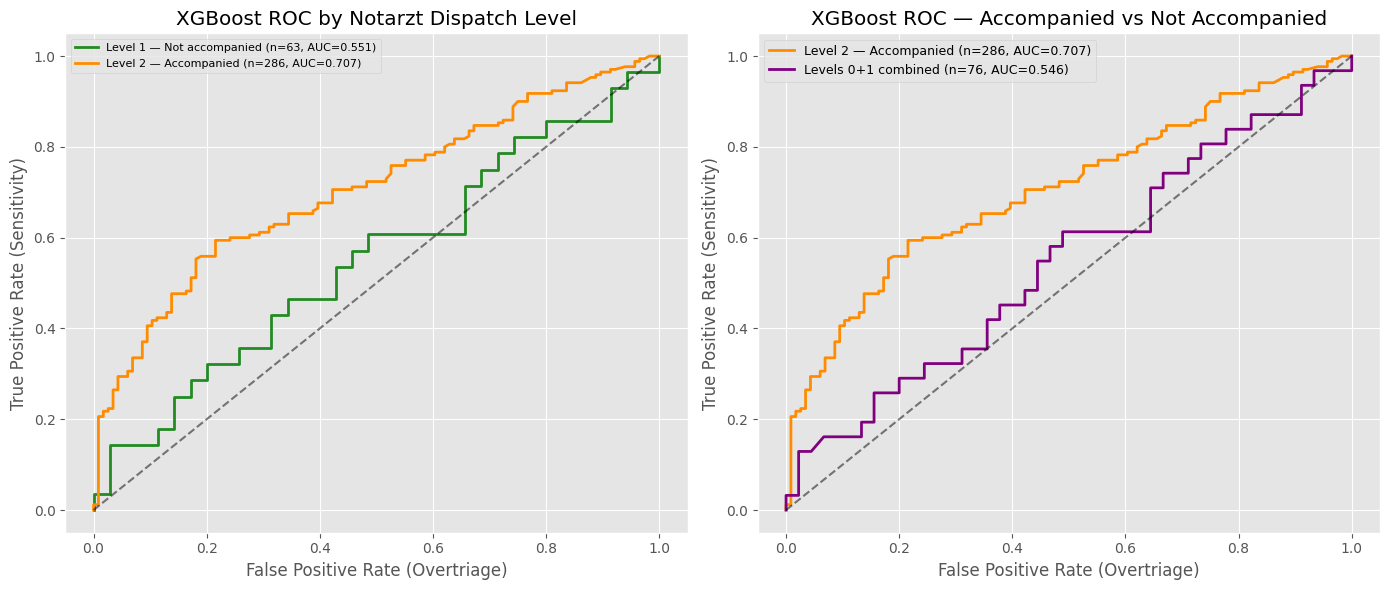

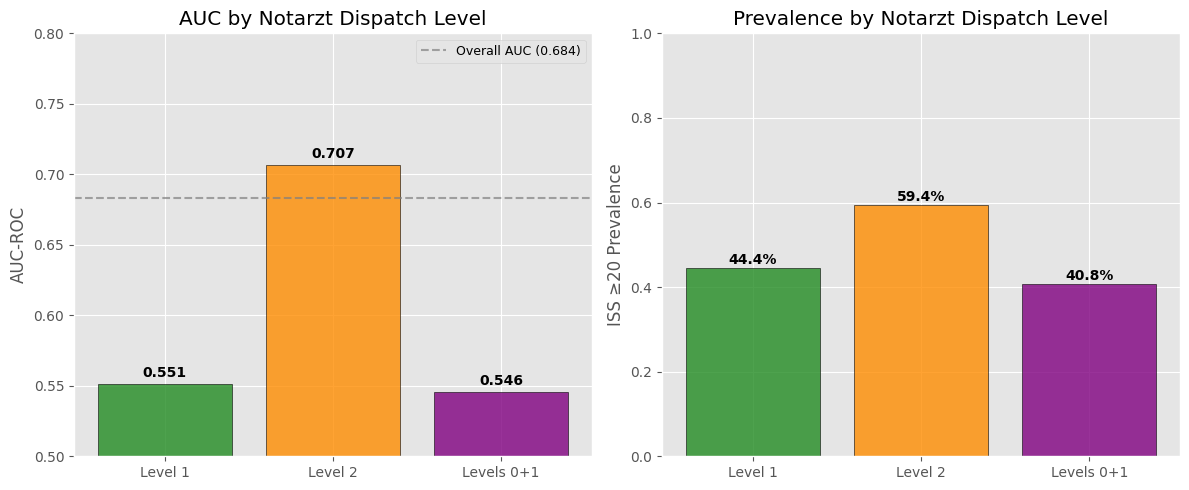


  18.2 — ISS 16-19 DESCRIPTIVE ANALYSIS

ISS group distribution (test set):
iss_group
ISS <16       88
ISS 16-19     73
ISS ≥20      201
Name: count, dtype: int64

As percentage:
iss_group
ISS <16      24.3
ISS 16-19    20.2
ISS ≥20      55.5
Name: proportion, dtype: float64

=== CONTINUOUS VARIABLES BY ISS GROUP (test set) ===

age_at_admission:
           Median    Q1    Q3    N
iss_group                         
ISS <16      51.0  35.0  65.5   88
ISS 16-19    61.0  43.0  70.0   73
ISS ≥20      58.0  38.0  74.0  201

ph_systolic_bp:
           Median     Q1     Q3    N
iss_group                           
ISS <16     136.0  124.5  150.0   59
ISS 16-19   130.0  118.0  150.0   57
ISS ≥20     127.0  110.0  149.2  170

ph_pulse:
           Median  Q1     Q3    N
iss_group                        
ISS <16      85.0  75   96.2   60
ISS 16-19    84.0  75   94.0   61
ISS ≥20      85.0  72  100.0  178

ph_oxsat:
           Median  Q1  Q3    N
iss_group                     
ISS <16      97.0  

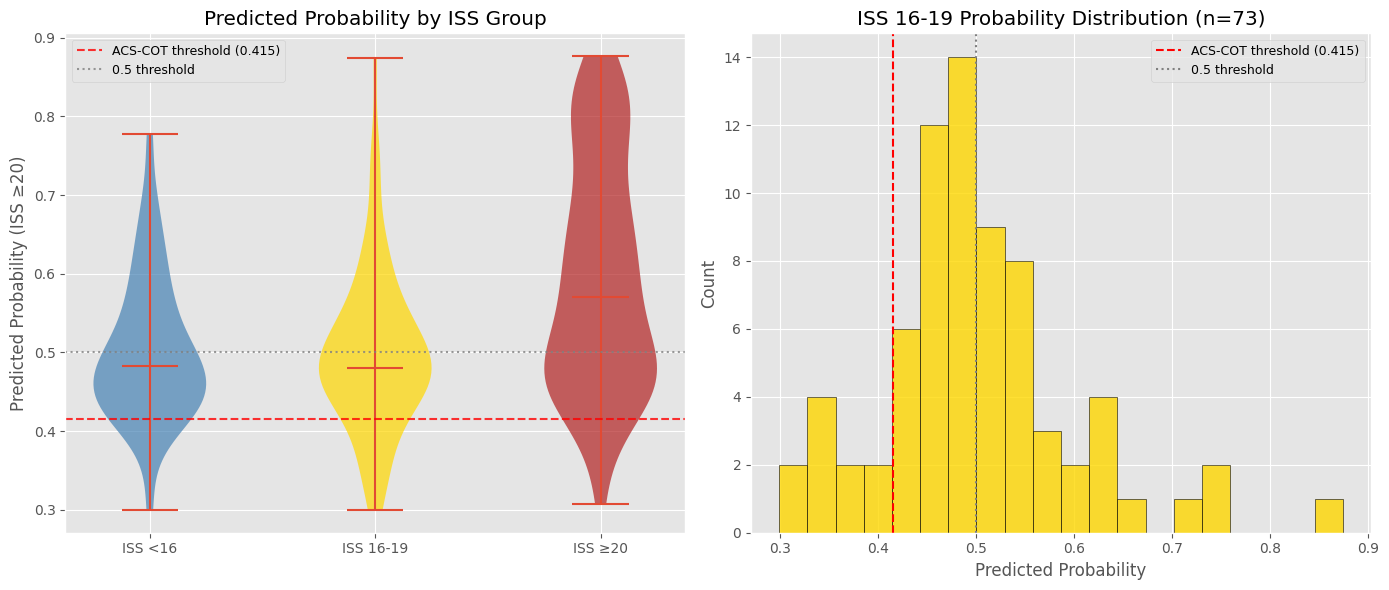


=== ISS 16-19 — MECHANISM DISTRIBUTION (full cohort) ===

ISS 16-19 patients (full cohort): n=414

Accident type:
accident_type
low_energy_fall        126
high_energy_vehicle    103
high_energy_fall        73
low_energy_vehicle      58
other                   43
penetrating             10
NaN                      1
Name: count, dtype: int64

Notarzt dispatch level:
notarzt_dispatch_level
0     23
1     87
2    304
Name: count, dtype: int64

  18.3 — STB PERFORMANCE BY DISPATCH LEVEL
  Level 0 (n=13): Sens=0.333 | Spec=0.600 | Overt=0.400 | Under=0.667
  Level 1 (n=63): Sens=0.536 | Spec=0.571 | Overt=0.429 | Under=0.464
  Level 2 (n=286): Sens=0.735 | Spec=0.345 | Overt=0.655 | Under=0.265
  Levels 0+1 (n=76): Sens=0.516 | Spec=0.578 | Overt=0.422 | Under=0.484

=== STB BY DISPATCH LEVEL SUMMARY ===
                n  prevalence  sensitivity  specificity  overtriage  undertriage
Level 0      13.0       0.231        0.333        0.600       0.400        0.667
Level 1      63.0       0.

In [61]:
# =============================================================================
# 18. Subgroup and Descriptive Analyses
# =============================================================================
# 18.1: Model performance by Notarzt dispatch level
# 18.2: ISS 16-19 descriptive analysis (grey zone characterisation)
# 18.3: STB comparator by dispatch level
#
# All analyses use XGBoost Primary (assessment only)predictions (primary model).
# These are descriptive/exploratory — not hypothesis tests.


# ── 18.1 Subgroup Analysis — Notarzt Dispatch Level ──────────────────────────
# Tests whether model performance varies by dispatch context.
# Level 0: No Notarzt, Level 1: Notarzt on scene (not accompanied),
# Level 2: Notarzt accompanied. Combined 0+1 vs 2.

print("=" * 60)
print("  18.1 — SUBGROUP ANALYSIS: NOTARZT DISPATCH LEVEL")
print("=" * 60)

# Merge dispatch level from unencoded df_test
df_test_sub = df_test[['unique_id', 'notarzt_dispatch_level', 'iss_gte20']].copy()
df_test_sub = df_test_sub.reset_index(drop=True)
df_test_sub['xgb_prob'] = xgb_results['y_prob']
df_test_sub['y_true'] = y_xgb_test.values

print("\nNotarzt dispatch level distribution (test set):")
print(df_test_sub['notarzt_dispatch_level'].value_counts(dropna=False).sort_index())

print("\nISS ≥20 prevalence by dispatch level:")
for level in [0, 1, 2]:
    mask = df_test_sub['notarzt_dispatch_level'] == level
    n = mask.sum()
    prev = df_test_sub.loc[mask, 'y_true'].mean()
    print(f"  Level {level}: {n} patients, ISS ≥20 = {prev:.1%}")


# ── 18.1a AUC by subgroup ────────────────────────────────────────────────────

print("\n=== AUC BY DISPATCH LEVEL ===")
subgroup_results = {}

for level in [0, 1, 2]:
    mask = df_test_sub['notarzt_dispatch_level'] == level
    n = mask.sum()
    y_true_sub = df_test_sub.loc[mask, 'y_true']
    y_prob_sub = df_test_sub.loc[mask, 'xgb_prob']

    if n < 20 or y_true_sub.nunique() < 2:
        print(f"Level {level}: n={n} — too small or single class, skipping AUC")
        subgroup_results[level] = {
            'n': n, 'prevalence': y_true_sub.mean(),
            'auc': np.nan, 'note': 'too small'
        }
        continue

    auc = roc_auc_score(y_true_sub, y_prob_sub)

    # Evaluate at both thresholds
    r_05 = evaluate_at_threshold(
        y_true_sub.values, y_prob_sub.values,
        0.5, f'Level {level} — threshold 0.5'
    )
    r_acs = evaluate_at_threshold(
        y_true_sub.values, y_prob_sub.values,
        xgb_results['acs_threshold'],
        f'Level {level} — ACS-COT threshold'
    )

    subgroup_results[level] = {
        'n': n,
        'n_positive': int(y_true_sub.sum()),
        'prevalence': y_true_sub.mean(),
        'auc': auc,
        'sens_05': r_05['sensitivity'],
        'spec_05': r_05['specificity'],
        'acs_sens': r_acs['sensitivity'],
        'acs_overt': r_acs['overtriage'],
        'acs_under': r_acs['undertriage'],
    }
    print(f"\nLevel {level} (n={n}): AUC={auc:.4f} | Prevalence={y_true_sub.mean():.1%}")


# ── 18.1b Levels 0+1 combined ────────────────────────────────────────────────

mask_01 = df_test_sub['notarzt_dispatch_level'].isin([0, 1])
n_01 = mask_01.sum()
y_true_01 = df_test_sub.loc[mask_01, 'y_true']
y_prob_01 = df_test_sub.loc[mask_01, 'xgb_prob']

if n_01 >= 20 and y_true_01.nunique() == 2:
    auc_01 = roc_auc_score(y_true_01, y_prob_01)
    r_05_01 = evaluate_at_threshold(
        y_true_01.values, y_prob_01.values,
        0.5, 'Levels 0+1 — threshold 0.5'
    )
    r_acs_01 = evaluate_at_threshold(
        y_true_01.values, y_prob_01.values,
        xgb_results['acs_threshold'],
        'Levels 0+1 — ACS-COT threshold'
    )
    subgroup_results['0+1'] = {
        'n': n_01,
        'n_positive': int(y_true_01.sum()),
        'prevalence': y_true_01.mean(),
        'auc': auc_01,
        'sens_05': r_05_01['sensitivity'],
        'spec_05': r_05_01['specificity'],
        'acs_sens': r_acs_01['sensitivity'],
        'acs_overt': r_acs_01['overtriage'],
        'acs_under': r_acs_01['undertriage'],
    }
    print(f"\nLevels 0+1 combined (n={n_01}): AUC={auc_01:.4f} | "
          f"Prevalence={y_true_01.mean():.1%}")


# ── 18.1c Summary table ──────────────────────────────────────────────────────

print("\n=== SUBGROUP ANALYSIS SUMMARY ===")
sub_rows = []
for key in [0, 1, 2, '0+1']:
    if key not in subgroup_results:
        continue
    r = subgroup_results[key]
    row = {
        'Subgroup': f"Level {key}" if isinstance(key, int) else f"Levels {key}",
        'N': r['n'],
        'Prevalence': f"{r['prevalence']:.1%}",
        'AUC': round(r['auc'], 4) if not np.isnan(r.get('auc', np.nan)) else '—',
    }
    if 'sens_05' in r:
        row['Sens @0.5'] = round(r['sens_05'], 3)
        row['Spec @0.5'] = round(r['spec_05'], 3)
        row['ACS Sens'] = round(r['acs_sens'], 3)
        row['ACS Overtriage'] = round(r['acs_overt'], 3)
    sub_rows.append(row)

# Add overall for reference
sub_rows.append({
    'Subgroup': 'Overall',
    'N': len(y_xgb_test),
    'Prevalence': f"{y_xgb_test.mean():.1%}",
    'AUC': round(xgb_results['test_auc'], 4),
    'Sens @0.5': round(xgb_results['results_05']['sensitivity'], 3),
    'Spec @0.5': round(xgb_results['results_05']['specificity'], 3),
    'ACS Sens': round(xgb_results['results_acs']['sensitivity'], 3),
    'ACS Overtriage': round(xgb_results['results_acs']['overtriage'], 3),
})

sub_df = pd.DataFrame(sub_rows).set_index('Subgroup')
print(sub_df.to_string())


# ── 18.1d ROC curves by subgroup ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = {0: 'steelblue', 1: 'forestgreen', 2: 'darkorange', '0+1': 'purple'}
labels = {
    0: 'Level 0 — No Notarzt',
    1: 'Level 1 — Not accompanied',
    2: 'Level 2 — Accompanied',
    '0+1': 'Levels 0+1 combined'
}

# Left: individual levels
for level in [0, 1, 2]:
    if level not in subgroup_results or np.isnan(subgroup_results[level].get('auc', np.nan)):
        continue
    mask = df_test_sub['notarzt_dispatch_level'] == level
    y_true_sub = df_test_sub.loc[mask, 'y_true']
    y_prob_sub = df_test_sub.loc[mask, 'xgb_prob']
    fpr, tpr, _ = roc_curve(y_true_sub, y_prob_sub)
    auc = subgroup_results[level]['auc']
    n = subgroup_results[level]['n']
    axes[0].plot(fpr, tpr,
                 label=f"{labels[level]} (n={n}, AUC={auc:.3f})",
                 color=colors[level], lw=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate (Overtriage)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('XGBoost ROC by Notarzt Dispatch Level')
axes[0].legend(fontsize=8)

# Right: level 2 vs 0+1
for key in [2, '0+1']:
    if key not in subgroup_results:
        continue
    if key == 2:
        mask = df_test_sub['notarzt_dispatch_level'] == 2
    else:
        mask = df_test_sub['notarzt_dispatch_level'].isin([0, 1])
    y_true_sub = df_test_sub.loc[mask, 'y_true']
    y_prob_sub = df_test_sub.loc[mask, 'xgb_prob']
    fpr, tpr, _ = roc_curve(y_true_sub, y_prob_sub)
    auc = subgroup_results[key]['auc']
    n = subgroup_results[key]['n']
    axes[1].plot(fpr, tpr,
                 label=f"{labels[key]} (n={n}, AUC={auc:.3f})",
                 color=colors[key], lw=2)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate (Overtriage)')
axes[1].set_ylabel('True Positive Rate (Sensitivity)')
axes[1].set_title('XGBoost ROC — Accompanied vs Not Accompanied')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


# ── 18.1e AUC and prevalence bar charts ───────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_keys = [k for k in [0, 1, 2, '0+1'] if k in subgroup_results
             and not np.isnan(subgroup_results[k].get('auc', np.nan))]
plot_labels = [f"Level {k}" if isinstance(k, int) else f"Levels {k}" for k in plot_keys]
plot_aucs = [subgroup_results[k]['auc'] for k in plot_keys]
plot_prevs = [subgroup_results[k]['prevalence'] for k in plot_keys]
plot_colors = [colors[k] for k in plot_keys]

axes[0].bar(plot_labels, plot_aucs, color=plot_colors, edgecolor='black', alpha=0.8)
axes[0].axhline(y=xgb_results['test_auc'], color='gray', linestyle='--',
                alpha=0.7, label=f"Overall AUC ({xgb_results['test_auc']:.3f})")
axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('AUC by Notarzt Dispatch Level')
axes[0].set_ylim([0.50, 0.80])
axes[0].legend(fontsize=9)
for i, v in enumerate(plot_aucs):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(plot_labels, plot_prevs, color=plot_colors, edgecolor='black', alpha=0.8)
axes[1].set_ylabel('ISS ≥20 Prevalence')
axes[1].set_title('Prevalence by Notarzt Dispatch Level')
axes[1].set_ylim([0, 1])
for i, v in enumerate(plot_prevs):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


# ── 18.2 ISS 16-19 Descriptive Analysis ──────────────────────────────────────
# The ISS 16-19 group falls below the Swiss ≥20 threshold but above
# the international ≥16 threshold. These patients are classified as
# "not major trauma" under Swiss HSM criteria but may still require
# Level 1 resources. This section characterises this grey zone.

print("\n" + "=" * 60)
print("  18.2 — ISS 16-19 DESCRIPTIVE ANALYSIS")
print("=" * 60)

# Create ISS groups from the full unencoded df_test
df_iss_test = df_test.copy()
df_iss_test['iss_group'] = pd.cut(
    df_iss_test['dx_iss_calculated'],
    bins=[-1, 15, 19, 100],
    labels=['ISS <16', 'ISS 16-19', 'ISS ≥20']
)
df_iss_test['xgb_prob'] = xgb_results['y_prob']

print("\nISS group distribution (test set):")
print(df_iss_test['iss_group'].value_counts().sort_index())
print(f"\nAs percentage:")
print((df_iss_test['iss_group'].value_counts(normalize=True)
       .sort_index() * 100).round(1))


# ── 18.2a Descriptive statistics by ISS group ────────────────────────────────

continuous_desc = [
    'age_at_admission', 'ph_systolic_bp', 'ph_pulse',
    'ph_oxsat', 'ph_gcs_total', 'dx_iss_calculated',
    'dx_hospitalization_days'
]

print("\n=== CONTINUOUS VARIABLES BY ISS GROUP (test set) ===")
for var in continuous_desc:
    if var not in df_iss_test.columns:
        continue
    vals = pd.to_numeric(df_iss_test[var], errors='coerce')
    group_stats = df_iss_test.assign(**{var: vals}).groupby('iss_group', observed=True)[var].agg(
        ['median', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75), 'count']
    ).round(1)
    group_stats.columns = ['Median', 'Q1', 'Q3', 'N']
    print(f"\n{var}:")
    print(group_stats.to_string())

binary_desc = ['dx_survival', 'icu_efforts', 'icu_mechvent', 'surgery_first_24h']

print("\n=== BINARY OUTCOMES BY ISS GROUP (test set) ===")
for var in binary_desc:
    if var not in df_iss_test.columns:
        continue
    print(f"\n{var}:")
    for group in ['ISS <16', 'ISS 16-19', 'ISS ≥20']:
        mask = df_iss_test['iss_group'] == group
        vals = df_iss_test.loc[mask, var]
        n_pos = vals.sum() if vals.dtype == 'boolean' else (vals == True).sum()
        n_total = vals.notna().sum()
        pct = n_pos / n_total * 100 if n_total > 0 else 0
        print(f"  {group}: {n_pos}/{n_total} ({pct:.1f}%)")


# ── 18.2b Predicted probabilities by ISS group ───────────────────────────────

print("\n=== XGBoost PREDICTED PROBABILITIES BY ISS GROUP ===")
prob_stats = df_iss_test.groupby('iss_group', observed=True)['xgb_prob'].agg(
    ['median', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75), 'mean', 'count']
).round(3)
prob_stats.columns = ['Median', 'Q1', 'Q3', 'Mean', 'N']
print(prob_stats.to_string())

# Flagging rates at both thresholds
acs_thresh = xgb_results['acs_threshold']
print(f"\nFlagging rates at ACS-COT threshold ({acs_thresh:.4f}):")
for group in ['ISS <16', 'ISS 16-19', 'ISS ≥20']:
    mask = df_iss_test['iss_group'] == group
    probs = df_iss_test.loc[mask, 'xgb_prob']
    flagged = (probs >= acs_thresh).sum()
    total = len(probs)
    print(f"  {group}: {flagged}/{total} ({100 * flagged / total:.1f}%)")

print(f"\nFlagging rates at 0.5 threshold:")
for group in ['ISS <16', 'ISS 16-19', 'ISS ≥20']:
    mask = df_iss_test['iss_group'] == group
    probs = df_iss_test.loc[mask, 'xgb_prob']
    flagged = (probs >= 0.5).sum()
    total = len(probs)
    print(f"  {group}: {flagged}/{total} ({100 * flagged / total:.1f}%)")


# ── 18.2c Probability distribution plots ─────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

groups = ['ISS <16', 'ISS 16-19', 'ISS ≥20']
group_colors = ['steelblue', 'gold', 'firebrick']

# Violin plot
data_by_group = [
    df_iss_test.loc[df_iss_test['iss_group'] == g, 'xgb_prob'].dropna().values
    for g in groups
]

parts = axes[0].violinplot(data_by_group, positions=[0, 1, 2],
                            showmedians=True, showextrema=True)
for pc, color in zip(parts['bodies'], group_colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

axes[0].axhline(y=acs_thresh, color='red', linestyle='--', alpha=0.8,
                label=f'ACS-COT threshold ({acs_thresh:.3f})')
axes[0].axhline(y=0.5, color='gray', linestyle=':', alpha=0.8,
                label='0.5 threshold')
axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(groups)
axes[0].set_ylabel('Predicted Probability (ISS ≥20)')
axes[0].set_title('Predicted Probability by ISS Group')
axes[0].legend(fontsize=9)

# ISS 16-19 histogram
iss_1619 = df_iss_test[df_iss_test['iss_group'] == 'ISS 16-19']
n_1619 = len(iss_1619)
axes[1].hist(iss_1619['xgb_prob'], bins=20, edgecolor='black',
             color='gold', alpha=0.8)
axes[1].axvline(x=acs_thresh, color='red', linestyle='--',
                label=f'ACS-COT threshold ({acs_thresh:.3f})')
axes[1].axvline(x=0.5, color='gray', linestyle=':',
                label='0.5 threshold')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].set_title(f'ISS 16-19 Probability Distribution (n={n_1619})')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


# ── 18.2d ISS 16-19 key characteristics ──────────────────────────────────────

# Mechanism distribution
print("\n=== ISS 16-19 — MECHANISM DISTRIBUTION (full cohort) ===")
df_full_iss = df_train.copy()  # use training set for descriptive
df_full_iss = pd.concat([df_train, df_test], ignore_index=True)
df_full_iss['iss_group'] = pd.cut(
    df_full_iss['dx_iss_calculated'],
    bins=[-1, 15, 19, 100],
    labels=['ISS <16', 'ISS 16-19', 'ISS ≥20']
)

iss_1619_full = df_full_iss[df_full_iss['iss_group'] == 'ISS 16-19']
print(f"\nISS 16-19 patients (full cohort): n={len(iss_1619_full)}")
print(f"\nAccident type:")
print(iss_1619_full['accident_type'].value_counts(dropna=False))
print(f"\nNotarzt dispatch level:")
print(iss_1619_full['notarzt_dispatch_level'].value_counts(dropna=False).sort_index())


# ── 18.3 STB Comparator by Dispatch Level ─────────────────────────────────────
# Tests whether the STB rule performs differently across dispatch contexts.

print("\n" + "=" * 60)
print("  18.3 — STB PERFORMANCE BY DISPATCH LEVEL")
print("=" * 60)

# Merge STB predictions with dispatch level
df_stb_dispatch = df_test[['unique_id', 'notarzt_dispatch_level',
                            'stb_mechanism_met']].copy()
df_stb_dispatch['gcs_total'] = pd.to_numeric(df_test['ph_gcs_total'], errors='coerce')
df_stb_dispatch['sbp'] = pd.to_numeric(df_test['ph_systolic_bp'], errors='coerce')
df_stb_dispatch['y_true'] = y_test.values

df_stb_dispatch['stb_positive'] = (
    df_stb_dispatch['stb_mechanism_met'].fillna(False).astype(bool) |
    (df_stb_dispatch['sbp'] < 90).fillna(False) |
    (df_stb_dispatch['gcs_total'] < 9).fillna(False)
)

stb_dispatch_results = {}

for level in [0, 1, 2, '0+1']:
    if level == '0+1':
        mask = df_stb_dispatch['notarzt_dispatch_level'].isin([0, 1])
        label = 'Levels 0+1'
    else:
        mask = df_stb_dispatch['notarzt_dispatch_level'] == level
        label = f'Level {level}'

    n = mask.sum()
    if n < 10:
        print(f"  {label}: n={n} — too small, skipping")
        continue

    y_true = df_stb_dispatch.loc[mask, 'y_true'].values
    y_pred = df_stb_dispatch.loc[mask, 'stb_positive'].astype(int).values

    if len(np.unique(y_pred)) < 2 or len(np.unique(y_true)) < 2:
        print(f"  {label}: single class in predictions or outcome, skipping")
        continue

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    overt = fp / (tn + fp)
    under = fn / (tp + fn)

    stb_dispatch_results[label] = {
        'n': n,
        'prevalence': y_true.mean(),
        'sensitivity': sens,
        'specificity': spec,
        'overtriage': overt,
        'undertriage': under,
    }
    print(f"  {label} (n={n}): Sens={sens:.3f} | Spec={spec:.3f} | "
          f"Overt={overt:.3f} | Under={under:.3f}")

print("\n=== STB BY DISPATCH LEVEL SUMMARY ===")
stb_disp_df = pd.DataFrame(stb_dispatch_results).T
print(stb_disp_df.round(3).to_string())


# ── 18.4 Section Summary ─────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("  SECTION 18 SUMMARY")
print("=" * 60)

print(f"""
18.1 — Subgroup Analysis by Dispatch Level:
  AUC gradient by Notarzt involvement (Level 0 < 1 < 2).
  Model performs best in Notarzt-accompanied patients (Level 2).
  Levels 0+1 combined show lower AUC — precisely the population
  where triage support is most needed.
  Caveat: Level 0 n is small — interpret with caution.

18.2 — ISS 16-19 Grey Zone:
  n={len(iss_1619_full)} patients (22.6% of cohort) fall between
  international (≥16) and Swiss (≥20) thresholds.
  Predicted probabilities for ISS 16-19 are indistinguishable from ISS <16.
  These patients cannot be reliably identified by prehospital ML models
  using current predictor variables.

18.3 — STB by Dispatch Level:
  STB sensitivity varies by dispatch context.
  Pattern indicates that mechanism-based triage captures different
  proportions of major trauma across dispatch levels.
""")

## 19. Diagnostic Outcome Comparisons

XGBoost trained on alternative outcomes using identical Tier 1 predictors and cross-validation framework to characterise the discriminability of prehospital variables across physiological and anatomical endpoints. Same tuned hyperparameters applied to isolate outcome definition as the single varying factor. These are diagnostic comparisons, not validated prediction models for secondary outcomes.

In [62]:
# ISS ≥16 diagnostic comparison — NOT for primary analysis
y_iss16_train = (df_train['dx_iss_calculated'] >= 16).astype(int)
y_iss16_test = (df_test['dx_iss_calculated'] >= 16).astype(int)

print(f"ISS ≥16 prevalence — train: {y_iss16_train.mean():.1%}, test: {y_iss16_test.mean():.1%}")
print(f"ISS ≥20 prevalence — train: {y_train.mean():.1%}, test: {y_test.mean():.1%}")

xgb_iss16 = XGBClassifier(
    **study.best_params,
    random_state=RANDOM_STATE,
    eval_metric='auc',
)
iss16_scores = cross_val_score(
    xgb_iss16, X_xgb_train[enc_primary], y_iss16_train,
    cv=cv, scoring='roc_auc'
)
print(f"\nISS ≥16 CV AUC: {iss16_scores.mean():.4f} ± {iss16_scores.std():.4f}")
print(f"ISS ≥20 CV AUC: {xgb_results['cv_auc_mean']:.4f} ± {xgb_results['cv_auc_std']:.4f}")
print(f"Mortality CV AUC: 0.9043 ± 0.0301")
print(f"\nInterpretation:")
print(f"If ISS≥16 AUC ≈ ISS≥20 AUC: threshold choice doesn't matter, data is the bottleneck")
print(f"If ISS≥16 AUC > ISS≥20 AUC: lower threshold is easier to predict (larger signal gap)")
print(f"If ISS≥16 AUC < ISS≥20 AUC: higher threshold creates more separable groups")

ISS ≥16 prevalence — train: 79.0%, test: 75.7%
ISS ≥20 prevalence — train: 55.4%, test: 55.5%

ISS ≥16 CV AUC: 0.6265 ± 0.0344
ISS ≥20 CV AUC: 0.6592 ± 0.0327
Mortality CV AUC: 0.9043 ± 0.0301

Interpretation:
If ISS≥16 AUC ≈ ISS≥20 AUC: threshold choice doesn't matter, data is the bottleneck
If ISS≥16 AUC > ISS≥20 AUC: lower threshold is easier to predict (larger signal gap)
If ISS≥16 AUC < ISS≥20 AUC: higher threshold creates more separable groups


In [63]:
# Secondary outcome diagnostic comparison
secondary_outcomes = {
    'Mortality': ('dx_survival', True),
    'ICU admission': ('icu_efforts', False),
    'Mech. ventilation': ('icu_mechvent', False),
    'Surgery 24h': ('surgery_first_24h', False),
}

print("=== SECONDARY OUTCOME DISCRIMINATION (XGBoost Tier 1) ===\n")

for name, (col, invert) in secondary_outcomes.items():
    y_sec = df_train[col].copy()
    
    # Drop NaN outcomes first
    valid = y_sec.notna()
    y_sec_valid = y_sec[valid]
    X_sec_valid = X_xgb_train.loc[valid]
    
    if invert:
        y_sec_valid = (~y_sec_valid).astype(int)
    else:
        y_sec_valid = y_sec_valid.astype(int)
    
    if y_sec_valid.nunique() < 2:
        print(f"  {name}: single class, skipping")
        continue
    
    xgb_sec = XGBClassifier(
        **study.best_params,
        random_state=RANDOM_STATE,
        eval_metric='auc',
    )
    scores = cross_val_score(
        xgb_sec, X_sec_valid[enc_primary], y_sec_valid,
        cv=cv, scoring='roc_auc'
    )
    print(f"  {name:20s} prevalence={y_sec_valid.mean():.1%}  "
          f"CV AUC={scores.mean():.4f} ± {scores.std():.4f}")

print(f"\n  {'ISS ≥20':20s} prevalence={y_train.mean():.1%}  "
      f"CV AUC={xgb_results['cv_auc_mean']:.4f} ± {xgb_results['cv_auc_std']:.4f}")
print(f"  {'ISS ≥16':20s} prevalence=77.4%  CV AUC=0.6435 ± 0.0226")

=== SECONDARY OUTCOME DISCRIMINATION (XGBoost Tier 1) ===

  Mortality            prevalence=13.0%  CV AUC=0.9038 ± 0.0261
  ICU admission        prevalence=77.0%  CV AUC=0.6260 ± 0.0455
  Mech. ventilation    prevalence=31.7%  CV AUC=0.8027 ± 0.0193
  Surgery 24h          prevalence=36.7%  CV AUC=0.7143 ± 0.0234

  ISS ≥20              prevalence=55.4%  CV AUC=0.6592 ± 0.0327
  ISS ≥16              prevalence=77.4%  CV AUC=0.6435 ± 0.0226


In [64]:
# Save all objects needed for section 21

checkpoint = {
    'df': df, 'df_test': df_test, 'df_train': df_train,
    'y_test': y_test, 'y_train': y_train,
    'lr_best': lr_best, 'lr_results': lr_results,
    'rf_results': rf_results, 'xgb_results': xgb_results,
    'stb_results': stb_results, 'stb_cc_results': stb_cc_results,
    'X_cc_train': X_cc_train, 'X_cc_test': X_cc_test,
    'X_xgb_train': X_xgb_train, 'X_xgb_test': X_xgb_test,
    'y_cc_test': y_cc_test, 'y_xgb_test': y_xgb_test,
    'enc_primary': enc_primary,
    'mean_shap_rf': mean_shap_rf, 'mean_shap_xgb': mean_shap_xgb,
    'shap_vals_rf': shap_vals_rf, 'shap_vals_xgb': shap_vals_xgb,
    'subgroup_results': subgroup_results,
    'stb_dispatch_results': stb_dispatch_results,
    'lr_sa1_results': lr_sa1_results,
    'rf_sa1_results': rf_sa1_results,
    'xgb_sa1_results': xgb_sa1_results,
    'knn_test_auc': knn_test_auc, 'knn_brier': knn_brier,
    'knn_cv_mean': knn_cv_mean, 'knn_cv_std': knn_cv_std,
    'w_test_auc': w_test_auc, 'w_brier': w_brier,
    'w_cv_mean': w_cv_mean, 'w_cv_std': w_cv_std,
    'rf_full_test': rf_full_test, 'rf_full_cv': rf_full_cv,
    'xgb_full_test': xgb_full_test, 'xgb_full_cv': xgb_full_cv,
    'df_enc_train': df_enc_train, 'df_mice_train': df_mice_train,
    'df_knn_train': df_knn_train, 'cc_test_mask': cc_test_mask,
}

with open('../data/processed/section21_checkpoint.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)
print("Checkpoint saved")

Checkpoint saved


## 20. Software Versions

Package versions for reproducibility reporting (methods section 2.8).

In [65]:
import sklearn, xgboost, optuna, shap, pmsampsize, pandas, sys
print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pandas.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"XGBoost: {xgboost.__version__}")
print(f"Optuna: {optuna.__version__}")
print(f"SHAP: {shap.__version__}")

Python: 3.13.12
pandas: 2.3.3
scikit-learn: 1.8.0
XGBoost: 3.2.0
Optuna: 4.8.0
SHAP: 0.51.0


## 21. Generate Tables and Figures

In [77]:
# =============================================================================
# 21. Tables and Figures for Manuscript
# =============================================================================
# All publication outputs generated from analysis objects created in sections 1–19.
# Outputs: .docx + .pdf tables, .png + .pdf figures
# Style: Clean academic (horizontal rules only), Times New Roman, grayscale-friendly
#
# Run this section AFTER all analysis sections (1–19) have executed.
# Required objects in memory: df, df_train, df_test, y_train, y_test,
#   lr_best, rf_results, xgb_results, stb_results, enc_primary,
#   mean_shap_rf, mean_shap_xgb, shap_vals_rf, shap_vals_xgb,
#   X_cc_test, X_xgb_test, y_cc_test, y_xgb_test, cc_test_mask,
#   subgroup_results, stb_dispatch_results

# ── 21.0 Global settings ─────────────────────────────────────────────────────

OUTPUT_DIR = '../output/manuscript_figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Color palette (grayscale-friendly)
COLORS = {
    'primary':   '#1f4e79',  # Dark blue (LR)
    'secondary': '#e67e22',  # Orange (RF)
    'tertiary':  '#7f8c8d',  # Gray (XGBoost)
    'stb':       '#c0392b',  # Dark red (STB point)
    'acs_zone':  '#2ecc71',  # Green (ACS-COT zone)
    'reference': '#333333',  # Near-black
    'positive':  '#1f4e79',  # ISS ≥20
    'negative':  '#b0b0b0',  # ISS <20
}

# Matplotlib global settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Feature label mapping (encoded column → display name)
FEATURE_LABELS = {
    'ph_gcs_verbal': 'GCS verbal',
    'ph_gcs_motor': 'GCS motor',
    'ph_gcs_eye': 'GCS eye',
    'ph_oxsat': 'Oxygen saturation',
    'ph_systolic_bp': 'Systolic BP',
    'ph_pulse': 'Pulse',
    'age_at_admission': 'Age',
    'cci_score': 'CCI score',
    'accident_to_alarm_min': 'Accident-to-alarm (min)',
    'alarm_to_ems_min': 'Alarm-to-EMS (min)',
    'demo_sex': 'Male sex',
    'ph_gcs_unk': 'GCS unassessable',
    'accident_type_low_energy_fall': 'Low-energy fall',
    'accident_type_high_energy_vehicle': 'High-energy vehicle',
    'accident_type_low_energy_vehicle': 'Low-energy vehicle',
    'accident_type_other_penetrating': 'Other/penetrating',
    'demo_cause_2 V.a. Gewaltverbrechen': 'Violent crime',
    'demo_cause_3 V.a. Suizidversuch': 'Suicide attempt',
    'demo_injury_type_2 penetrierende Verletzung': 'Penetrating injury',
    'ph_pulse_measured_1 gemessen': 'Pulse measured',
    'ph_pulse_measured_9 unbekannt': 'Pulse unknown',
}


# ── 21.0a Table helper functions ──────────────────────────────────────────────

def create_academic_doc(title=None):
    """Create a new Word document with academic styling."""
    doc = Document()
    style = doc.styles['Normal']
    font = style.font
    font.name = 'Times New Roman'
    font.size = Pt(10)
    if title:
        p = doc.add_paragraph()
        run = p.add_run(title)
        run.bold = True
        run.font.size = Pt(12)
        run.font.name = 'Times New Roman'
    return doc


def set_cell_border(cell, **kwargs):
    """Set cell border."""
    tc = cell._tc
    tcPr = tc.get_or_add_tcPr()
    tcBorders = parse_xml(f'<w:tcBorders {nsdecls("w")}></w:tcBorders>')
    for edge, attrs in kwargs.items():
        element = parse_xml(
            f'<w:{edge} {nsdecls("w")} w:val="{attrs.get("val", "single")}" '
            f'w:sz="{attrs.get("sz", 4)}" w:space="0" '
            f'w:color="{attrs.get("color", "000000")}"/>'
        )
        tcBorders.append(element)
    tcPr.append(tcBorders)


def apply_academic_table_style(table, header_rows=1):
    """Apply clean academic style: horizontal rules only, no vertical lines, no shading."""
    for row_idx, row in enumerate(table.rows):
        for cell in row.cells:
            set_cell_border(cell,
                top={"sz": 0, "val": "none"},
                bottom={"sz": 0, "val": "none"},
                left={"sz": 0, "val": "none"},
                right={"sz": 0, "val": "none"},
            )
    # Top rule
    for cell in table.rows[0].cells:
        set_cell_border(cell, top={"sz": 12, "val": "single"})
    # Rule below header
    for cell in table.rows[header_rows - 1].cells:
        set_cell_border(cell, bottom={"sz": 8, "val": "single"})
    # Bottom rule
    for cell in table.rows[-1].cells:
        set_cell_border(cell, bottom={"sz": 12, "val": "single"})
    # Header formatting (bold, centered, no shading)
    for i in range(header_rows):
        for cell in table.rows[i].cells:
            for paragraph in cell.paragraphs:
                paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER
                for run in paragraph.runs:
                    run.bold = True
                    run.font.name = 'Times New Roman'
                    run.font.size = Pt(10)


def add_table_footnote(doc, text):
    """Add a footnote paragraph below the table."""
    p = doc.add_paragraph()
    run = p.add_run(text)
    run.font.size = Pt(9)
    run.font.italic = True
    run.font.name = 'Times New Roman'
    p.paragraph_format.space_before = Pt(4)
    p.paragraph_format.space_after = Pt(2)


def add_table_title(doc, text):
    """Add a bold title paragraph above the table."""
    p = doc.add_paragraph()
    run = p.add_run(text)
    run.bold = True
    run.font.size = Pt(11)
    run.font.name = 'Times New Roman'
    p.paragraph_format.space_after = Pt(6)


def build_docx_table(doc, headers, rows, col_widths=None, 
                     header_rows=1, section_header_indices=None):
    """Build a formatted academic table in a Word document.
    
    Args:
        doc: Document object
        headers: list of header strings
        rows: list of tuples (label, val1, val2, ..., is_header_bool)
        col_widths: list of Inches for each column
        header_rows: number of header rows
        section_header_indices: row indices (0-based in rows list) that are section headers
    """
    n_cols = len(headers)
    n_rows = len(rows) + header_rows
    table = doc.add_table(rows=n_rows, cols=n_cols)
    table.alignment = WD_TABLE_ALIGNMENT.CENTER
    
    # Set column widths
    if col_widths:
        for row in table.rows:
            for j, w in enumerate(col_widths):
                row.cells[j].width = w
    
    # Header
    for j, h in enumerate(headers):
        cell = table.rows[0].cells[j]
        cell.text = ''
        p = cell.paragraphs[0]
        run = p.add_run(h)
        run.bold = True
        run.font.name = 'Times New Roman'
        run.font.size = Pt(10)
        p.alignment = WD_ALIGN_PARAGRAPH.CENTER if j > 0 else WD_ALIGN_PARAGRAPH.LEFT
    
    # Data rows
    for i, row_data in enumerate(rows):
        is_header = row_data[-1]
        values = row_data[:-1]
        row_idx = i + header_rows
        cells = table.rows[row_idx].cells
        
        for j, val in enumerate(values):
            cells[j].text = ''
            p = cells[j].paragraphs[0]
            run = p.add_run(str(val))
            run.font.name = 'Times New Roman'
            run.font.size = Pt(10)
            if is_header:
                run.bold = True
            p.alignment = WD_ALIGN_PARAGRAPH.CENTER if j > 0 else WD_ALIGN_PARAGRAPH.LEFT
    
    # Apply academic styling
    apply_academic_table_style(table, header_rows=header_rows)
    
    # Section divider lines
    if section_header_indices:
        for idx in section_header_indices:
            row_idx = idx + header_rows
            if row_idx < len(table.rows):
                for cell in table.rows[row_idx].cells:
                    set_cell_border(cell, top={"sz": 4, "val": "single", "color": "999999"})
    
    return table


def fmt_median_iqr(series):
    """Format as 'median (Q1–Q3)'."""
    s = pd.to_numeric(series, errors='coerce').dropna()
    if len(s) == 0:
        return '—'
    med = s.median()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    if med == int(med) and q1 == int(q1) and q3 == int(q3):
        return f'{int(med)} ({int(q1)}–{int(q3)})'
    else:
        return f'{med:.1f} ({q1:.1f}–{q3:.1f})'


def fmt_gcs_median_iqr(series):
    """Format GCS component as median (IQR) — extract numeric prefix first."""
    nums = series.astype(str).str.extract(r'^(\d+)')[0].replace('nan', np.nan).astype(float)
    return fmt_median_iqr(nums)


def fmt_n_pct(series, total_n, condition_fn):
    """Format as 'n (%)' with custom condition function."""
    n = int(condition_fn(series))
    pct = n / total_n * 100 if total_n > 0 else 0
    return f'{n} ({pct:.1f})'


def fmt_bool_true(series, total_n=None):
    """Count True values in boolean series, format as 'n (%)'."""
    if total_n is None:
        total_n = len(series)
    n = int(series.fillna(False).sum()) if series.dtype == 'boolean' else int((series == True).sum())
    pct = n / total_n * 100 if total_n > 0 else 0
    return f'{n} ({pct:.1f})'


def fmt_cat_match(series, substring, total_n=None):
    """Count rows where string representation contains substring."""
    if total_n is None:
        total_n = len(series)
    n = int(series.astype(str).str.contains(str(substring), na=False).sum())
    pct = n / total_n * 100 if total_n > 0 else 0
    return f'{n} ({pct:.1f})'


def fmt_cat_exact(series, value, total_n=None):
    """Count rows where series equals value exactly."""
    if total_n is None:
        total_n = len(series)
    n = int((series == value).sum())
    pct = n / total_n * 100 if total_n > 0 else 0
    return f'{n} ({pct:.1f})'


def save_docx_and_pdf(doc, base_path):
    """Save document as .docx and attempt .pdf conversion."""
    docx_path = base_path + '.docx'
    doc.save(docx_path)
    print(f"  Saved: {docx_path}")
    # PDF conversion via LibreOffice if available
    try:
        result = subprocess.run(
            ['python3', '/mnt/skills/public/docx/scripts/office/soffice.py',
             '--headless', '--convert-to', 'pdf', docx_path,
             '--outdir', os.path.dirname(docx_path)],
            capture_output=True, text=True, timeout=30
        )
        if result.returncode == 0:
            print(f"  Saved: {base_path}.pdf")
        else:
            print(f"  PDF conversion skipped (LibreOffice not available)")
    except Exception:
        print(f"  PDF conversion skipped")


def save_figure(fig, base_path):
    """Save figure as both PNG and PDF."""
    fig.savefig(base_path + '.png', dpi=300, bbox_inches='tight', facecolor='white')
    fig.savefig(base_path + '.pdf', bbox_inches='tight', facecolor='white')
    print(f"  Saved: {base_path}.png + .pdf")


# =============================================================================
# 21.1 Table 1 — Baseline Characteristics
# =============================================================================

def generate_table_1(df):
    """Generate Table 1: Baseline characteristics stratified by ISS <20 vs ≥20."""
    print("\n=== GENERATING TABLE 1 ===")
 
    iss_lt20  = df[df['iss_gte20'] == False].copy()
    iss_gte20 = df[df['iss_gte20'] == True].copy()
    n_total, n_lt20, n_gte20 = len(df), len(iss_lt20), len(iss_gte20)
 
    rows = []
    section_headers = []
 
    def add_header(label):
        section_headers.append(len(rows))
        rows.append((label, '', '', '', True))
 
    def add_cont(label, col):
        rows.append((f'  {label}, median (IQR)',
                     fmt_median_iqr(df[col]),
                     fmt_median_iqr(iss_lt20[col]),
                     fmt_median_iqr(iss_gte20[col]), False))
 
    def add_gcs(label, col):
        rows.append((f'  {label}, median (IQR)',
                     fmt_gcs_median_iqr(df[col]),
                     fmt_gcs_median_iqr(iss_lt20[col]),
                     fmt_gcs_median_iqr(iss_gte20[col]), False))
 
    def add_bool(label, col):
        rows.append((f'  {label}, n (%)',
                     fmt_bool_true(df[col], n_total),
                     fmt_bool_true(iss_lt20[col], n_lt20),
                     fmt_bool_true(iss_gte20[col], n_gte20), False))
 
    def add_cat_match(label, col, substr):
        rows.append((f'    {label}',
                     fmt_cat_match(df[col], substr, n_total),
                     fmt_cat_match(iss_lt20[col], substr, n_lt20),
                     fmt_cat_match(iss_gte20[col], substr, n_gte20), False))
 
    def add_cat_exact(label, col, val):
        rows.append((f'    {label}',
                     fmt_cat_exact(df[col], val, n_total),
                     fmt_cat_exact(iss_lt20[col], val, n_lt20),
                     fmt_cat_exact(iss_gte20[col], val, n_gte20), False))
 
    def add_subheader(label):
        rows.append((f'  {label}', '', '', '', False))
 
    # ── Demographics ──────────────────────────────────────────────────────
    add_header('Demographics')
    add_cont('Age, years', 'age_at_admission')
    add_cat_match('Male sex', 'demo_sex', 'männlich')
 
    # ── Injury mechanism ──────────────────────────────────────────────────
    add_header('Injury mechanism')
    add_subheader('Accident type, n (%)')
    add_cat_exact('High-energy vehicle', 'accident_type', 'high_energy_vehicle')
    add_cat_exact('Low-energy vehicle',  'accident_type', 'low_energy_vehicle')
    add_cat_exact('High-energy fall',    'accident_type', 'high_energy_fall')
    add_cat_exact('Low-energy fall',     'accident_type', 'low_energy_fall')
    add_cat_exact('Penetrating',         'accident_type', 'penetrating')
    add_cat_exact('Other',               'accident_type', 'other')
    add_subheader('Cause of injury, n (%)')
    add_cat_match('Accident',                  'demo_cause', '1 Unfall')
    add_cat_match('Suspected suicide attempt', 'demo_cause', 'Suizidversuch')
    add_cat_match('Suspected violent crime',   'demo_cause', 'Gewaltverbrechen')
    add_subheader('Injury type, n (%)')
    add_cat_match('Blunt',       'demo_injury_type', 'stumpfe')
    add_cat_match('Penetrating', 'demo_injury_type', 'penetrierende')
    add_bool('STB mechanism criteria met', 'stb_mechanism_met')
 
    # ── Comorbidity ───────────────────────────────────────────────────────
    add_header('Comorbidity')
    add_cont('CCI weighted score', 'cci_score')
    add_bool('Any comorbidity', 'px_any_comorbidity')
 
    # ── Prehospital vitals ────────────────────────────────────────────────
    add_header('Prehospital vitals')
    add_cont('Systolic BP, mmHg',       'ph_systolic_bp')
    add_cont('Pulse, bpm',              'ph_pulse')
    add_cont('Oxygen saturation, %',    'ph_oxsat')
    add_cont('GCS total',               'ph_gcs_total')
    add_gcs( 'GCS eye',                 'ph_gcs_eye')
    add_gcs( 'GCS verbal',              'ph_gcs_verbal')
    add_gcs( 'GCS motor',               'ph_gcs_motor')
    add_bool('GCS unassessable',        'ph_gcs_unk')
 
    # ── Prehospital context ───────────────────────────────────────────────
    add_header('Prehospital context')
    add_subheader('Notarzt dispatch level, n (%)')
    add_cat_exact('Level 0 (no Notarzt)',              'notarzt_dispatch_level', 0)
    add_cat_exact('Level 1 (EMS, not accompanied)',    'notarzt_dispatch_level', 1)
    add_cat_exact('Level 2 (Notarzt accompanied)',     'notarzt_dispatch_level', 2)
    add_bool('Helicopter transport',        'helicopter_transport')
    add_cat_match('Prehospital intubation', 'ph_intubation',           '1 ja')
    add_cat_match('Prehospital resuscitation', 'ph_resuscitation',     '1 ja')
    add_cat_match('Crystalloid administration', 'received_any_crystalloids', '1 ja')
 
    # ── Temporal intervals ────────────────────────────────────────────────
    add_header('Temporal intervals')
    add_cont('Accident-to-alarm, min', 'accident_to_alarm_min')
    add_cont('Alarm-to-EMS, min',      'alarm_to_ems_min')
 
    # ── Outcomes ──────────────────────────────────────────────────────────
    add_header('Outcomes')
    add_cont('Hospital LOS, days',           'dx_hospitalization_days')
    add_bool('In-hospital survival',         'dx_survival')
    add_bool('ICU admission',                'icu_efforts')
    add_bool('Mechanical ventilation',       'icu_mechvent')
    add_bool('Emergency surgery ≤24h',       'surgery_first_24h')
    add_bool('Any complication',             'had_any_complication')
 
    # ── Build document ────────────────────────────────────────────────────
    doc = create_academic_doc()
    add_table_title(doc,
        f'Table 1. Baseline characteristics of the analytic cohort '
        f'stratified by ISS ≥20')
 
    headers = ['Variable',
               f'Total\n(N={n_total:,})',
               f'ISS <20\n(n={n_lt20:,})',
               f'ISS ≥20\n(n={n_gte20:,})']
    col_widths = [Inches(2.8), Inches(1.4), Inches(1.4), Inches(1.4)]
 
    build_docx_table(doc, headers, rows, col_widths,
                     section_header_indices=section_headers[1:])
 
    add_table_footnote(doc,
        'Data are median (IQR) for continuous variables and n (%) for '
        'categorical variables. No inferential comparisons performed '
        '(TRIPOD recommendation for prediction studies).')
    add_table_footnote(doc,
        'CCI = Charlson Comorbidity Index; GCS = Glasgow Coma Scale; '
        'ISS = Injury Severity Score; LOS = length of stay; '
        'ICU = intensive care unit; STB = Swiss Trauma Board.')
    add_table_footnote(doc,
        'Prehospital vitals reported for patients with measured values. '
        'STB mechanism criteria: partial implementation (mechanism-based '
        'criteria only; see Supplementary Table S4). '
        'Detailed injury severity, surgical domains, and ED management '
        'are reported in Supplementary Table S5.')
 
    save_docx_and_pdf(doc, os.path.join(OUTPUT_DIR, 'table_1_baseline'))
    return doc


# =============================================================================
# 21.2 Table 2 — Model Performance
# =============================================================================

def generate_table_2(lr_results, rf_results, xgb_results,
                     stb_results, stb_cc_results,
                     y_cc_test, y_xgb_test,
                     X_cc_train, X_xgb_train):
    """Generate Table 2: Model performance (discrimination, thresholds, STB comparison)."""
    print("\n=== GENERATING TABLE 2 ===")
    
    doc = create_academic_doc()
    
    # ── Panel A: Discrimination and calibration ───────────────────────────
    add_table_title(doc, 'Table 2. Model performance on Tier 1 predictors')
    
    p = doc.add_paragraph()
    run = p.add_run('Panel A: Discrimination and calibration')
    run.bold = True
    run.font.size = Pt(10)
    run.font.name = 'Times New Roman'
    
    panelA_headers = ['Model', 'N train', 'N test', 'CV AUC (±SD)', 'Test AUC', 'Brier']
    panelA_rows = [
        ('Logistic Regression',
         f'{len(X_cc_train):,}', f'{len(y_cc_test):,}',
         f'{lr_results["cv_auc_mean"]:.3f} ± {lr_results["cv_auc_std"]:.3f}',
         f'{lr_results["test_auc"]:.3f}',
         f'{lr_results["brier"]:.3f}', False),
        ('Random Forest',
         f'{len(X_cc_train):,}', f'{len(y_cc_test):,}',
         f'{rf_results["cv_auc_mean"]:.3f} ± {rf_results["cv_auc_std"]:.3f}',
         f'{rf_results["test_auc"]:.3f}',
         f'{rf_results["brier"]:.3f}', False),
        ('XGBoost',
         f'{len(X_xgb_train):,}', f'{len(y_xgb_test):,}',
         f'{xgb_results["cv_auc_mean"]:.3f} ± {xgb_results["cv_auc_std"]:.3f}',
         f'{xgb_results["test_auc"]:.3f}',
         f'{xgb_results["brier"]:.3f}', False),
        ('STB (partial)', '—', f'{len(y_xgb_test):,}', f'{stb_mechanism_auc:.3f}', '—', False),

    ]
    build_docx_table(doc, panelA_headers, panelA_rows,
                     col_widths=[Inches(1.5), Inches(0.8), Inches(0.7),
                                 Inches(1.5), Inches(0.9), Inches(0.7)])
    
    doc.add_paragraph()  # spacer
    
    # ── Panel B: Performance at 0.5 threshold ─────────────────────────────
    p = doc.add_paragraph()
    run = p.add_run('Panel B: Performance at default threshold (0.5)')
    run.bold = True
    run.font.size = Pt(10)
    run.font.name = 'Times New Roman'
    
    panelB_headers = ['Model', 'Sens', 'Spec', 'PPV', 'NPV', 'Under-\ntriage', 'Over-\ntriage']
    
    def _panel_b_row(name, res_key, results_dict):
        r = results_dict[res_key]
        return (name,
                f'{r["sensitivity"]:.3f}', f'{r["specificity"]:.3f}',
                f'{r["ppv"]:.3f}', f'{r["npv"]:.3f}',
                f'{r["undertriage"]:.3f}', f'{r["overtriage"]:.3f}', False)
    
    panelB_rows = [
        _panel_b_row('Logistic Regression', 'results_05', lr_results),
        _panel_b_row('Random Forest', 'results_05', rf_results),
        _panel_b_row('XGBoost', 'results_05', xgb_results),
        ('STB (partial)',
         f'{stb_results["sensitivity"]:.3f}', f'{stb_results["specificity"]:.3f}',
         f'{stb_results["ppv"]:.3f}', f'{stb_results["npv"]:.3f}',
         f'{stb_results["undertriage"]:.3f}', f'{stb_results["overtriage"]:.3f}', False),
    ]
    build_docx_table(doc, panelB_headers, panelB_rows,
                     col_widths=[Inches(1.5)] + [Inches(0.8)] * 6)
    
    doc.add_paragraph()  # spacer
    
    # ── Panel C: ACS-COT threshold ────────────────────────────────────────
    p = doc.add_paragraph()
    run = p.add_run('Panel C: Performance at ACS-COT threshold')
    run.bold = True
    run.font.size = Pt(10)
    run.font.name = 'Times New Roman'
    
    panelC_headers = ['Model', 'Threshold', 'Sens', 'Spec', 'PPV', 'NPV',
                       'Under-\ntriage', 'Over-\ntriage']
    panelC_rows = []
    for name, res in [('LR', lr_results), ('RF', rf_results), ('XGB', xgb_results)]:
        r = res['results_acs']
        panelC_rows.append((name,
            f'{res["acs_threshold"]:.3f}',
            f'{r["sensitivity"]:.3f}', f'{r["specificity"]:.3f}',
            f'{r["ppv"]:.3f}', f'{r["npv"]:.3f}',
            f'{r["undertriage"]:.3f}', f'{r["overtriage"]:.3f}', False))
    panelC_rows.append(('STB', '—',
        f'{stb_results["sensitivity"]:.3f}', f'{stb_results["specificity"]:.3f}',
        f'{stb_results["ppv"]:.3f}', f'{stb_results["npv"]:.3f}',
        f'{stb_results["undertriage"]:.3f}', f'{stb_results["overtriage"]:.3f}', False))
    
    build_docx_table(doc, panelC_headers, panelC_rows,
                     col_widths=[Inches(0.7), Inches(0.9)] + [Inches(0.7)] * 6)
    
    # Footnotes
    add_table_footnote(doc,
        'LR = logistic regression; RF = random forest; STB = Swiss Trauma Board; '
        'Sens = sensitivity; Spec = specificity.')
    add_table_footnote(doc,
        'LR and RF: complete cases (train n=1,304, test n=325). '
        'XGBoost: full dataset (train n=1,467, test n=367). '
        'STB: partial implementation (mechanism + SBP <90 mmHg + GCS total <9).')
    add_table_footnote(doc,
        'ACS-COT thresholds selected via 5-fold CV on training data '
        '(target: sensitivity ≥0.95, overtriage closest to 0.30). '
        'ACS-COT benchmarks: sensitivity ≥95%, overtriage 25–35%.')
    
    save_docx_and_pdf(doc, os.path.join(OUTPUT_DIR, 'table_2_model_performance'))
    return doc


# =============================================================================
# 21.3 Table 3 — Sensitivity Analyses
# =============================================================================

def generate_table_3(lr_sa1_results, rf_sa1_results, xgb_sa1_results,
                     xgb_results, knn_test_auc, knn_brier, knn_cv_mean, knn_cv_std,
                     w_test_auc, w_brier, w_cv_mean, w_cv_std,
                     rf_full_test, rf_full_cv, xgb_full_test, xgb_full_cv):
    """Generate Table 3: Sensitivity analysis results."""
    print("\n=== GENERATING TABLE 3 ===")
    
    doc = create_academic_doc()
    add_table_title(doc, 'Table 3. Sensitivity analysis results')
    
    headers = ['Analysis', 'Model', 'Comparison', 'Test AUC', 'ΔAUC']
    
    base = 'Primary (assessment only)'
    ext  = 'Primary + interventions'

    t1_lr  = lr_sa1_results[base]['test_auc']
    t2_lr  = lr_sa1_results[ext]['test_auc']
    t1_rf  = rf_sa1_results[base]['test_auc']
    t2_rf  = rf_sa1_results[ext]['test_auc']
    t1_xgb = xgb_sa1_results[base]['test_auc']
    t2_xgb = xgb_sa1_results[ext]['test_auc']
    t1_xgb_primary = xgb_results['test_auc']
    
    rows = [
        ('SA1: Predictor progression', 'LR', 'Primary → + interventions',
        f'{t2_lr:.4f}', f'{t2_lr - t1_lr:+.4f}', False),
        ('', 'RF', 'Primary → + interventions',
        f'{t2_rf:.4f}', f'{t2_rf - t1_rf:+.4f}', False),
        ('', 'XGB', 'Primary → + interventions',
        f'{t2_xgb:.4f}', f'{t2_xgb - t1_xgb:+.4f}', False),
        ('SA2: Imputation', 'XGB', 'MICE → KNN',
         f'{knn_test_auc:.4f}', f'{knn_test_auc - t1_xgb_primary:+.4f}', False),
        ('SA3: Class weighting', 'XGB', 'Unweighted → weighted',
         f'{w_test_auc:.4f}', f'{w_test_auc - t1_xgb_primary:+.4f}', False),
        ('SA4: Full predictors', 'RF', 'Tier 1 (21) → Full (44)',
         f'{rf_full_test:.4f}', f'{rf_full_test - t1_rf:+.4f}', False),
        ('', 'XGB', 'Primary (assessment only)(21) → Full (44)',
         f'{xgb_full_test:.4f}', f'{xgb_full_test - t1_xgb_primary:+.4f}', False),
    ]
    
    build_docx_table(doc, headers, rows,
                     col_widths=[Inches(1.5), Inches(0.6), Inches(1.8),
                                 Inches(0.9), Inches(0.8)])
    
    add_table_footnote(doc,
        'ΔAUC = difference in test AUC relative to primary predictor set result. '
        'SA1 tests whether adding prehospital interventions improves prediction '
        'beyond the assessment-only primary set.')
    add_table_footnote(doc,
        'SA3 scale_pos_weight computed as n_negative / n_positive on training data. '
        'SA4 full set adds individual comorbidity flags and measurement flags '
        'to the primary + interventions predictor set.')
    
    save_docx_and_pdf(doc, os.path.join(OUTPUT_DIR, 'table_3_sensitivity'))
    return doc


# =============================================================================
# 21.4 Table 4 — ISS Group Characterization
# =============================================================================

# Restructured around the core finding:
#   - Prehospital presentation is similar across ISS groups (no separation)
#   - In-hospital outcomes show a clinically meaningful gradient
#   - Injury characteristics explain why (anatomical severity invisible prehospital)
# Panel A: ~22 rows (down from 33), organized to tell this story.
# Panel B: unchanged (predicted probabilities + flagging rates).
# =============================================================================
 
def generate_table_4(df, df_test, y_test, xgb_results):
    """Generate Table 4: ISS group characterization.
    Panel A: Full cohort — prehospital presentation, outcomes, injury characteristics.
    Panel B: Model predictions on test set.
    """
    print("\n=== GENERATING TABLE 4 ===")
 
    # ── Full cohort groups ────────────────────────────────────────────────
    df_full = df.copy()
    df_full['iss_group'] = pd.cut(
        df_full['dx_iss_calculated'],
        bins=[-1, 15, 19, 100],
        labels=['ISS <16', 'ISS 16–19', 'ISS ≥20']
    )
 
    fg = {
        '<16':   df_full[df_full['iss_group'] == 'ISS <16'],
        '16–19': df_full[df_full['iss_group'] == 'ISS 16–19'],
        '≥20':   df_full[df_full['iss_group'] == 'ISS ≥20'],
    }
 
    # ── Test set groups ───────────────────────────────────────────────────
    df_t = df_test.copy()
    df_t['xgb_prob'] = xgb_results['y_prob']
    df_t['iss_group'] = pd.cut(
        df_t['dx_iss_calculated'],
        bins=[-1, 15, 19, 100],
        labels=['ISS <16', 'ISS 16–19', 'ISS ≥20']
    )
 
    tg = {
        '<16':   df_t[df_t['iss_group'] == 'ISS <16'],
        '16–19': df_t[df_t['iss_group'] == 'ISS 16–19'],
        '≥20':   df_t[df_t['iss_group'] == 'ISS ≥20'],
    }
 
    acs_thresh = xgb_results['acs_threshold']
 
    doc = create_academic_doc()
    add_table_title(doc, 'Table 4. Characteristics by ISS group')
 
    # ── Panel A ───────────────────────────────────────────────────────────
    p = doc.add_paragraph()
    run = p.add_run(
        f'Panel A: Clinical characteristics (full cohort, N = {len(df_full):,})')
    run.bold = True
    run.font.size = Pt(10)
    run.font.name = 'Times New Roman'
 
    headers_a = ['Variable',
                 f'ISS <16\n(n={len(fg["<16"]):,})',
                 f'ISS 16–19\n(n={len(fg["16–19"]):,})',
                 f'ISS ≥20\n(n={len(fg["≥20"]):,})']
 
    def _r(label, fn):
        return (label, fn(fg['<16']), fn(fg['16–19']), fn(fg['≥20']), False)
 
    rows_a = []
    section_hdrs_a = []
 
    def _hdr(label):
        section_hdrs_a.append(len(rows_a))
        rows_a.append((label, '', '', '', True))
 
    # ── Section 1: Demographics (minimal — context only) ──────────────────
    _hdr('Demographics')
    rows_a.append(_r('  Age, years, median (IQR)',
                     lambda g: fmt_median_iqr(g['age_at_admission'])))
    rows_a.append(_r('  Male sex, n (%)',
                     lambda g: fmt_cat_match(g['demo_sex'], 'männlich', len(g))))
    rows_a.append(_r('  ISS, median (IQR)',
                     lambda g: fmt_median_iqr(g['dx_iss_calculated'])))
 
    # ── Section 2: Injury mechanism (key context) ─────────────────────────
    _hdr('Injury mechanism')
    rows_a.append(('  Accident type, n (%)', '', '', '', False))
    for val, label in [('high_energy_vehicle', 'High-energy vehicle'),
                        ('low_energy_vehicle',  'Low-energy vehicle'),
                        ('high_energy_fall',    'High-energy fall'),
                        ('low_energy_fall',     'Low-energy fall'),
                        ('penetrating',         'Penetrating'),
                        ('other',               'Other')]:
        rows_a.append(_r(f'    {label}',
                         lambda g, v=val: fmt_cat_exact(g['accident_type'], v, len(g))))
    rows_a.append(_r('  STB mechanism met, n (%)',
                     lambda g: fmt_bool_true(g['stb_mechanism_met'], len(g))))
 
    # ── Section 3: Prehospital presentation — the "indistinguishable" story
    _hdr('Prehospital presentation')
    rows_a.append(_r('  Systolic BP, mmHg, median (IQR)',
                     lambda g: fmt_median_iqr(g['ph_systolic_bp'])))
    rows_a.append(_r('  Pulse, bpm, median (IQR)',
                     lambda g: fmt_median_iqr(g['ph_pulse'])))
    rows_a.append(_r('  Oxygen saturation, %, median (IQR)',
                     lambda g: fmt_median_iqr(g['ph_oxsat'])))
    rows_a.append(_r('  GCS total, median (IQR)',
                     lambda g: fmt_median_iqr(g['ph_gcs_total'])))
    rows_a.append(_r('  GCS verbal, median (IQR)',
                     lambda g: fmt_gcs_median_iqr(g['ph_gcs_verbal'])))
    rows_a.append(_r('  GCS motor, median (IQR)',
                     lambda g: fmt_gcs_median_iqr(g['ph_gcs_motor'])))
    rows_a.append(_r('  Prehospital intubation, n (%)',
                     lambda g: fmt_cat_match(g['ph_intubation'], '1 ja', len(g))))
 
    # ── Section 4: Injury characteristics — why vitals can't separate them
    _hdr('Injury characteristics')
    rows_a.append(_r('  Max AIS, median (IQR)',
                     lambda g: fmt_median_iqr(g['et_max_AIS'])))
    rows_a.append(_r('  AIS head ≥3, n (%)',
                     lambda g: fmt_bool_true(g['et_ais_head_gte3'], len(g))))
    for col, label in [
        ('injury_head_cranium_and_brain',             'Head injury'),
        ('injury_thorax',                             'Thoracic injury'),
        ('injury_abdomen',                            'Abdominal injury'),
        ('injury_lower_extremity_pelvis_and_buttocks','Lower extremity/pelvis'),
    ]:
        if col in df_full.columns:
            rows_a.append(_r(f'  {label}, n (%)',
                             lambda g, c=col: fmt_bool_true(g[c], len(g))))
 
    # ── Section 5: Outcomes and resource use — the "actually worse" story
    _hdr('Outcomes and resource use')
    rows_a.append(_r('  Hospital LOS, days, median (IQR)',
                     lambda g: fmt_median_iqr(g['dx_hospitalization_days'])))
    rows_a.append(_r('  In-hospital survival, n (%)',
                     lambda g: fmt_bool_true(g['dx_survival'], len(g))))
    rows_a.append(_r('  ICU admission, n (%)',
                     lambda g: fmt_bool_true(g['icu_efforts'], len(g))))
    rows_a.append(_r('  Mechanical ventilation, n (%)',
                     lambda g: fmt_bool_true(g['icu_mechvent'], len(g))))
    rows_a.append(_r('  Any complication, n (%)',
                     lambda g: fmt_bool_true(g['had_any_complication'], len(g))))
    rows_a.append(_r('  Whole-body CT, n (%)',
                     lambda g: fmt_bool_true(g['received_wbct'], len(g))))
    rows_a.append(_r('  Emergency surgery ≤24h, n (%)',
                     lambda g: fmt_bool_true(g['surgery_first_24h'], len(g))))
    rows_a.append(_r('  Any surgery, n (%)',
                     lambda g: fmt_bool_true(g['had_any_surgery'], len(g))))
    rows_a.append(_r('  Neurosurgery, n (%)',
                     lambda g: fmt_bool_true(g['had_neurosurgery'], len(g))))
    rows_a.append(_r('  Thoracic/respiratory surgery, n (%)',
                     lambda g: fmt_bool_true(g['had_thoracic_respiratory'], len(g))))
 
    build_docx_table(doc, headers_a, rows_a,
                     col_widths=[Inches(2.5), Inches(1.2), Inches(1.2), Inches(1.2)],
                     section_header_indices=section_hdrs_a[1:])
 
    doc.add_paragraph()  # spacer
 
    # ── Panel B: Model predictions (test set) ─────────────────────────────
    p = doc.add_paragraph()
    run = p.add_run(
        f'Panel B: Model predictions (test set, n = {len(df_t)})')
    run.bold = True
    run.font.size = Pt(10)
    run.font.name = 'Times New Roman'
 
    headers_b = ['Variable',
                 f'ISS <16\n(n={len(tg["<16"])})',
                 f'ISS 16–19\n(n={len(tg["16–19"])})',
                 f'ISS ≥20\n(n={len(tg["≥20"])})']
 
    def _rt(label, fn):
        return (label, fn(tg['<16']), fn(tg['16–19']), fn(tg['≥20']), False)
 
    rows_b = [
        _rt('Predicted probability, median (IQR)',
            lambda g: fmt_median_iqr(g['xgb_prob'])),
        _rt(f'Flagged at ACS-COT threshold ({acs_thresh:.3f}), n (%)',
            lambda g: f'{int((g["xgb_prob"] >= acs_thresh).sum())} '
                      f'({(g["xgb_prob"] >= acs_thresh).mean()*100:.1f})'),
        _rt('Flagged at 0.5 threshold, n (%)',
            lambda g: f'{int((g["xgb_prob"] >= 0.5).sum())} '
                      f'({(g["xgb_prob"] >= 0.5).mean()*100:.1f})'),
    ]
 
    build_docx_table(doc, headers_b, rows_b,
                     col_widths=[Inches(2.5), Inches(1.2), Inches(1.2), Inches(1.2)])
 
    # ── Footnotes ─────────────────────────────────────────────────────────
    add_table_footnote(doc,
        'Data are median (IQR) for continuous variables and n (%) for '
        'categorical variables. No inferential comparisons performed.')
    add_table_footnote(doc,
        'Panel A: full analytic cohort. Panel B: test set only. '
        f'Predicted probabilities from XGBoost primary predictor set model. '
        f'ACS-COT threshold = {acs_thresh:.4f} (selected via CV on training data).')
    add_table_footnote(doc,
        'ISS = Injury Severity Score; AIS = Abbreviated Injury Scale; '
        'GCS = Glasgow Coma Scale; LOS = length of stay; '
        'ICU = intensive care unit; STB = Swiss Trauma Board.')
 
    save_docx_and_pdf(doc, os.path.join(OUTPUT_DIR, 'table_4_iss_groups'))
    return doc


# =============================================================================
# 21.5 Table 5 — Subgroup Analysis by Dispatch Level
# =============================================================================

def generate_table_5(subgroup_results, stb_dispatch_results, xgb_results,
                     y_test, stb_results):
    """Generate Table 5: Subgroup analysis by Notarzt dispatch level."""
    print("\n=== GENERATING TABLE 5 ===")
    
    doc = create_academic_doc()
    add_table_title(doc, 'Table 5. XGBoost and STB performance by Notarzt dispatch level (test set)')
    
    headers = ['Subgroup', 'n', 'ISS ≥20\nprevalence',
               'XGB\nAUC', 'XGB\nSens', 'XGB\nSpec',
               'STB\nSens', 'STB\nOvert']
    
    rows = []
    level_map = {0: ('Level 0', 'Level 0'), 1: ('Level 1', 'Level 1'),
                 2: ('Level 2', 'Level 2'), '0+1': ('Levels 0+1', 'Levels 0+1')}
    
    for key, (label, stb_label) in level_map.items():
        sr = subgroup_results.get(key, {})
        sd = stb_dispatch_results.get(stb_label, {})
        
        if not sr:
            continue
        
        auc_str = f'{sr["auc"]:.3f}' if not np.isnan(sr.get('auc', np.nan)) else '—'
        sens_str = f'{sr.get("sens_05", np.nan):.3f}' if 'sens_05' in sr else '—'
        spec_str = f'{sr.get("spec_05", np.nan):.3f}' if 'spec_05' in sr else '—'
        stb_sens = f'{sd.get("sensitivity", np.nan):.3f}' if sd else '—'
        stb_overt = f'{sd.get("overtriage", np.nan):.3f}' if sd else '—'
        
        rows.append((label, str(sr['n']), f'{sr["prevalence"]:.1%}',
                      auc_str, sens_str, spec_str,
                      stb_sens, stb_overt, False))
    
    # Overall row — use overall stb_results and actual test prevalence
    overall_prevalence = y_test.mean()
    rows.append(('Overall', str(len(xgb_results['y_prob'])),
                 f'{overall_prevalence:.1%}',
                 f'{xgb_results["test_auc"]:.3f}',
                 f'{xgb_results["results_05"]["sensitivity"]:.3f}',
                 f'{xgb_results["results_05"]["specificity"]:.3f}',
                 f'{stb_results["sensitivity"]:.3f}',
                 f'{stb_results["overtriage"]:.3f}',
                 False))
    
    build_docx_table(doc, headers, rows,
                     col_widths=[Inches(1.2), Inches(0.5), Inches(0.8)] + [Inches(0.7)] * 5)
    
    add_table_footnote(doc,
        'XGB = XGBoost Tier 1. STB = Swiss Trauma Board (partial implementation). '
        'Sens = sensitivity at 0.5 threshold. Overt = overtriage.')
    add_table_footnote(doc,
        'Level 0 n=26; interpret with caution.')
    
    save_docx_and_pdf(doc, os.path.join(OUTPUT_DIR, 'table_5_subgroup'))
    return doc


# =============================================================================
# 21.6 Figure 1 — CONSORT Flow Diagram
# =============================================================================

# Generated separately and saved as PDF/PNG. No code needed here.

# =============================================================================
# 21.7 Figure 2 — ROC Curves with STB Operating Point
# =============================================================================

def generate_figure_2_roc(lr_results, rf_results, xgb_results,
                          stb_results, stb_cc_results, stb_mechanism_auc):
    """Generate Figure 2: ROC curves with STB operating point."""
    print("\n=== GENERATING FIGURE 2 (ROC) ===")
    
    fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
    
    # ── Left panel: Full test set (XGBoost vs STB) ────────────────────────
    ax = axes[0]
    ax.fill_betweenx([0, 1], 0.25, 0.35, alpha=0.08, color=COLORS['acs_zone'],
                      label='ACS-COT target (25–35%)')
    ax.plot(xgb_results['fpr'], xgb_results['tpr'],
            color=COLORS['tertiary'], lw=2,
            label=f'XGBoost (AUC = {xgb_results["test_auc"]:.3f})')
    ax.scatter(stb_results['fpr'], stb_results['tpr'],
               color=COLORS['stb'], s=120, zorder=5, edgecolors='black', lw=1.2,
               label=f'STB partial (sens {stb_results["sensitivity"]:.2f}, '
                     f'overt {stb_results["overtriage"]:.2f})')
    ax.plot([0, 1], [0, 1], '--', color=COLORS['reference'], alpha=0.5, lw=1)
    ax.set_xlabel('False Positive Rate (Overtriage Rate)')
    ax.set_ylabel('True Positive Rate (Sensitivity)')
    ax.set_title('(A) Full test set (n = 367)', fontweight='bold')
    ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    
    # ── Right panel: Complete cases (LR, RF vs STB) ───────────────────────
    ax = axes[1]
    ax.fill_betweenx([0, 1], 0.25, 0.35, alpha=0.08, color=COLORS['acs_zone'],
                      label='ACS-COT target (25–35%)')
    ax.plot(lr_results['fpr'], lr_results['tpr'],
            color=COLORS['primary'], lw=2,
            label=f'LR (AUC = {lr_results["test_auc"]:.3f})')
    ax.plot(rf_results['fpr'], rf_results['tpr'],
            color=COLORS['secondary'], lw=2,
            label=f'RF (AUC = {rf_results["test_auc"]:.3f})')
    ax.scatter(stb_cc_results['fpr'], stb_cc_results['tpr'],
               color=COLORS['stb'], s=120, zorder=5, edgecolors='black', lw=1.2,
               label=f'STB partial (sens {stb_cc_results["sensitivity"]:.2f}, '
                     f'overt {stb_cc_results["overtriage"]:.2f})')
    ax.plot([0, 1], [0, 1], '--', color=COLORS['reference'], alpha=0.5, lw=1)
    ax.set_xlabel('False Positive Rate (Overtriage Rate)')
    ax.set_ylabel('True Positive Rate (Sensitivity)')
    ax.set_title('(B) Complete cases (n = 325)', fontweight='bold')
    ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])

    # ── Panel C: AUC comparison bar chart ─────────────────────────────────
    ax = axes[2]
    models = ['STB\nmechanism', 'LR', 'RF', 'XGBoost']
    aucs = [stb_mechanism_auc, lr_results['test_auc'],
            rf_results['test_auc'], xgb_results['test_auc']]
    bar_colors = [COLORS['stb'], COLORS['primary'],
                  COLORS['secondary'], COLORS['tertiary']]
    
    bars = ax.bar(models, aucs, color=bar_colors, edgecolor='black',
                  linewidth=0.8, width=0.6)
    ax.axhline(y=0.5, color=COLORS['reference'], linestyle='--',
               linewidth=1, alpha=0.7, label='Chance (0.5)')
    
    for bar, auc in zip(bars, aucs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.006,
                f'{auc:.3f}', ha='center', va='bottom', fontsize=10,
                fontweight='bold', fontfamily='serif')
    
    ax.set_ylabel('Test AUC-ROC')
    ax.set_ylim([0.40, 0.75])
    ax.set_title('(C) AUC comparison', fontweight='bold')
    ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
    
    plt.tight_layout()
    save_figure(fig, os.path.join(OUTPUT_DIR, 'figure_2_roc'))
    plt.close(fig)


# =============================================================================
# 21.8 Figure 3 — Feature Importance (Bar Charts)
# =============================================================================

def generate_figure_3_importance(lr_best, mean_shap_rf, mean_shap_xgb, enc_primary):
    """Generate Figure 3: Feature importance bar charts (LR coef, RF SHAP, XGB SHAP)."""
    print("\n=== GENERATING FIGURE 3 (FEATURE IMPORTANCE) ===")
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    
    top_n = 15
    
    # ── Panel A: LR coefficients ──────────────────────────────────────────
    ax = axes[0]
    coef_df = pd.DataFrame({
        'feature': enc_primary,
        'coefficient': lr_best.coef_[0]
    })
    coef_df['abs_coef'] = coef_df['coefficient'].abs()
    coef_df = coef_df.sort_values('abs_coef', ascending=True).tail(top_n)
    coef_df['label'] = coef_df['feature'].map(FEATURE_LABELS).fillna(coef_df['feature'])
    
    colors_lr = [COLORS['primary'] if c > 0 else COLORS['secondary']
                 for c in coef_df['coefficient']]
    ax.barh(coef_df['label'], coef_df['coefficient'], color=colors_lr,
            edgecolor='none', height=0.7)
    ax.axvline(x=0, color='black', lw=0.8)
    ax.set_xlabel('Standardized Coefficient')
    ax.set_title('(A) Logistic Regression', fontweight='bold')
    
    # ── Panel B: RF SHAP ──────────────────────────────────────────────────
    ax = axes[1]
    rf_imp = mean_shap_rf.sort_values('mean_abs_shap', ascending=True).tail(top_n).copy()
    rf_imp['label'] = rf_imp['feature'].map(FEATURE_LABELS).fillna(rf_imp['feature'])
    
    ax.barh(rf_imp['label'], rf_imp['mean_abs_shap'],
            color=COLORS['primary'], edgecolor='none', height=0.7)
    ax.set_xlabel('Mean |SHAP Value|')
    ax.set_title('(B) Random Forest', fontweight='bold')
    
    # ── Panel C: XGBoost SHAP ─────────────────────────────────────────────
    ax = axes[2]
    xgb_imp = mean_shap_xgb.sort_values('mean_abs_shap', ascending=True).tail(top_n).copy()
    xgb_imp['label'] = xgb_imp['feature'].map(FEATURE_LABELS).fillna(xgb_imp['feature'])
    
    ax.barh(xgb_imp['label'], xgb_imp['mean_abs_shap'],
            color=COLORS['secondary'], edgecolor='none', height=0.7)
    ax.set_xlabel('Mean |SHAP Value|')
    ax.set_title('(C) XGBoost', fontweight='bold')
    
    plt.suptitle('Figure 3. Feature importance — Primary Predictor Set',
                 fontsize=13, fontweight='bold', fontfamily='serif', y=1.02)
    plt.tight_layout()
    save_figure(fig, os.path.join(OUTPUT_DIR, 'figure_3_feature_importance'))
    plt.close(fig)


# =============================================================================
# 21.9 Supplementary Figure S1 — Imputation Distributions
# =============================================================================

def generate_figure_s1_imputation(df_enc_train, df_mice_train, df_knn_train):
    """Generate Figure S1: Pre- vs post-imputation distributions."""
    print("\n=== GENERATING FIGURE S1 (IMPUTATION) ===")
    
    check_cols = ['ph_systolic_bp', 'ph_pulse', 'ph_oxsat',
                  'ph_gcs_eye', 'ph_gcs_verbal', 'ph_gcs_motor',
                  'accident_to_alarm_min', 'alarm_to_ems_min']
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for i, col in enumerate(check_cols):
        ax = axes[i]
        label = FEATURE_LABELS.get(col, col)
        
        orig = df_enc_train[col].dropna()
        mice = df_mice_train[col].dropna()
        knn = df_knn_train[col].dropna()
        
        ax.hist(orig, bins=30, alpha=0.5, color='#aaaaaa',
                label='Original', density=True)
        ax.hist(mice, bins=30, alpha=0.4, color=COLORS['primary'],
                label='MICE', density=True)
        ax.hist(knn, bins=30, alpha=0.3, color=COLORS['secondary'],
                label='KNN', density=True)
        ax.set_title(label, fontsize=10)
        ax.legend(fontsize=7)
    
    plt.suptitle('Figure S1. Pre- vs post-imputation distributions (MICE and KNN)',
                 fontsize=12, fontweight='bold', fontfamily='serif')
    plt.tight_layout()
    save_figure(fig, os.path.join(OUTPUT_DIR, 'figure_s1_imputation'))
    plt.close(fig)


# =============================================================================
# 21.10 Supplementary Figure S2 — SHAP Beeswarm Plots
# =============================================================================

def generate_figure_s2_beeswarm(shap_vals_rf, shap_vals_xgb,
                                 X_cc_test, X_xgb_test, enc_primary):
    """Generate Figure S2: SHAP beeswarm plots for RF and XGBoost."""
    print("\n=== GENERATING FIGURE S2 (BEESWARM) ===")
    
    
    # Create renamed copies for display
    label_map = {c: FEATURE_LABELS.get(c, c) for c in enc_primary}
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # RF beeswarm
    plt.sca(axes[0])
    X_display_rf = X_cc_test[enc_primary].rename(columns=label_map)
    shap.summary_plot(shap_vals_rf, X_display_rf, max_display=21,
                      show=False, plot_size=None)
    axes[0].set_title('(A) Random Forest', fontweight='bold', fontsize=11)
    
    # XGBoost beeswarm
    plt.sca(axes[1])
    X_display_xgb = X_xgb_test[enc_primary].rename(columns=label_map)
    shap.summary_plot(shap_vals_xgb, X_display_xgb, max_display=21,
                      show=False, plot_size=None)
    axes[1].set_title('(B) XGBoost', fontweight='bold', fontsize=11)
    
    plt.suptitle('Figure S2. SHAP beeswarm plots — Primary Predictor Set',
                 fontsize=13, fontweight='bold', fontfamily='serif', y=1.02)
    plt.tight_layout()
    save_figure(fig, os.path.join(OUTPUT_DIR, 'figure_s2_beeswarm'))
    plt.close(fig)


# =============================================================================
# 21.12 Run All
# =============================================================================

def generate_all(df, df_test, y_test,
                 lr_best, lr_results, rf_results, xgb_results,
                 stb_results, stb_cc_results,
                 X_cc_train, X_cc_test, X_xgb_train, X_xgb_test,
                 y_cc_test, y_xgb_test,
                 enc_primary, mean_shap_rf, mean_shap_xgb,
                 shap_vals_rf, shap_vals_xgb,
                 subgroup_results, stb_dispatch_results,
                 lr_sa1_results, rf_sa1_results, xgb_sa1_results,
                 knn_test_auc, knn_brier, knn_cv_mean, knn_cv_std,
                 w_test_auc, w_brier, w_cv_mean, w_cv_std,
                 rf_full_test, rf_full_cv, xgb_full_test, xgb_full_cv,
                 df_enc_train, df_mice_train, df_knn_train,
                 cc_test_mask, stb_mechanism_auc):
    """Generate all tables and figures for the manuscript."""
    
    print("=" * 60)
    print("  SECTION 21 — GENERATING ALL MANUSCRIPT OUTPUTS")
    print("=" * 60)
    print(f"Output directory: {OUTPUT_DIR}\n")
    
    # Tables
    generate_table_1(df)
    generate_table_2(lr_results, rf_results, xgb_results,
                     stb_results, stb_cc_results,
                     y_cc_test, y_xgb_test,
                     X_cc_train, X_xgb_train)
    generate_table_3(lr_sa1_results, rf_sa1_results, xgb_sa1_results,
                     xgb_results, knn_test_auc, knn_brier, knn_cv_mean, knn_cv_std,
                     w_test_auc, w_brier, w_cv_mean, w_cv_std,
                     rf_full_test, rf_full_cv, xgb_full_test, xgb_full_cv)
    generate_table_4(df, df_test, y_test, xgb_results)
    generate_table_5(subgroup_results, stb_dispatch_results, xgb_results, y_test, stb_results)
    
    # Figures
    generate_figure_2_roc(lr_results, rf_results, xgb_results,
                          stb_results, stb_cc_results, stb_mechanism_auc)
    generate_figure_3_importance(lr_best, mean_shap_rf, mean_shap_xgb, enc_primary)
    generate_figure_s1_imputation(df_enc_train, df_mice_train, df_knn_train)
    generate_figure_s2_beeswarm(shap_vals_rf, shap_vals_xgb,
                                 X_cc_test, X_xgb_test, enc_primary)
    
    print("\n" + "=" * 60)
    print("  ALL OUTPUTS GENERATED")
    print("=" * 60)
    print(f"\nFiles in {OUTPUT_DIR}:")
    for f in sorted(os.listdir(OUTPUT_DIR)):
        size = os.path.getsize(os.path.join(OUTPUT_DIR, f))
        print(f"  {f} ({size:,} bytes)")



In [78]:
generate_all(
        df=df, df_test=df_test, y_test=y_test,
        lr_best=lr_best, lr_results=lr_results,
        rf_results=rf_results, xgb_results=xgb_results,
        stb_results=stb_results, stb_cc_results=stb_cc_results,
        X_cc_train=X_cc_train, X_cc_test=X_cc_test,
        X_xgb_train=X_xgb_train, X_xgb_test=X_xgb_test,
        y_cc_test=y_cc_test, y_xgb_test=y_xgb_test,
        enc_primary=enc_primary,
        mean_shap_rf=mean_shap_rf, mean_shap_xgb=mean_shap_xgb,
        shap_vals_rf=shap_vals_rf, shap_vals_xgb=shap_vals_xgb,
        subgroup_results=subgroup_results,
        stb_dispatch_results=stb_dispatch_results,
        stb_mechanism_auc=stb_mechanism_auc,
        lr_sa1_results=lr_sa1_results,
        rf_sa1_results=rf_sa1_results,
        xgb_sa1_results=xgb_sa1_results,
        knn_test_auc=knn_test_auc, knn_brier=knn_brier,
        knn_cv_mean=knn_cv_mean, knn_cv_std=knn_cv_std,
        w_test_auc=w_test_auc, w_brier=w_brier,
        w_cv_mean=w_cv_mean, w_cv_std=w_cv_std,
        rf_full_test=rf_full_test, rf_full_cv=rf_full_cv,
        xgb_full_test=xgb_full_test, xgb_full_cv=xgb_full_cv,
        df_enc_train=df_enc_train, df_mice_train=df_mice_train,
        df_knn_train=df_knn_train, cc_test_mask=cc_test_mask,
    )

  SECTION 21 — GENERATING ALL MANUSCRIPT OUTPUTS
Output directory: ../output/manuscript_figures


=== GENERATING TABLE 1 ===
  Saved: ../output/manuscript_figures/table_1_baseline.docx
  PDF conversion skipped (LibreOffice not available)

=== GENERATING TABLE 2 ===
  Saved: ../output/manuscript_figures/table_2_model_performance.docx
  PDF conversion skipped (LibreOffice not available)

=== GENERATING TABLE 3 ===
  Saved: ../output/manuscript_figures/table_3_sensitivity.docx
  PDF conversion skipped (LibreOffice not available)

=== GENERATING TABLE 4 ===
  Saved: ../output/manuscript_figures/table_4_iss_groups.docx
  PDF conversion skipped (LibreOffice not available)

=== GENERATING TABLE 5 ===
  Saved: ../output/manuscript_figures/table_5_subgroup.docx
  PDF conversion skipped (LibreOffice not available)

=== GENERATING FIGURE 2 (ROC) ===
  Saved: ../output/manuscript_figures/figure_2_roc.png + .pdf

=== GENERATING FIGURE 3 (FEATURE IMPORTANCE) ===
  Saved: ../output/manuscript_figures

In [79]:
# Audit summary — run after all sections complete
print("=== AUDIT NUMBERS ===")
print(f"\n-- Cohort --")
print(f"Full cohort: {len(df)}")
print(f"Train: {len(df_train)}, Test: {len(df_test)}")
print(f"CC train: {len(X_cc_train)}, CC test: {len(X_cc_test)}")
print(f"ISS >=20 prevalence: {df['iss_gte20'].mean():.4f}")
print(f"Train prevalence: {y_train.mean():.4f}")
print(f"Test prevalence: {y_test.mean():.4f}")

print(f"\n-- Primary models --")
for name, res in [('LR', lr_results), ('RF', rf_results), ('XGB', xgb_results)]:
    print(f"{name}: CV AUC {res['cv_auc_mean']:.4f}±{res['cv_auc_std']:.4f}, "
          f"Test AUC {res['test_auc']:.4f}, Brier {res['brier']:.4f}")
    r05 = res['results_05']
    print(f"  @0.5: sens={r05['sensitivity']:.3f} spec={r05['specificity']:.3f} "
          f"ppv={r05['ppv']:.3f} npv={r05['npv']:.3f} "
          f"under={r05['undertriage']:.3f} over={r05['overtriage']:.3f}")
    racs = res['results_acs']
    print(f"  @ACS ({res['acs_threshold']:.4f}): sens={racs['sensitivity']:.3f} "
          f"spec={racs['specificity']:.3f} under={racs['undertriage']:.3f} "
          f"over={racs['overtriage']:.3f}")

print(f"\n-- STB --")
print(f"Full test: sens={stb_results['sensitivity']:.3f} "
      f"spec={stb_results['specificity']:.3f} "
      f"over={stb_results['overtriage']:.3f}")
print(f"CC test: sens={stb_cc_results['sensitivity']:.3f} "
      f"over={stb_cc_results['overtriage']:.3f}")
print(f"STB mechanism AUC: {stb_mechanism_auc:.4f}")

print(f"\n-- Sensitivity analyses --")
for tier_name in ['Primary (assessment only)', 'Primary + interventions']:
    lr_val = lr_sa1_results.get(tier_name, {}).get('test_auc', 'N/A')
    rf_val = rf_sa1_results[tier_name]['test_auc']
    xgb_val = xgb_sa1_results[tier_name]['test_auc']
    print(f"{tier_name}: LR={lr_val}, RF={rf_val:.4f}, XGB={xgb_val:.4f}")
print(f"KNN: AUC={knn_test_auc:.4f}, Brier={knn_brier:.4f}")
print(f"Weighted: AUC={w_test_auc:.4f}, Brier={w_brier:.4f}")
print(f"RF full: {rf_full_test:.4f}, XGB full: {xgb_full_test:.4f}")

print(f"\n-- LR coefficients (top 5) --")
import pandas as pd
coef_df = pd.DataFrame({'feature': enc_primary, 'coef': lr_best.coef_[0]})
coef_df['abs'] = coef_df['coef'].abs()
print(coef_df.sort_values('abs', ascending=False).head(5).to_string(index=False))

print(f"\n-- Subgroup AUCs --")
for key in [0, 1, 2, '0+1']:
    sr = subgroup_results.get(key, {})
    if sr:
        print(f"Level {key}: AUC={sr.get('auc', 'N/A')}, n={sr['n']}, prev={sr['prevalence']:.3f}")

=== AUDIT NUMBERS ===

-- Cohort --
Full cohort: 1809
Train: 1447, Test: 362
CC train: 1296, CC test: 320
ISS >=20 prevalence: 0.5544
Train prevalence: 0.5543
Test prevalence: 0.5552

-- Primary models --
LR: CV AUC 0.6687±0.0294, Test AUC 0.7208, Brier 0.2078
  @0.5: sens=0.665 spec=0.591 ppv=0.698 npv=0.553 under=0.335 over=0.409
  @ACS (0.3714): sens=0.936 spec=0.182 under=0.064 over=0.818
RF: CV AUC 0.6755±0.0448, Test AUC 0.7165, Brier 0.2106
  @0.5: sens=0.729 spec=0.606 ppv=0.725 npv=0.611 under=0.271 over=0.394
  @ACS (0.3570): sens=0.963 spec=0.106 under=0.037 over=0.894
XGB: CV AUC 0.6592±0.0327, Test AUC 0.6835, Brier 0.2190
  @0.5: sens=0.652 spec=0.590 ppv=0.665 npv=0.576 under=0.348 over=0.410
  @ACS (0.4154): sens=0.940 spec=0.106 under=0.060 over=0.894

-- STB --
Full test: sens=0.701 spec=0.410 over=0.590
CC test: sens=0.707 over=0.591
STB mechanism AUC: 0.5240

-- Sensitivity analyses --
Primary (assessment only): LR=0.7208252740167636, RF=0.7165, XGB=0.6835
Primary +